#  Рекомендательная система товаров в электронной коммерции

##  Описание проекта

Электронная коммерция является одной из ключевых областей применения рекомендательных систем. Такие системы позволяют пользователям быстрее находить интересующие их товары, а бизнесу — увеличивать вовлечённость и выручку.

В рамках данного проекта решается задача:

> **предсказания товаров, которые с наибольшей вероятностью будут добавлены пользователем в корзину**

Рекомендации строятся на основе пользовательских взаимодействий:

* просмотры (`view`)
* добавления в корзину (`addtocart`)
* покупки (`transaction`)

---

##  Цель проекта

Разработать рекомендательную систему, которая:

* предсказывает товары, интересные пользователю
* учитывает историю взаимодействий
* работает в условиях разреженных данных
* обрабатывает cold start
* может быть развернута как веб-сервис

---

##  Постановка задачи

Задача формулируется как:

> **ranking / recommendation задача с implicit feedback**

Особенности:

* неявная обратная связь (implicit)
* дисбаланс событий (`view >> addtocart >> transaction`)
* временная структура данных
* высокая разреженность user-item матрицы

---

##  Данные

Датасет состоит из трёх источников:

### 1. `events.csv`

Лог пользовательских событий:

* `timestamp` — время события
* `visitorid` — пользователь
* `event` — тип события (`view`, `addtocart`, `transaction`)
* `itemid` — товар
* `transactionid` — id покупки

---

### 2. `category_tree.csv`

* `categoryid` — категория
* `parentid` — родительская категория

---

### 3. `item_properties`

Файл разбит на две части:

* `item_properties_part1.csv`
* `item_properties_part2.csv`

Содержит:

* `timestamp`
* `itemid`
* `property`
* `value`


# 1. Импорты

In [1]:
# Стандартная библиотека
import gc
import logging
import os
import pickle
import sys
import warnings
from collections import defaultdict
from pathlib import Path
from typing import List, Tuple
import os
import sys
import warnings

import pandas as pd

# Работа с данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

# Статистика
from scipy.sparse import csr_matrix
from scipy.stats import gaussian_kde

# ML
import lightgbm as lgb
from implicit.als import AlternatingLeastSquares
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Файлы и хранилища
import boto3
import pyarrow as pa
import pyarrow.parquet as pq
import s3fs
from dotenv import load_dotenv

# Прочее
import phik
from phik import report, resources
from tqdm.auto import tqdm

In [93]:
# настройки отображения
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 300)
# отключаем научную нотацию для удобаства анализа данных
pd.options.display.float_format = '{:,.0f}'.format

# настройки графиков
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# корень проекта
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", os.path.basename(PROJECT_ROOT))
print("src exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "src")))

def to_relative(path, base):
    try:
        return os.path.relpath(path, base)
    except ValueError:
        return path

from src.utils.config import (
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    EVENTS_PATH,
    CATEGORY_TREE_PATH,
    ITEM_PROPERTIES_PATH,
    ARTIFACTS_DIR,
    MODELS_DIR,
    MLFLOW_BASE_DIR,
    MLFLOW_DIR,
    MLFLOW_DB_PATH,
    AIRFLOW_DIR,
    AIRFLOW_DAGS_DIR,
)

# S3
S3_BASE = "s3://s3-student-mle-20250927-31ecef0a74/recsys"
S3_DATA_DIR = f"{S3_BASE}/data"
S3_REC_DIR = f"{S3_BASE}/recommendations"

# проверка путей
paths_to_check = {
    "DATA_DIR": DATA_DIR,
    "RAW_DIR": RAW_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "ARTIFACTS_DIR": ARTIFACTS_DIR,
    "MODELS_DIR": MODELS_DIR,
    "MLFLOW_BASE_DIR": MLFLOW_BASE_DIR,
    "MLFLOW_DIR": MLFLOW_DIR,
    "MLFLOW_DB_PATH": MLFLOW_DB_PATH,
    "AIRFLOW_DIR": AIRFLOW_DIR,
    "AIRFLOW_DAGS_DIR": AIRFLOW_DAGS_DIR,
    "EVENTS_PATH": EVENTS_PATH,
    "CATEGORY_TREE_PATH": CATEGORY_TREE_PATH,
    "ITEM_PROPERTIES_PATH": ITEM_PROPERTIES_PATH,
}

print("\nProject paths:\n")

for name, path in paths_to_check.items():
    rel_path = to_relative(path, PROJECT_ROOT)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{name:<22} {rel_path:<40} [{status}]")

PROJECT_ROOT: ecommerce-recsys
src exists: True

Project paths:

DATA_DIR               data                                     [OK]
RAW_DIR                data/raw                                 [OK]
PROCESSED_DIR          data/processed                           [OK]
ARTIFACTS_DIR          artifacts                                [OK]
MODELS_DIR             artifacts/models                         [OK]
MLFLOW_BASE_DIR        mlflow                                   [OK]
MLFLOW_DIR             mlflow/mlruns                            [OK]
MLFLOW_DB_PATH         mlflow/mlflow.db                         [MISSING]
AIRFLOW_DIR            airflow                                  [OK]
AIRFLOW_DAGS_DIR       airflow/dags                             [OK]
EVENTS_PATH            data/raw/events.csv                      [OK]
CATEGORY_TREE_PATH     data/raw/category_tree.csv               [OK]
ITEM_PROPERTIES_PATH   data/raw/item_properties.csv             [MISSING]


# === ЭТАП 1 ===

# 2. Загрузка первичных данных

Загружаем первичные данные из файлов:
- events.csv
- category_tree.csv
- item_properties_part1.csv
- item_properties_part2.csv

In [3]:
events = pd.read_csv(
    EVENTS_PATH,
    dtype={
        "visitorid": "int32",
        "event": "category",
        "itemid": "int32",
        "transactionid": "float64",
    },
)

category_tree = pd.read_csv(
    f"{RAW_DIR}/category_tree.csv",
    dtype={
        "categoryid": "int32",
        "parentid": "float64",
    },
)

item_props_part1 = pd.read_csv(
    f"{RAW_DIR}/item_properties_part1.csv",
    dtype={
        "itemid": "int32",
        "property": "category",
        "value": "string",
    },
)

item_props_part2 = pd.read_csv(
    f"{RAW_DIR}/item_properties_part2.csv",
    dtype={
        "itemid": "int32",
        "property": "category",
        "value": "string",
    },
)

item_props = pd.concat([item_props_part1, item_props_part2], ignore_index=True)

print("Events shape:", events.shape)
print("Category tree shape:", category_tree.shape)
print("Item properties shape:", item_props.shape)

Events shape: (2756101, 5)
Category tree shape: (1669, 2)
Item properties shape: (20275902, 4)


# 3. Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

## events

In [4]:
# events - обзор датасета
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [5]:
# events - описание
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype   
---  ------         -----   
 0   timestamp      int64   
 1   visitorid      int32   
 2   event          category
 3   itemid         int32   
 4   transactionid  float64 
dtypes: category(1), float64(1), int32(2), int64(1)
memory usage: 65.7 MB


In [6]:
# events - числовые признаки, основные статистики
events.describe()

,timestamp,visitorid,itemid,transactionid
count,"2,756,101","2,756,101","2,756,101","22,457"
mean,"1,436,424,488,348","701,923","234,922","8,826"
std,"3,366,312,180","405,688","134,195","5,099"
min,"1,430,622,004,384",0,3,0
25%,"1,433,478,194,792","350,566","118,120","4,411"
50%,"1,436,453,013,599","702,060","236,067","8,813"
75%,"1,439,225,105,168","1,053,437","350,715","13,224"
max,"1,442,545,187,788","1,407,579","466,867","17,671"


In [7]:
# events - категориальные признаки, основные статистики
display(events.describe(include="category"))
display(events["event"].value_counts())

,event
count,2756101
unique,3
top,view
freq,2664312


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

### Выводы по events

Датасет представляет собой лог пользовательских событий (implicit feedback) с выраженным дисбалансом типов взаимодействий. Основную долю составляют просмотры (~97%), тогда как добавления в корзину (~2.5%) и покупки (~0.8%) являются редкими событиями.

Это определяет подход к решению задачи:
- нельзя использовать только покупки из-за их редкости;
- целевым действием выбрано addtocart как баланс между частотой и значимостью;
- требуется учитывать разные типы взаимодействий с разными весами.

Данные имеют временную структуру, что позволяет использовать временные признаки и требует time-based разбиения на train/validation/test.

Таким образом, датасет подходит для построения двухстадийной рекомендательной системы:
- генерация кандидатов (ALS, popularity, co-visitation);
- ранжирование (градиентный бустинг).

## category_tree

In [8]:
# category_tree - обзор датасета
category_tree.head()

,categoryid,parentid
0,1016,213
1,809,169
2,570,9
3,1691,885
4,536,"1,691"


In [9]:
# category_tree - описание
category_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int32  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int32(1)
memory usage: 19.7 KB


In [10]:
# category_tree - основные статистики
category_tree.describe()

,categoryid,parentid
count,"1,669","1,644"
mean,849,848
std,490,505
min,0,8
25%,427,381
50%,848,866
75%,"1,273","1,291"
max,"1,698","1,698"


### Выводы по category_tree

Датасет category_tree представляет собой иерархическую структуру категорий в виде дерева, где каждая категория связана с родительской через поле parentid.

Важно отметить, что данный датасет не содержит категориальных признаков в классическом понимании (как признаки модели), а является справочником (metadata), описывающим структуру категорий.

Для использования в модели необходимо:
- связать товары с категориями через item_properties;
- затем использовать categoryid и производные признаки (например, родительские категории) как признаки.

Наличие иерархии позволяет строить дополнительные признаки:
- уровень категории;
- родительская категория;
- близость товаров по дереву категорий.

Таким образом, category_tree служит вспомогательной таблицей для feature engineering, а не источником готовых признаков.

## item_props

In [11]:
# item_props - обзор датасета
item_props.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [12]:
# item_props - описание
item_props.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int32 
 2   property   object
 3   value      string
dtypes: int32(1), int64(1), object(1), string(1)
memory usage: 541.4+ MB


In [13]:
# item_props - основные статистики
item_props.describe()

,timestamp,itemid
count,"20,275,902","20,275,902"
mean,"1,435,156,943,683","233,390"
std,"3,327,797,781","134,845"
min,"1,431,226,800,000",0
25%,"1,432,436,400,000","116,516"
50%,"1,433,646,000,000","233,483"
75%,"1,437,879,600,000","350,304"
max,"1,442,113,200,000","466,866"


In [14]:
# events - категориальные признаки, основные статистики
display(item_props.describe(include="object"))
display(item_props.describe(include="string"))
display(item_props["property"].value_counts())
display(item_props["value"].value_counts())

,property
count,20275902
unique,1104
top,888
freq,3000398


,value
count,20275902
unique,1966868
top,769062
freq,1537247


property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
               ...   
782                 1
288                 1
722                 1
744                 1
769                 1
Name: count, Length: 1104, dtype: int64

value
769062          1537247
0                863246
1                641420
679677           417054
1285872          417053
                 ...   
127255                1
90224                 1
860500                1
558168                1
n1020780.000          1
Name: count, Length: 1966868, dtype: Int64

### Выводы по item_properties

Датасет item_properties представляет собой набор свойств товаров в формате key-value (Entity–Attribute–Value), содержащий более 20 млн записей. Каждый товар может иметь множество свойств, заданных через пары (property, value).

Данные характеризуются:
- высокой размерностью (более 1100 различных свойств);
- высокой кардинальностью значений (почти 2 млн уникальных значений);
- отсутствием единого формата в колонке value (числа, строки, смешанные значения);
- наличием временной динамики свойств.

В текущем виде датасет не может быть напрямую использован в модели и требует значительной предобработки:
- фильтрации и отбора наиболее информативных свойств;
- приведения значений к числовому или категориальному виду;
- агрегации до уровня товара (item-level features).

Особое значение имеют свойства:
- categoryid — для связывания с категорией товара;
- available — потенциально бинарный признак доступности.

Таким образом, item_properties является ключевым источником признаков товаров, но требует сложного feature engineering.

# 4. Типы данных, пропуски, дубликаты

In [15]:
def analyze_dataframe(df, subset=None):
    """
    Выполняет сводный анализ одного DataFrame.

    Параметры:
    df : pd.DataFrame
        Входной датафрейм для анализа.
    subset : list[str] | None, default=None
        Список колонок для проверки дубликатов по подмножеству признаков.
        Если None, дополнительно считаются только полные дубликаты строк.

    Возвращает:
    tuple[pd.DataFrame, dict]
        summary : pd.DataFrame
            Таблица со статистикой по каждому столбцу:
            - dtype: тип данных
            - missing_count: количество пропусков
            - missing_percent: доля пропусков, %
            - non_null_count: количество непустых значений
            - memory_MB: объем памяти столбца в MB
            - n_unique: число уникальных значений

        duplicates_info : dict
            Словарь с общей информацией по датафрейму:
            - row_count: число строк
            - column_count: число столбцов
            - total_memory_MB: общий объем памяти, MB
            - full_duplicates_count: число полных дубликатов
            - full_duplicates_percent: доля полных дубликатов, %
            - subset_duplicates_count: число дубликатов по subset, если subset передан
            - subset_duplicates_percent: доля дубликатов по subset, если subset передан

    Примечания:
    - Для object-столбцов функция пытается корректно считать уникальные значения,
      включая случай, когда в ячейках находятся списки или numpy-массивы.
    - Если датафрейм пустой, доли пропусков и дубликатов возвращаются как 0.
    """
    row_count = len(df)
    column_count = df.shape[1]
    total_memory_mb = df.memory_usage(deep=True).sum() / (1024**2)

    summary = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing_count": df.isna().sum(),
            "missing_percent": (
                (df.isna().sum() / row_count * 100) if row_count > 0 else 0
            ),
            "non_null_count": df.notna().sum(),
            "memory_MB": df.memory_usage(deep=True, index=False) / (1024**2),
        }
    )

    unique_values = {}

    for col in df.columns:
        series = df[col]

        if series.dtype == "object":
            non_null = series.dropna()

            if not non_null.empty and isinstance(non_null.iloc[0], (list, np.ndarray)):
                unique_values[col] = series.explode().dropna().nunique()
            else:
                unique_values[col] = series.nunique()
        else:
            unique_values[col] = series.nunique()

    summary["n_unique"] = pd.Series(unique_values)

    summary["missing_count"] = summary["missing_count"].astype("int64")
    summary["non_null_count"] = summary["non_null_count"].astype("int64")
    summary["n_unique"] = summary["n_unique"].astype("int64")
    summary["missing_percent"] = summary["missing_percent"].round(4)
    summary["memory_MB"] = summary["memory_MB"].round(4)

    full_duplicates_count = int(df.duplicated().sum())
    full_duplicates_percent = (
        round(full_duplicates_count / row_count * 100, 4) if row_count > 0 else 0.0
    )

    duplicates_info = {
        "row_count": row_count,
        "column_count": column_count,
        "total_memory_MB": round(total_memory_mb, 4),
        "full_duplicates_count": full_duplicates_count,
        "full_duplicates_percent": full_duplicates_percent,
    }

    if subset is not None:
        subset_duplicates_count = int(df.duplicated(subset=subset).sum())
        subset_duplicates_percent = (
            round(subset_duplicates_count / row_count * 100, 4)
            if row_count > 0
            else 0.0
        )

        duplicates_info["subset"] = subset
        duplicates_info["subset_duplicates_count"] = subset_duplicates_count
        duplicates_info["subset_duplicates_percent"] = subset_duplicates_percent

    return summary.sort_values("missing_count", ascending=False), duplicates_info


def build_dataset_summary(datasets):
    """
    Формирует сводную таблицу по нескольким датафреймам.

    Параметры:
    datasets : dict
        Словарь формата:
        {
            "dataset_name": {
                "df": pd.DataFrame,
                "subset": list[str] | None
            }
        }

        Пример:
        {
            "events": {
                "df": events,
                "subset": ["timestamp", "visitorid", "event", "itemid", "transactionid"]
            },
            "category_tree": {
                "df": category_tree,
                "subset": ["categoryid"]
            }
        }

    Возвращает:
    pd.DataFrame
        Сводная таблица уровня датасета со столбцами:
        - dataset
        - row_count
        - column_count
        - total_memory_MB
        - total_missing_count
        - total_missing_percent
        - full_duplicates_count
        - full_duplicates_percent
        - subset_duplicates_count
        - subset_duplicates_percent
        - n_object_cols
        - n_category_cols
        - n_numeric_cols
    """
    rows = []

    for name, config in datasets.items():
        df = config["df"]
        subset = config.get("subset")

        summary, duplicates_info = analyze_dataframe(df, subset=subset)

        row_count = len(df)
        total_cells = df.shape[0] * df.shape[1]
        total_missing_count = int(df.isna().sum().sum())
        total_missing_percent = (
            round(total_missing_count / total_cells * 100, 4)
            if total_cells > 0
            else 0.0
        )

        row = {
            "dataset": name,
            "row_count": duplicates_info["row_count"],
            "column_count": duplicates_info["column_count"],
            "total_memory_MB": duplicates_info["total_memory_MB"],
            "total_missing_count": total_missing_count,
            "total_missing_percent": total_missing_percent,
            "full_duplicates_count": duplicates_info["full_duplicates_count"],
            "full_duplicates_percent": duplicates_info["full_duplicates_percent"],
            "subset_duplicates_count": duplicates_info.get(
                "subset_duplicates_count", np.nan
            ),
            "subset_duplicates_percent": duplicates_info.get(
                "subset_duplicates_percent", np.nan
            ),
            "n_object_cols": int((df.dtypes == "object").sum()),
            "n_category_cols": int((df.dtypes.astype(str) == "category").sum()),
            "n_numeric_cols": int(df.select_dtypes(include=[np.number]).shape[1]),
        }

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values("total_memory_MB", ascending=False)
        .reset_index(drop=True)
    )

In [16]:
datasets = {
    "events": {
        "df": events,
        "subset": ["timestamp", "visitorid", "event", "itemid", "transactionid"],
    },
    "category_tree": {"df": category_tree, "subset": ["categoryid"]},
    "item_props": {
        "df": item_props,
        "subset": ["timestamp", "itemid", "property", "value"],
    },
}

dataset_summary = build_dataset_summary(datasets)
display(dataset_summary.T)

,0,1,2
dataset,item_props,events,category_tree
row_count,20275902,2756101,1669
column_count,4,5,2
total_memory_MB,"2,539",66,0
total_missing_count,0,2733644,25
total_missing_percent,0,20,1
full_duplicates_count,0,460,0
full_duplicates_percent,0,0,0
subset_duplicates_count,0,460,0
subset_duplicates_percent,0,0,0


### Общие выводы по данным

Данные состоят из трёх датасетов, существенно различающихся по размеру и роли в задаче.

Наиболее крупным и сложным является датасет item_properties (~20 млн строк, ~2.5 GB), который содержит признаки товаров в формате key-value. Несмотря на отсутствие пропусков, он требует значительной предобработки из-за высокой кардинальности и неструктурированного формата значений.

Датасет events (~2.7 млн строк) содержит пользовательские взаимодействия и является основным источником сигналов для обучения модели. Наличие пропусков связано с особенностями данных (редкие покупки) и не является проблемой.

Датасет category_tree представляет собой компактный справочник категорий и используется для построения дополнительных признаков через иерархию.

Анализ дубликатов показал их незначительное количество, что не оказывает существенного влияния на модель.

Таким образом, основная сложность проекта заключается не в качестве данных (пропусках или дубликатах), а в их структуре и масштабе, что требует построения пайплайна feature engineering и использования двухстадийной архитектуры рекомендательной системы.

# 5. Проверка связности таблиц

## Цель

Проверить корректность связей между таблицами:

* events
* item_props
* category_tree

### Ответим на вопросы:
* есть ли неизвестные itemid?
* сколько их?
* сколько событий они затрагивают?
* есть ли неизвестные категории?
* сколько товаров затронуто?

## 5.1 Уникальные значения

In [17]:
print("Users:", events["visitorid"].nunique())
print("Items:", events["itemid"].nunique())
print("Events:", events.shape[0])

Users: 1407580
Items: 235061
Events: 2756101


## 5.2 Проверка itemid (events vs item_props)

In [18]:
# Все itemid из событий
event_items = set(events["itemid"])

# Все itemid из свойств
props_items = set(item_props["itemid"])

# Неизвестные товары (есть в events, но нет в item_props)
unknown_items = event_items - props_items

print("Unknown itemids:", len(unknown_items))
print("Share of unknown items:", len(unknown_items) / len(event_items))

Unknown itemids: 49815
Share of unknown items: 0.21192371341906993


### Сколько событий они затрагивают

In [19]:
unknown_items_events = events[events["itemid"].isin(unknown_items)]

print("Events with unknown items:", len(unknown_items_events))
print("Share of events:", len(unknown_items_events) / len(events))

Events with unknown items: 255585
Share of events: 0.09273426481830672


### Сколько пользователей затронуто

In [20]:
print("Users affected:", unknown_items_events["visitorid"].nunique())

Users affected: 197756


## 5.3 Проверка наличия категорий у товаров

Достаём categoryid из item_props

In [21]:
item_categories = item_props[item_props["property"] == "categoryid"].copy()

# приведение типов
item_categories["value"] = pd.to_numeric(item_categories["value"], errors="coerce")

item_categories = item_categories.dropna(subset=["value"])
item_categories["value"] = item_categories["value"].astype(int)

### Какие товары вообще имеют категорию

In [22]:
items_with_category = set(item_categories["itemid"])

items_without_category = event_items - items_with_category

print("Items without category:", len(items_without_category))
print("Share:", len(items_without_category) / len(event_items))

Items without category: 49815
Share: 0.21192371341906993


### Сколько событий затронуто

In [23]:
events_no_category = events[events["itemid"].isin(items_without_category)]

print("Events without category:", len(events_no_category))
print("Share:", len(events_no_category) / len(events))

Events without category: 255585
Share: 0.09273426481830672


## 5.4 Проверка категорий (item_props vs category_tree)

In [24]:
# категории из item_props
item_category_ids = set(item_categories["value"])

# категории из дерева
tree_category_ids = set(category_tree["categoryid"])

# неизвестные категории
unknown_categories = item_category_ids - tree_category_ids

print("Unknown category ids:", len(unknown_categories))
print("Share:", len(unknown_categories) / len(item_category_ids))

Unknown category ids: 30
Share: 0.024154589371980676


### Сколько товаров затронуто

In [25]:
items_with_unknown_category = item_categories[
    item_categories["value"].isin(unknown_categories)
]["itemid"].nunique()

print("Items with unknown category:", items_with_unknown_category)

Items with unknown category: 137


## 5.5 Проверка "битых" значений value

In [26]:
# значения categoryid, которые не удалось распарсить
raw_category = item_props[item_props["property"] == "categoryid"]

invalid_values = raw_category[
    pd.to_numeric(raw_category["value"], errors="coerce").isna()
]

print("Invalid category values:", len(invalid_values))

Invalid category values: 0


### Выводы по связности данных

Проверка согласованности таблиц показала наличие существенного количества товаров, присутствующих в событиях, но отсутствующих в таблице свойств (item_properties). 

Доля таких товаров составляет около 21%, при этом они участвуют примерно в 9% всех событий и затрагивают значительное количество пользователей.

Это означает, что для части объектов невозможно построить признаки на основе item_properties, что требует использования fallback-стратегий (например, рекомендаций на основе популярности или коллаборативной фильтрации).

Проверка категорий показала, что большинство категорий согласованы с деревом категорий, а доля некорректных значений незначительна (около 2.4%), затрагивая лишь малую часть товаров.

Ошибок приведения типов в значениях categoryid обнаружено не было, что подтверждает корректность данных на уровне типов.

Таким образом, основная проблема связности данных заключается не в качестве значений, а в неполном покрытии товаров таблицей свойств, что необходимо учитывать при построении рекомендательной системы.

## Общие выводы по данным перед EDA

Проведён предварительный анализ структуры данных, их качества и согласованности между таблицами.

Данные состоят из трёх основных источников:
- `events` — пользовательские взаимодействия (просмотры, добавления в корзину, покупки);
- `item_properties` — признаки товаров в формате key-value;
- `category_tree` — иерархия категорий.

### Структура и масштаб данных

Датасеты существенно различаются по размеру:
- `item_properties` является наиболее крупным (~20 млн строк, ~2.5 GB) и содержит признаки товаров;
- `events` (~2.7 млн строк) содержит пользовательские действия и является основным источником сигналов;
- `category_tree` — компактный справочник категорий.

Основная вычислительная сложность проекта связана с обработкой `item_properties`.

### Качество данных

Анализ показал:
- пропуски в `events` (~20%) обусловлены отсутствием транзакций и являются ожидаемыми;
- в `item_properties` пропуски отсутствуют, однако данные имеют сложную структуру;
- количество дубликатов во всех таблицах незначительно и не оказывает существенного влияния;
- типы данных в целом корректны, но требуют дополнительной обработки (особенно `value` в item_properties).

### Связность данных

Проверка согласованности таблиц выявила:

- около 21% товаров из `events` отсутствуют в `item_properties`;
- такие товары участвуют примерно в 9% событий и затрагивают значительное число пользователей;
- часть товаров не имеет категории, что связано с отсутствием записей в `item_properties`;
- небольшое количество категорий (~2.4%) отсутствует в `category_tree`, но влияние этого фактора незначительно.

Таким образом, данные характеризуются неполным покрытием товаров признаками.

### Ключевые ограничения

- высокая размерность и разреженность данных;
- неполное покрытие товаров признаками;
- необходимость обработки key-value структуры `item_properties`;
- наличие cold-start объектов (товары без признаков и/или взаимодействий).

### Предварительные выводы для моделирования

На основании анализа можно сделать следующие выводы:

- задача носит характер implicit feedback рекомендаций;
- требуется двухстадийная архитектура:
  - генерация кандидатов (например, ALS / popularity);
  - ранжирование (например, градиентный бустинг);
- необходимо предусмотреть fallback-стратегии для товаров без признаков;
- требуется построение агрегированных признаков товаров и пользователей.

Таким образом, основной фокус дальнейшего анализа (EDA) будет направлен на изучение пользовательского поведения, распределений взаимодействий и структуры данных для построения признаков.

# 6. Оптимизация памяти

In [27]:
def reduce_memory(df, file_path=None, use_category=True, verbose=True):
    """
    Оптимизирует типы данных DataFrame и выводит статистику по памяти.

    Параметры:
    df : pd.DataFrame
        Входной датафрейм
    file_path : str | Path | None
        Путь к файлу (используется для получения имени датасета)
    use_category : bool, default=True
        Преобразовывать ли object в category
    verbose : bool, default=True
        Выводить ли информацию об экономии памяти

    Возвращает:
    df : pd.DataFrame
        Оптимизированный датафрейм
    """

    # Получаем имя датасета из пути
    if file_path is not None:
        name = Path(file_path).stem
    else:
        name = "dataset"

    start_mem = df.memory_usage(deep=True).sum() / (1024**2)

    for col in df.columns:
        col_type = df[col].dtype

        if col_type == "object":
            if use_category and df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype("category")
            continue

        if str(col_type).startswith("int"):
            df[col] = pd.to_numeric(df[col], downcast="integer")

        elif str(col_type).startswith("float"):
            df[col] = pd.to_numeric(df[col], downcast="float")

    end_mem = df.memory_usage(deep=True).sum() / (1024**2)

    reduction = start_mem - end_mem
    reduction_pct = (reduction / start_mem) * 100 if start_mem > 0 else 0

    if verbose:
        print(f"\n{name.upper()}")
        print("-" * len(name))
        print(f"Memory before: {start_mem:.2f} MB")
        print(f"Memory after:  {end_mem:.2f} MB")
        print(f"Reduced by:    {reduction:.2f} MB ({reduction_pct:.2f}%)")

    return df

In [28]:
events = reduce_memory(events, file_path=EVENTS_PATH)
item_props = reduce_memory(item_props, file_path=ITEM_PROPERTIES_PATH)
category_tree = reduce_memory(category_tree, file_path=CATEGORY_TREE_PATH)


EVENTS
------
Memory before: 65.71 MB
Memory after:  55.20 MB
Reduced by:    10.51 MB (16.00%)

ITEM_PROPERTIES
---------------
Memory before: 2538.76 MB
Memory after:  1559.68 MB
Reduced by:    979.08 MB (38.57%)

CATEGORY_TREE
-------------
Memory before: 0.02 MB
Memory after:  0.01 MB
Reduced by:    0.01 MB (49.67%)


### Выводы по оптимизации памяти

Перед проведением EDA была выполнена оптимизация типов данных, что позволило существенно снизить потребление памяти и ускорить вычисления.

Результаты оптимизации:

- `events`:
  - снижение памяти с 65.71 MB до 55.20 MB (~16%)
  - умеренный эффект за счёт уже оптимизированных типов данных

- `item_properties`:
  - снижение памяти с 2538.76 MB до 1559.68 MB (~38.6%)
  - наибольший выигрыш, так как датасет содержит большое количество числовых и категориальных признаков
  - оптимизация критична для дальнейшей обработки

- `category_tree`:
  - снижение памяти незначительное (~0.01 MB), что ожидаемо из-за малого размера таблицы

### Итог

Наибольший эффект оптимизации достигнут для `item_properties`, который является основным bottleneck по памяти. 

Снижение объёма почти на 1 GB позволяет существенно ускорить операции агрегации и снижает риск переполнения памяти при дальнейшем анализе.

Оптимизация не затронула структуру данных и не привела к потере информации, что делает её безопасной для использования перед этапом EDA и feature engineering.

# === ЭТАП 2 ===

# 7. EDA

In [58]:
def plot_numeric_distribution(
    df,
    column,
    dataset_name="dataset",
    percentile=0.99,
    bins=80,
    show_log_hist=True,
    sample_size=200_000,
    figsize=(14, 8),
    random_state=42,
):
    """
    Строит расширенную визуализацию распределения числового признака.

    Что отображается:
    1. Основная гистограмма по значениям до заданного верхнего перцентиля.
    2. KDE-кривая поверх основной гистограммы для наглядности формы распределения.
    3. Вертикальные линии и подписи для:
       - Q1 (25-й перцентиль),
       - медианы,
       - Q3 (75-й перцентиль),
       - верхнего перцентиля отсечения.
    4. Горизонтальный boxplot под основной гистограммой.
    5. Дополнительная гистограмма в логарифмической шкале для демонстрации long-tail.

    Параметры
    ----------
    df : pd.DataFrame
        Исходный датафрейм.
    column : str
        Название числового столбца для анализа.
    dataset_name : str, default="dataset"
        Название датасета для заголовков графиков.
    percentile : float, default=0.99
        Верхний перцентиль для отсечения хвоста на основном графике.
        Например, 0.99 означает, что в основную визуализацию попадут
        только значения до 99-го перцентиля.
    bins : int, default=80
        Количество бинов гистограммы.
    show_log_hist : bool, default=True
        Показывать ли дополнительную long-tail гистограмму
        с логарифмической шкалой по оси Y.
    sample_size : int, default=200_000
        Максимальный размер выборки для построения графиков.
        Если непустых значений больше, используется случайное сэмплирование.
    figsize : tuple, default=(14, 8)
        Размер основной фигуры.
    random_state : int, default=42
        Random seed для сэмплирования.

    Возвращает
    ----------
    None
        Функция отображает графики и ничего не возвращает.

    Примечания
    ----------
    - Для KDE используется scipy.stats.gaussian_kde.
    - KDE строится по отфильтрованным данным, то есть без длинного хвоста
      выше заданного percentile.
    - Для больших датасетов применяется сэмплирование, чтобы ускорить EDA
      и снизить нагрузку на ноутбук.
    """

    if column not in df.columns:
        raise ValueError(f"Колонка '{column}' отсутствует в DataFrame.")

    data = df[column].dropna()

    if data.empty:
        print(f"{dataset_name} | {column}: нет данных для отображения.")
        return

    if not pd.api.types.is_numeric_dtype(data):
        raise TypeError(f"Колонка '{column}' не является числовой.")

    original_size = len(data)

    if original_size > sample_size:
        data = data.sample(sample_size, random_state=random_state)

    upper = data.quantile(percentile)
    filtered = data[data <= upper]

    if filtered.empty:
        print(
            f"{dataset_name} | {column}: после фильтрации по percentile данные отсутствуют."
        )
        return

    q1 = filtered.quantile(0.25)
    median = filtered.quantile(0.50)
    q3 = filtered.quantile(0.75)

    mean_value = filtered.mean()
    std_value = filtered.std()

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        gridspec_kw={"height_ratios": [4, 1]},
        constrained_layout=True,
    )

    hist_counts, hist_bins, _ = axes[0].hist(
        filtered,
        bins=bins,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.6,
        rwidth=0.92,
        density=False,
    )

    try:
        x_grid = np.linspace(filtered.min(), filtered.max(), 400)
        kde = gaussian_kde(filtered)
        bin_width = hist_bins[1] - hist_bins[0]
        scaled_kde = kde(x_grid) * len(filtered) * bin_width
        axes[0].plot(x_grid, scaled_kde, linewidth=2, label="KDE")
    except Exception:
        pass

    stat_lines = [
        (q1, "Q1", "green"),
        (median, "Median", "red"),
        (q3, "Q3", "orange"),
        (upper, f"P{int(percentile * 100)}", "purple"),
    ]

    y_max = hist_counts.max() if len(hist_counts) > 0 else 0

    for value, label, color in stat_lines:
        axes[0].axvline(value, linestyle="--", linewidth=1.6, color=color)
        axes[0].text(
            value,
            y_max * 0.96 if y_max > 0 else 0,
            f"{label}\n{value:,.2f}",
            rotation=90,
            va="top",
            ha="right",
            fontsize=9,
            color=color,
            bbox=dict(
                boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor=color
            ),
        )

    axes[0].set_title(
        f"{dataset_name} | Распределение числового признака: {column}\n"
        f"n={len(filtered):,} после фильтрации, исходно={original_size:,}"
    )
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.25)

    stats_text = (
        f"mean={mean_value:,.2f}\n"
        f"median={median:,.2f}\n"
        f"std={std_value:,.2f}\n"
        f"min={filtered.min():,.2f}\n"
        f"max={filtered.max():,.2f}"
    )
    axes[0].text(
        0.985,
        0.97,
        stats_text,
        transform=axes[0].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="gray"
        ),
    )

    axes[1].boxplot(
        filtered,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="lightgray", color="black"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(
            marker="o",
            markersize=3,
            markerfacecolor="gray",
            markeredgecolor="gray",
            alpha=0.35,
        ),
    )
    axes[1].set_title("Boxplot")
    axes[1].set_xlabel(column)
    axes[1].grid(axis="x", alpha=0.25)

    plt.show()

    if show_log_hist:
        plt.figure(figsize=(14, 4.8))

        log_counts, log_bins, _ = plt.hist(
            data,
            bins=bins,
            log=True,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.6,
            rwidth=0.92,
        )

        for value, label, color in stat_lines:
            plt.axvline(value, linestyle="--", linewidth=1.4, color=color, label=label)

        plt.title(
            f"{dataset_name} | Long-tail распределение: {column}\n"
            f"Логарифмическая шкала по оси Y"
        )
        plt.xlabel(column)
        plt.ylabel("Count (log scale)")
        plt.grid(axis="y", alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_categorical_distribution(
    df,
    column,
    dataset_name="dataset",
    top_n=20,
    normalize=False,
    show_percent=True,
    figsize=(14, 6),
):
    """
    Строит информативную bar chart визуализацию категориального признака.

    Что отображается:
    - top-N наиболее частых категорий;
    - подписи значений над столбцами;
    - при необходимости доли в процентах;
    - отдельный столбец для NaN, если пропуски присутствуют.

    Параметры
    ----------
    df : pd.DataFrame
        Исходный датафрейм.
    column : str
        Название категориального столбца.
    dataset_name : str, default="dataset"
        Название датасета для заголовка графика.
    top_n : int, default=20
        Сколько самых частых значений показывать.
    normalize : bool, default=False
        Если True, по оси Y отображаются доли, а не абсолютные количества.
    show_percent : bool, default=True
        Показывать ли проценты над столбцами.
    figsize : tuple, default=(14, 6)
        Размер фигуры.

    Возвращает
    ----------
    None
        Функция отображает график и ничего не возвращает.

    Примечания
    ----------
    - Пропуски учитываются как отдельная категория '<NA>'.
    - Для наглядности между столбцами оставляется зазор.
    - Функция подходит как для object, так и для category-признаков.
    """

    if column not in df.columns:
        raise ValueError(f"Колонка '{column}' отсутствует в DataFrame.")

    series = df[column].copy()

    if series.empty:
        print(f"{dataset_name} | {column}: нет данных для отображения.")
        return

    series = series.astype("object").where(series.notna(), "<NA>")

    counts = series.value_counts(normalize=normalize).head(top_n)
    absolute_counts = series.value_counts(normalize=False).reindex(counts.index)

    x_labels = counts.index.astype(str)
    y_values = counts.values

    plt.figure(figsize=figsize)
    bars = plt.bar(
        x_labels,
        y_values,
        width=0.78,
        edgecolor="black",
        linewidth=0.6,
    )

    ylabel = "Share" if normalize else "Count"
    plt.title(
        f"{dataset_name} | Распределение категориального признака: {column}\n"
        f"Показаны top-{top_n} значений"
    )
    plt.xlabel(column)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)

    y_max = max(y_values) if len(y_values) > 0 else 0

    for bar, count_abs, count_plot in zip(bars, absolute_counts.values, y_values):
        label = f"{count_abs:,}"
        if show_percent:
            share = count_abs / len(series) * 100
            label = f"{count_abs:,}\n({share:.2f}%)"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.01,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

## 7.1 Базовые размеры и уникальные значения

In [59]:
print("events shape:", events.shape)
print("item_props shape:", item_props.shape)
print("category_tree shape:", category_tree.shape)

print("Users:", events["visitorid"].nunique())
print("Items in events:", events["itemid"].nunique())
print("Events:", len(events))

print("Items in item_props:", item_props["itemid"].nunique())
print("Properties:", item_props["property"].nunique())
print("Categories:", category_tree["categoryid"].nunique())

events shape: (2756101, 6)
item_props shape: (20275902, 5)
category_tree shape: (1669, 2)
Users: 1407580
Items in events: 235061
Events: 2756101
Items in item_props: 417053
Properties: 1104
Categories: 1669


### Базовые характеристики данных

* **~2.75 млн событий, ~1.4 млн пользователей, ~235 тыс товаров**
* В среднем **< 2 событий на пользователя** → крайне низкая активность
* **~417 тыс товаров в метаданных vs 235 тыс в событиях**
  * почти половина товаров не имеет взаимодействий

---

### Структура данных

* **1100+ признаков (properties)** → богатое описание товаров
* **1669 категорий** → выраженная иерархия каталога

---

### Ключевые выводы

* данные:

  * **сильно разреженные**
  * с большим количеством **cold users и cold items**
* при этом:

  * есть **сильный сигнал в item features (properties, категории)**

---

### Импликации

* коллаборативные методы (ALS и др.) будут страдать из-за sparsity
* необходимо:

  * использовать **гибридные модели (CF + content)**
  * активно задействовать **item_props и category_tree**

---

### Итог

Данные типичны для e-commerce:
* мало взаимодействий + много объектов → требуется гибридная рекомендательная система с упором на контентные признаки.


## 7.2 EDA по events

### 7.2.1 Распределение типов событий

In [32]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

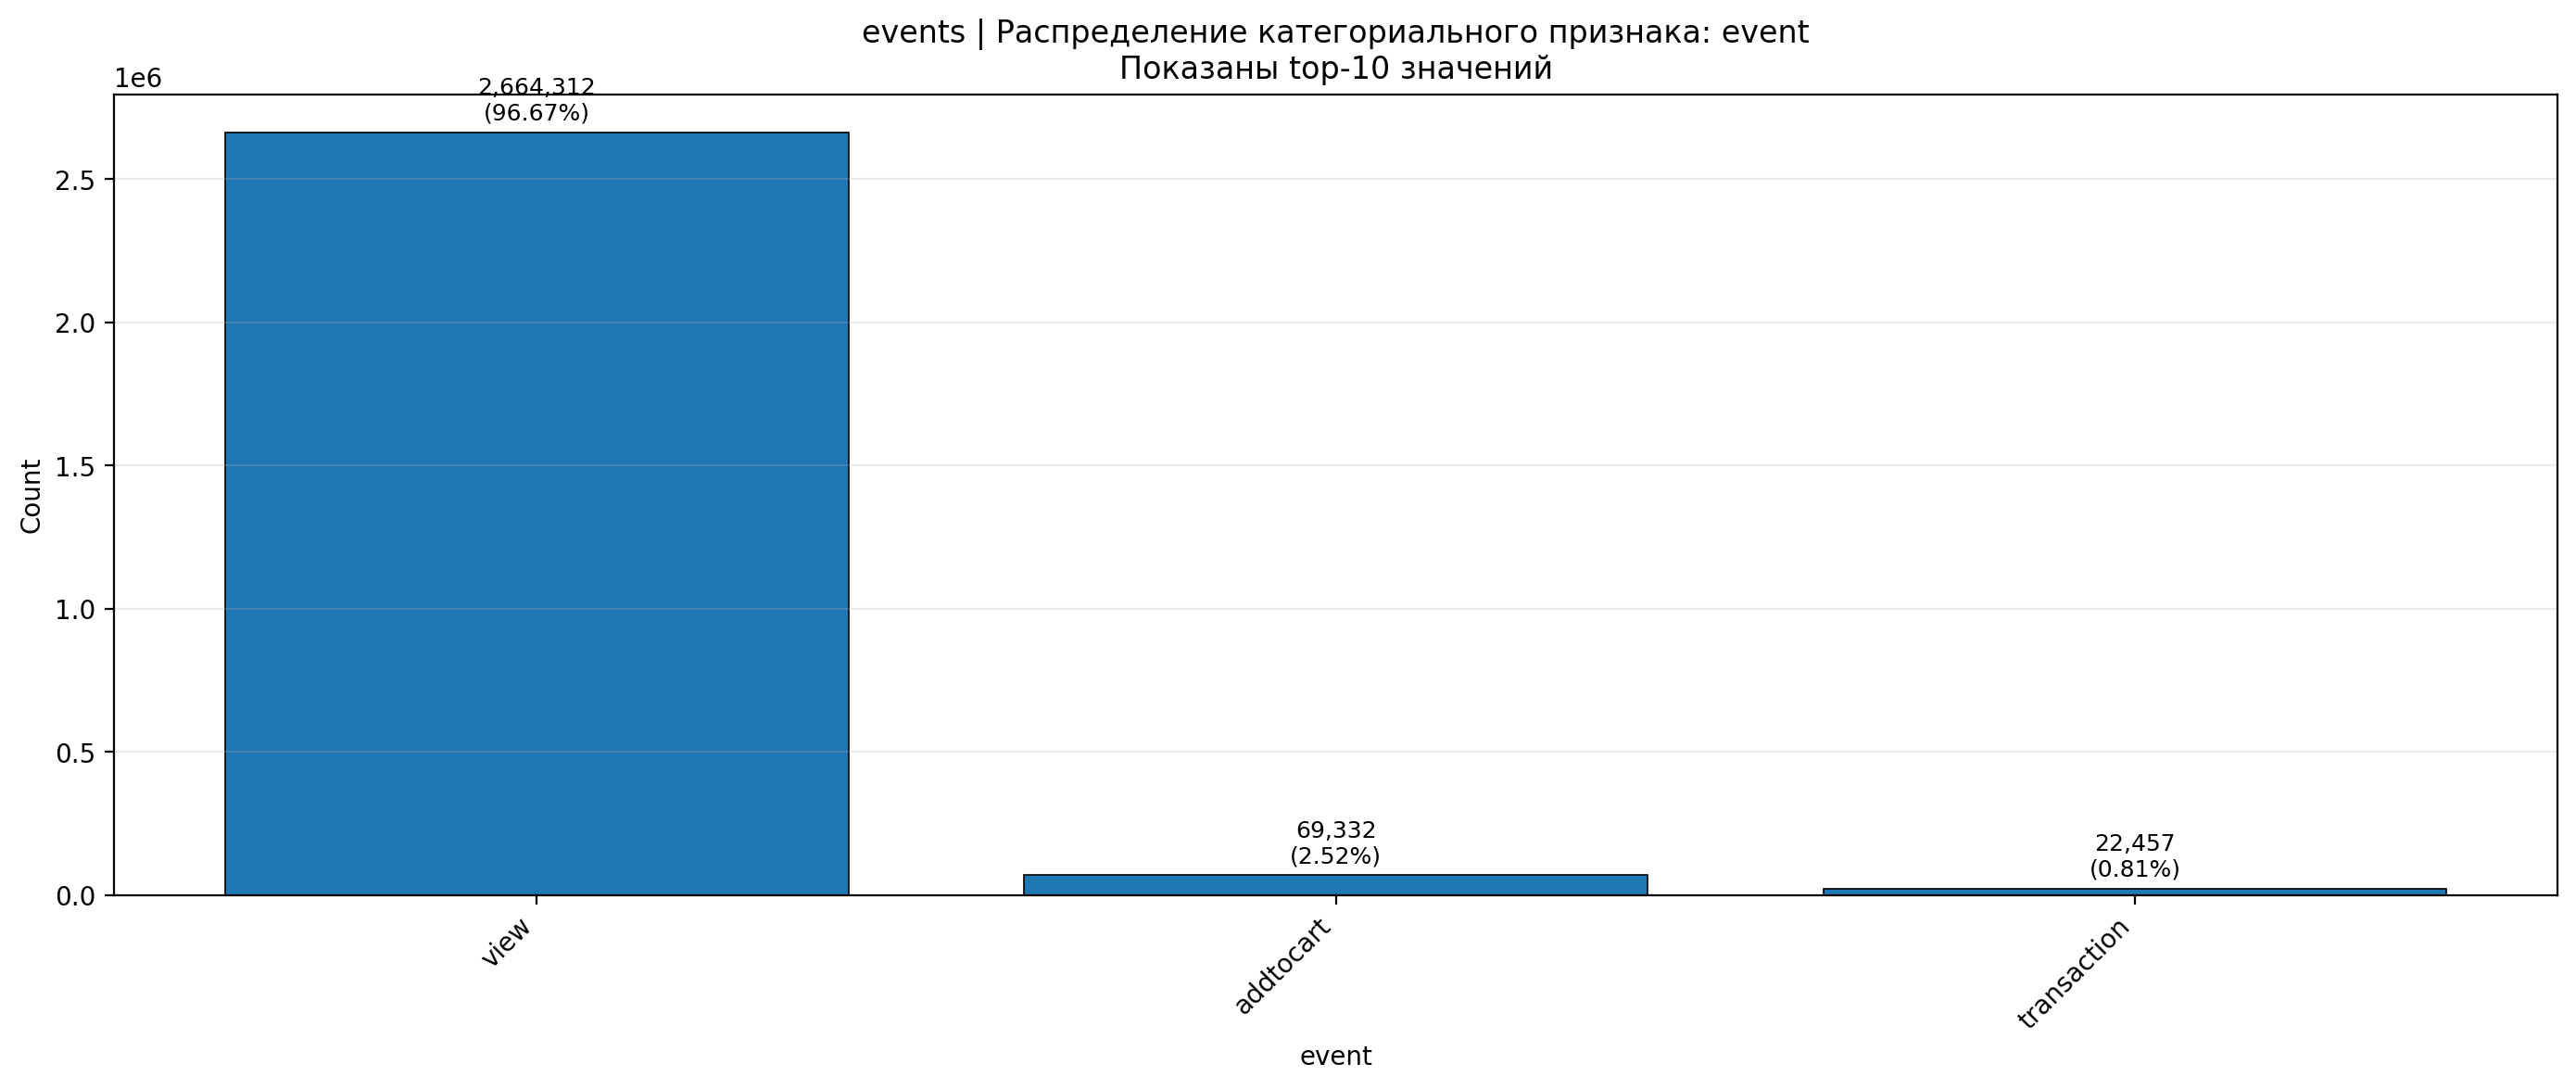

In [60]:
plot_categorical_distribution(events, "event", dataset_name="events", top_n=10)

### Выводы по распределению событий:

#### 1. Сильный дисбаланс классов

* **view ~96.7%** — почти все события
* **addtocart ~2.5%**
* **transaction ~0.8%**

Это классическая ситуация для e-commerce:
воронка сильно «сужается» от просмотров к покупкам.

---

#### 2. Поведение пользователей — «просмотр без действия»

* Подавляющее большинство пользователей **только смотрят товары**
* Очень небольшая доля:

  * добавляет в корзину
  * совершает покупку

Это означает:

* данные **сильно разреженные по позитивным сигналам**
* покупки — **редкое событие (sparse signal)**

---

#### 3. Качество таргета (важно для модели)

Если таргет = **addtocart или transaction**, то:

* будет **жесткий дисбаланс классов**
* модель может «скатиться» в предсказание нулей

Значит обязательно:

* использовать **взвешивание классов / sampling**
* или **ranking-подход вместо классификации**

---

#### 4. Почему add-to-cart — хороший таргет

* В 3 раза чаще, чем покупки (≈69k vs 22k)
* При этом уже отражает **сильный интерес**

Это идеальный компромисс:

* больше сигналов, чем у purchase
* качественнее, чем просто view

---

#### 5. Импликации для рекомендательной системы

На основе распределения:

##### Для candidate generation:

* можно использовать **все события**, но с весами:

  * view = низкий вес
  * addtocart = средний
  * transaction = высокий

##### Для обучения:

* таргет лучше делать:

  * `addtocart` (основной)
  * `transaction` как сильный сигнал

---

#### 6. Ожидаемый long-tail

Такое распределение почти гарантирует:

* **long-tail пользователей** (многие с 1–2 событиями)
* **long-tail товаров** (многие почти не взаимодействуют)

Это нужно будет подтвердить на:

* `events_per_user`
* `events_per_item`

---

### Итог

Данные полностью соответствуют типичному e-commerce сценарию:

* сильный дисбаланс
* редкие целевые события
* высокая разреженность

Основная сложность дальше — не в данных, а в:

* **правильной формулировке таргета**
* **балансировке сигналов**
* **двухэтапной архитектуре (candidate generation + ranking)**


### 7.2.2 Временная структура событий

In [61]:
# Сначала переводим время.
events["timestamp_dt"] = pd.to_datetime(events["timestamp"], unit="ms")
item_props["timestamp_dt"] = pd.to_datetime(item_props["timestamp"], unit="ms")

In [62]:
print("events min:", events["timestamp_dt"].min())
print("events max:", events["timestamp_dt"].max())

print("item_props min:", item_props["timestamp_dt"].min())
print("item_props max:", item_props["timestamp_dt"].max())

events min: 2015-05-03 03:00:04.384000
events max: 2015-09-18 02:59:47.788000
item_props min: 2015-05-10 03:00:00
item_props max: 2015-09-13 03:00:00


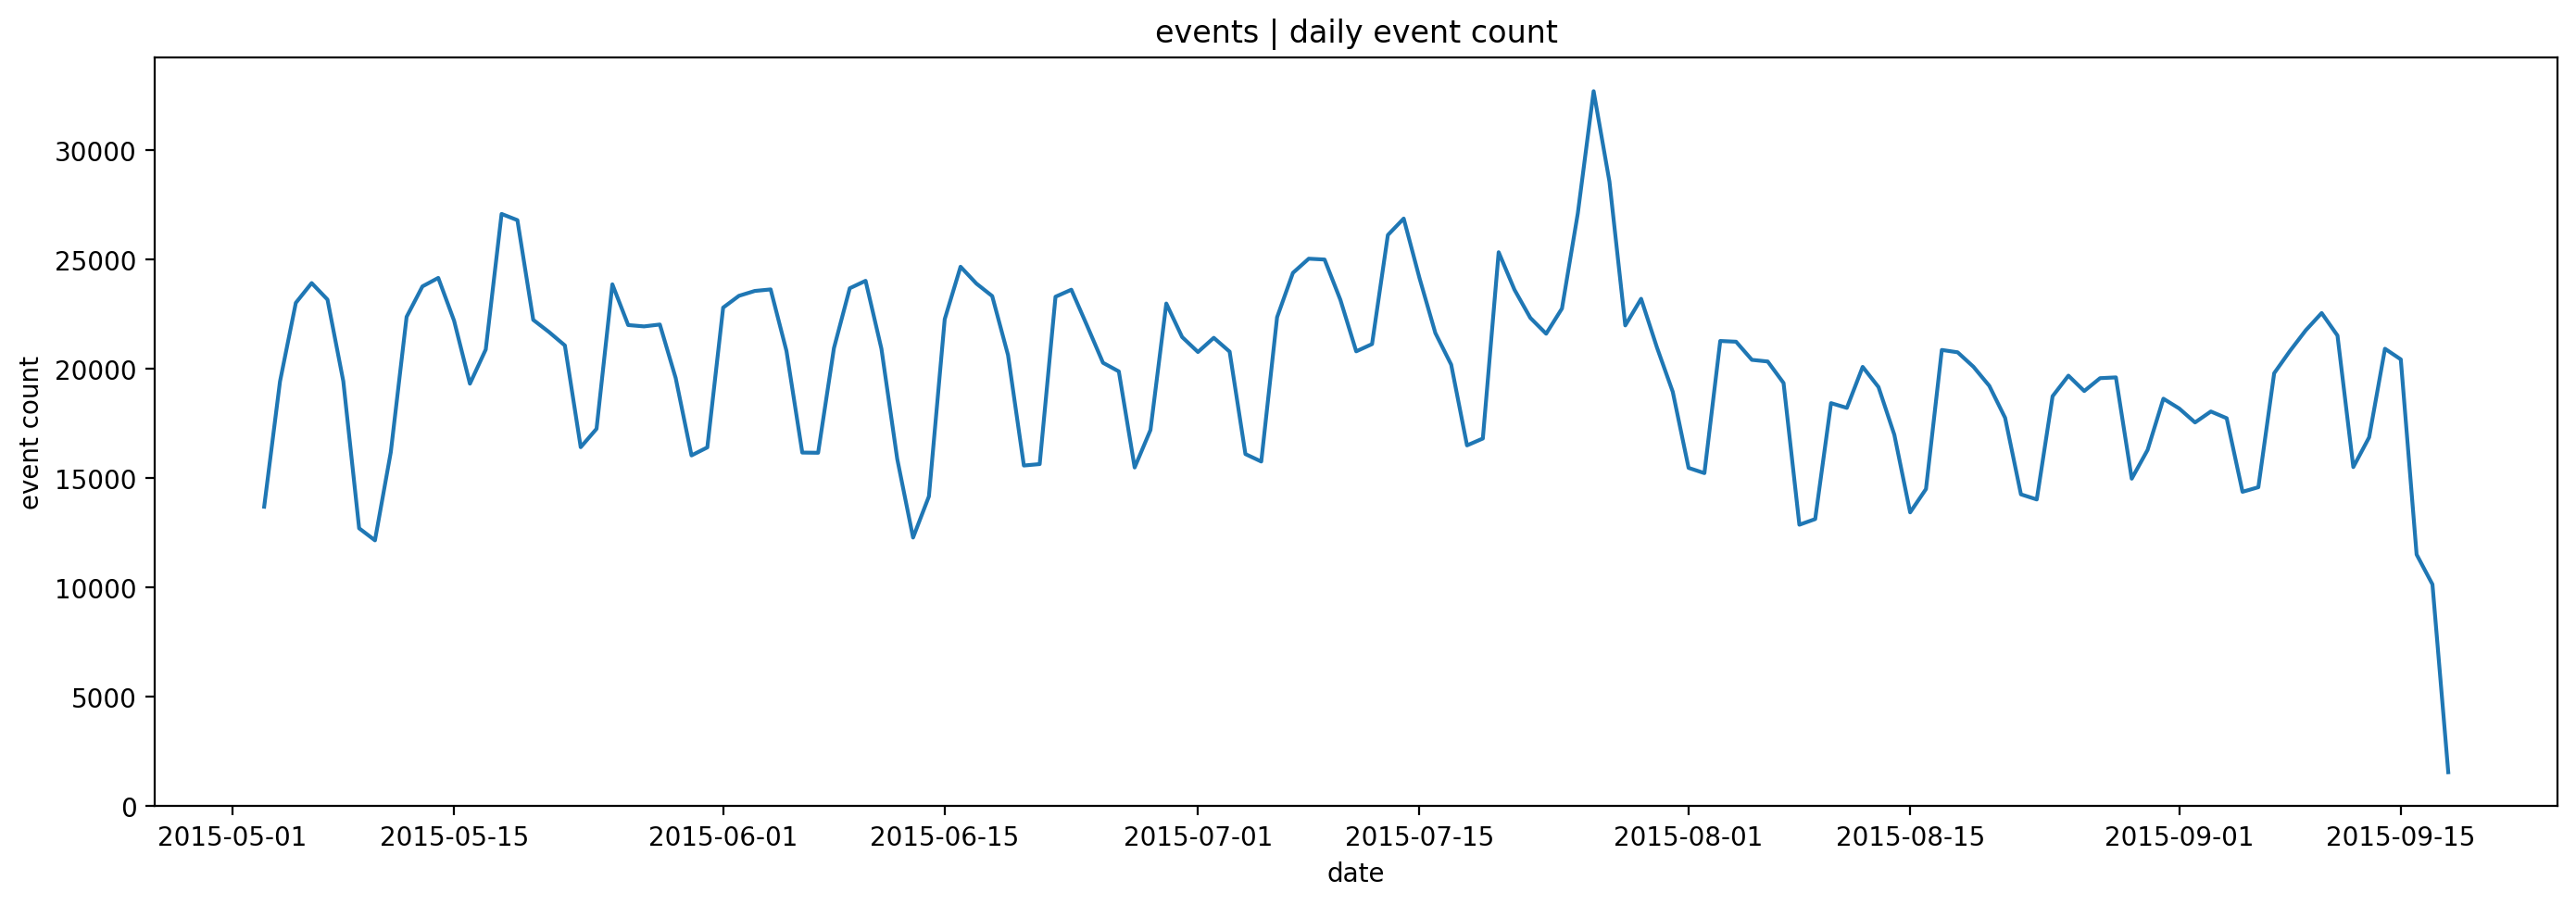

In [63]:
events_by_day = (
    events.set_index("timestamp_dt")
    .resample("D")
    .size()
    .reset_index(name="event_count")
)

plt.figure(figsize=(14, 5))
plt.plot(events_by_day["timestamp_dt"], events_by_day["event_count"])
plt.title("events | daily event count")
plt.xlabel("date")
plt.ylabel("event count")
plt.tight_layout()
plt.show()

### Подготовка фичей времени

In [ ]:
events["date"] = events["timestamp_dt"].dt.date
events["hour"] = events["timestamp_dt"].dt.hour
events["weekday"] = events["timestamp_dt"].dt.weekday  # 0=Пн, 6=Вс
events["weekday_name"] = events["timestamp_dt"].dt.day_name()

### Активность по дням недели

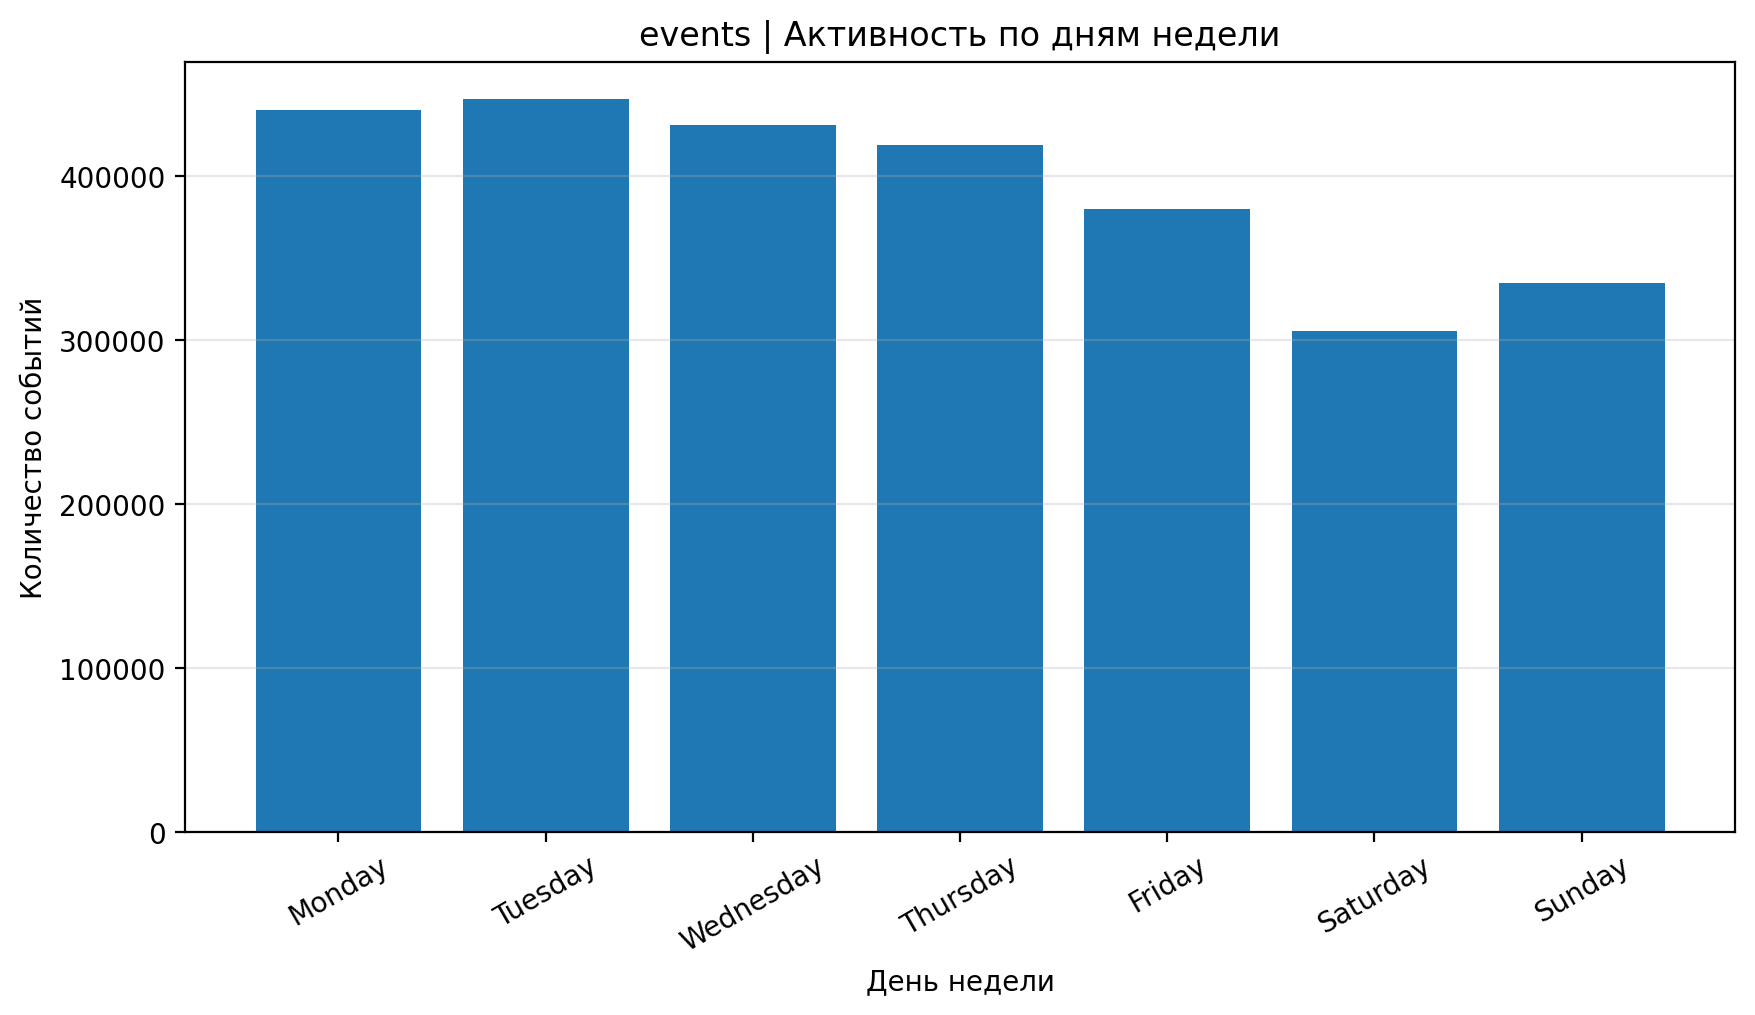

In [67]:
weekday_counts = (
    events.groupby("weekday_name")
    .size()
    .reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    )
)

plt.figure(figsize=(10, 5))
plt.bar(weekday_counts.index, weekday_counts.values)
plt.title("events | Активность по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество событий")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Активность по часам

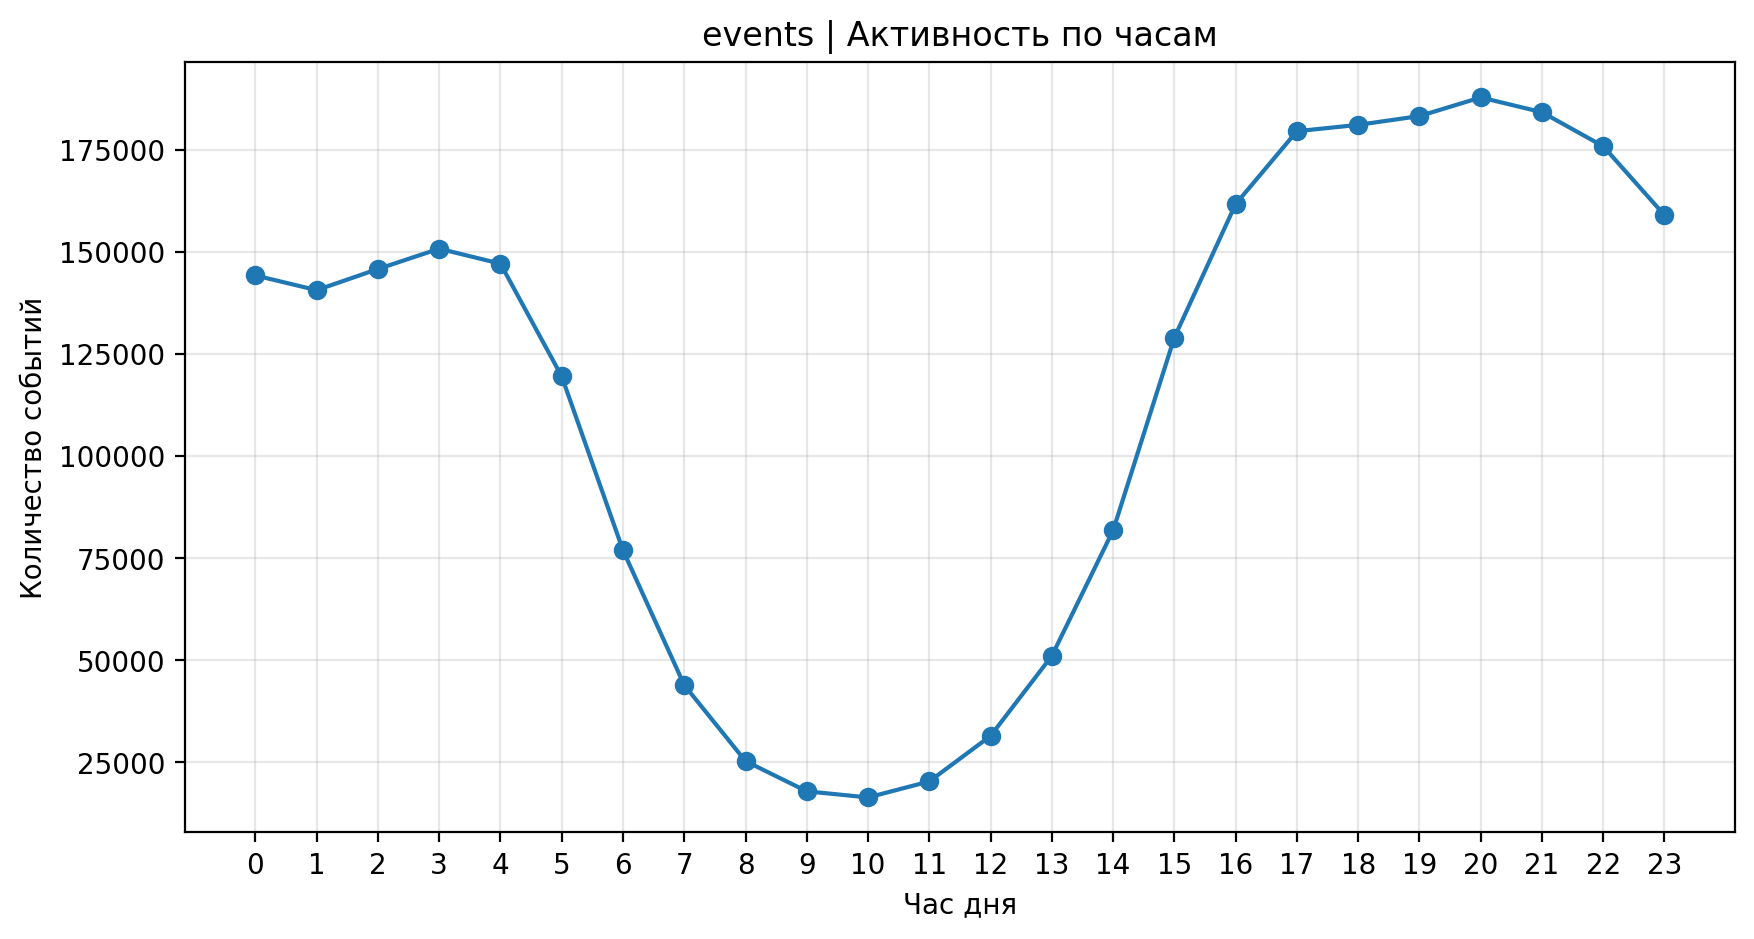

In [68]:
hour_counts = events.groupby("hour").size()

plt.figure(figsize=(10, 5))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.title("events | Активность по часам")
plt.xlabel("Час дня")
plt.ylabel("Количество событий")
plt.grid(alpha=0.3)
plt.xticks(range(0, 24))
plt.show()

### Heatmap (день недели × час)

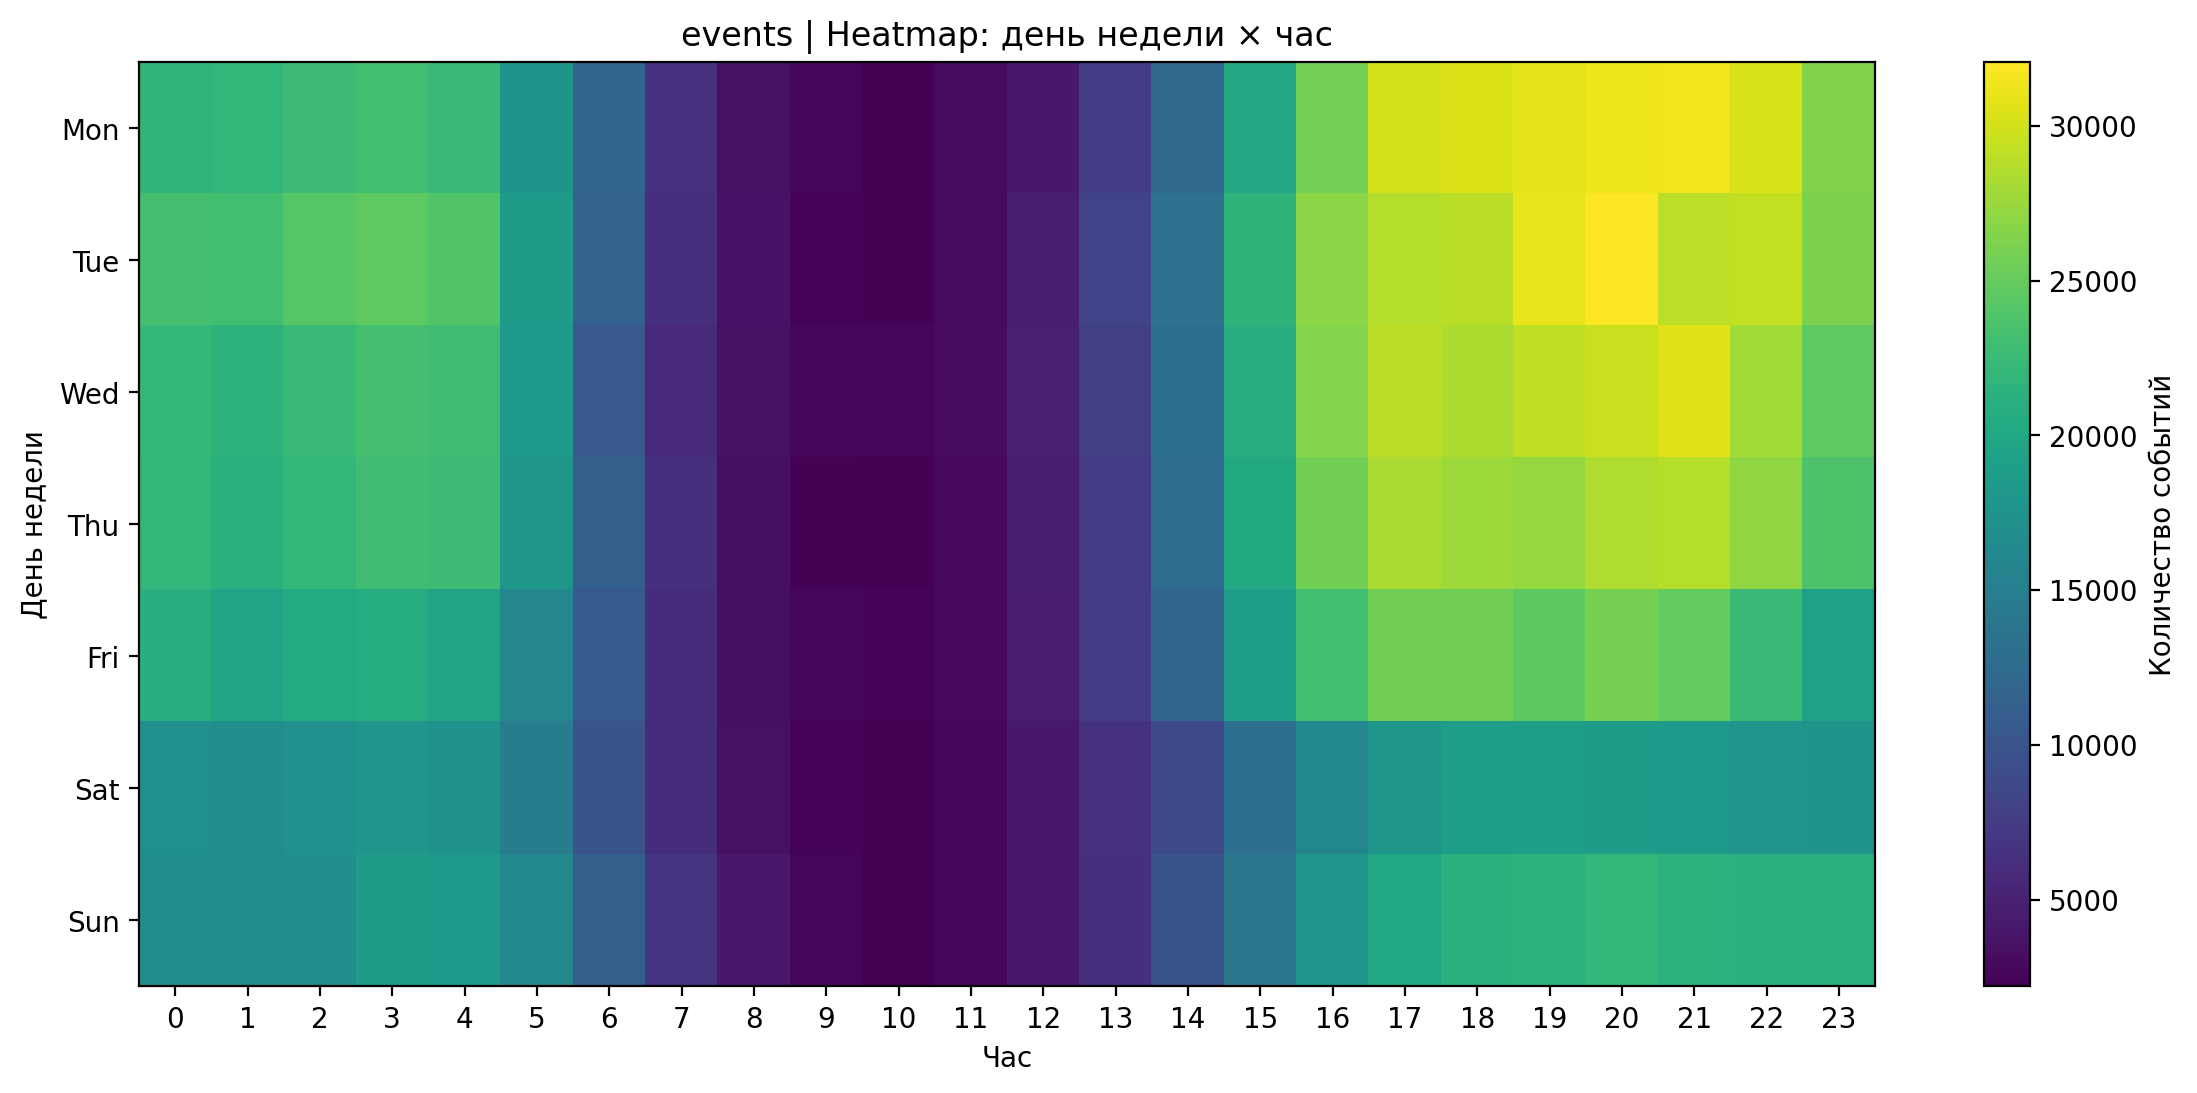

In [69]:
pivot = events.pivot_table(
    index="weekday", columns="hour", values="itemid", aggfunc="count"
)

plt.figure(figsize=(14, 6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Количество событий")

plt.title("events | Heatmap: день недели × час")
plt.xlabel("Час")
plt.ylabel("День недели")
plt.yticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

plt.xticks(range(24))
plt.show()

### Выводы по временной структуре событий

### 1. Период и качество данных

* Период: **май – сентябрь 2015 (~4.5 месяца)**
* `item_props` короче → есть **рассинхрон данных**
* Последние дни — **обрезаны (резкое падение)** → нужно удалить

Данные подходят для моделирования, но требуют **time-cleaning**

---

### 2. Глобальная динамика

* Стабильный уровень: **15k – 25k событий/день**
* Без долгосрочного тренда
* Есть локальные пики (акции / кампании)

Система **стабильная**, без деградации

---

### 3. Недельная сезонность

* Пик: **понедельник–среда**
* Постепенное снижение к пятнице
* Минимум: **суббота**
* Воскресенье — частичное восстановление

Пользователи активнее в будни
Выходные — менее конверсионные

---

### 4. Почасовая динамика (очень важный инсайт)

* Минимум: **8–11 утра**
* Резкий рост после обеда
* Пик: **18–22 (вечер)**
* Ночь (0–4): умеренная активность

Это типичный user behavior:

* утром — низкая вовлеченность
* вечером — максимум взаимодействий

---

### 5. Heatmap (день × час) — главный паттерн

* Во **все дни**:

  * минимум утром
  * пик вечером
* В будни:

  * пики сильнее (особенно Tue–Wed)
* В выходные:

  * более ровное распределение
  * ниже общая активность

Поведение пользователей:

* **вечер — основное время покупок**
* будни ≠ выходные (разные паттерны)

---

### 6. Ключевые инсайты для модели

#### Обязательно добавить фичи:

* `hour`
* `weekday`
* `is_weekend`
* возможно: `hour * weekday` (interaction)

---

#### Важный бизнес-инсайт:

* вечером выше вероятность:

  * add-to-cart
  * transaction

можно делать:

  * time-aware ranking
  * или boosting рекомендаций вечером

---

#### Разделение данных

* Только **time-based split**
* Удалить последние дни (обрезанные)

---

### 7. Финальный вывод

Данные имеют:

* чёткую **иерархию времени (день → час)**
* выраженную **сезонность**
* **поведенческие паттерны пользователей**

Это означает:

* модель без временных фич будет **существенно хуже**
* temporal features — **must-have, а не optional**


### Временные ряды по дням для разных типов событий

In [73]:
# Подготовка данных
event_hour = events.groupby(["event", "hour"]).size().reset_index(name="count")

event_weekday = events.groupby(["event", "weekday"]).size().reset_index(name="count")

### Активность по часам (по типам событий)

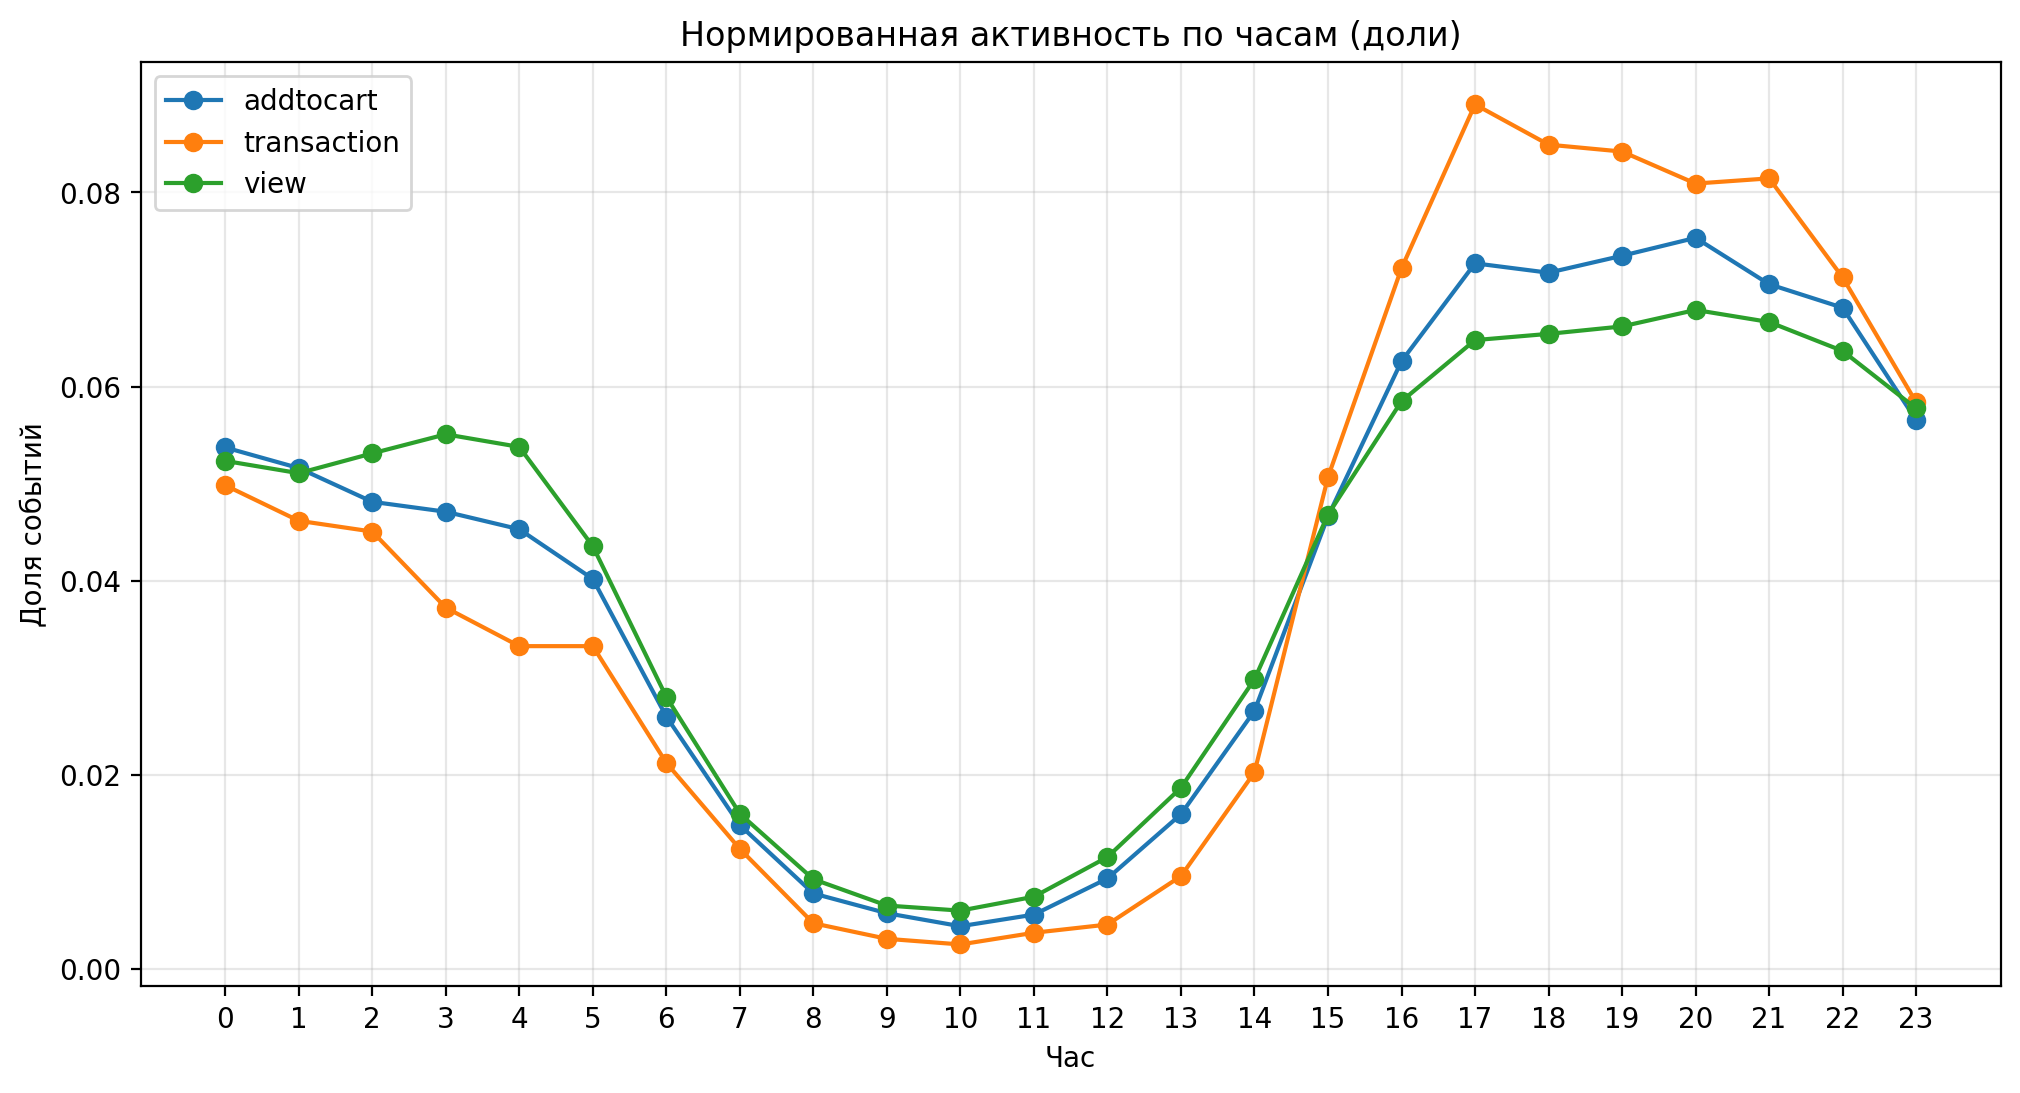

In [77]:
event_hour_norm = event_hour.copy()

event_hour_norm["share"] = event_hour_norm.groupby("event")["count"].transform(
    lambda x: x / x.sum()
)

plt.figure(figsize=(12, 6))

for event_type in event_hour_norm["event"].unique():
    subset = event_hour_norm[event_hour_norm["event"] == event_type]
    plt.plot(subset["hour"], subset["share"], marker="o", label=event_type)

plt.title("Нормированная активность по часам (доли)")
plt.xlabel("Час")
plt.ylabel("Доля событий")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(24))
plt.show()

### Активность по дням недели (по типам событий)

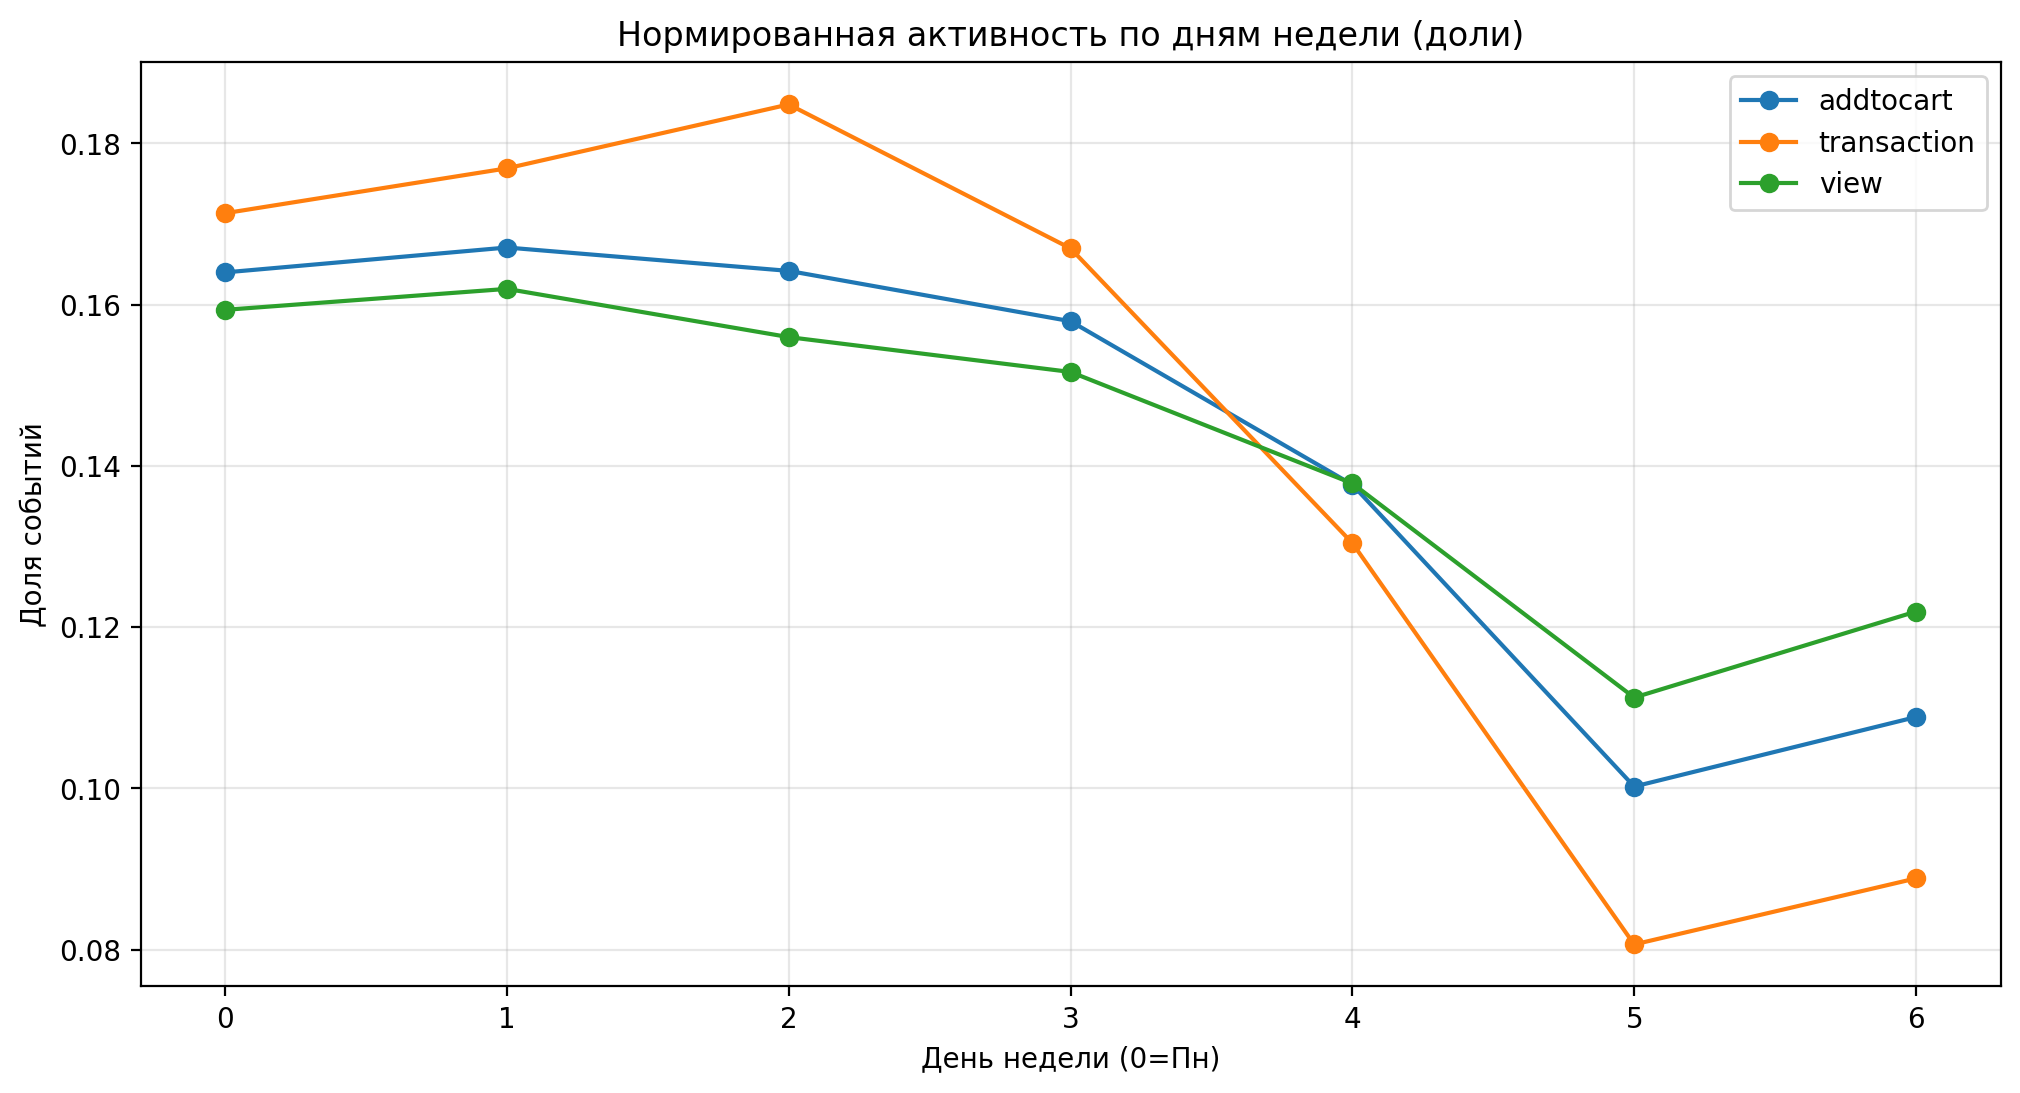

In [78]:
event_weekday_norm = event_weekday.copy()

event_weekday_norm["share"] = event_weekday_norm.groupby("event")["count"].transform(
    lambda x: x / x.sum()
)

plt.figure(figsize=(12, 6))

for event_type in event_weekday_norm["event"].unique():
    subset = event_weekday_norm[event_weekday_norm["event"] == event_type]
    plt.plot(subset["weekday"], subset["share"], marker="o", label=event_type)

plt.title("Нормированная активность по дням недели (доли)")
plt.xlabel("День недели (0=Пн)")
plt.ylabel("Доля событий")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(7))
plt.show()

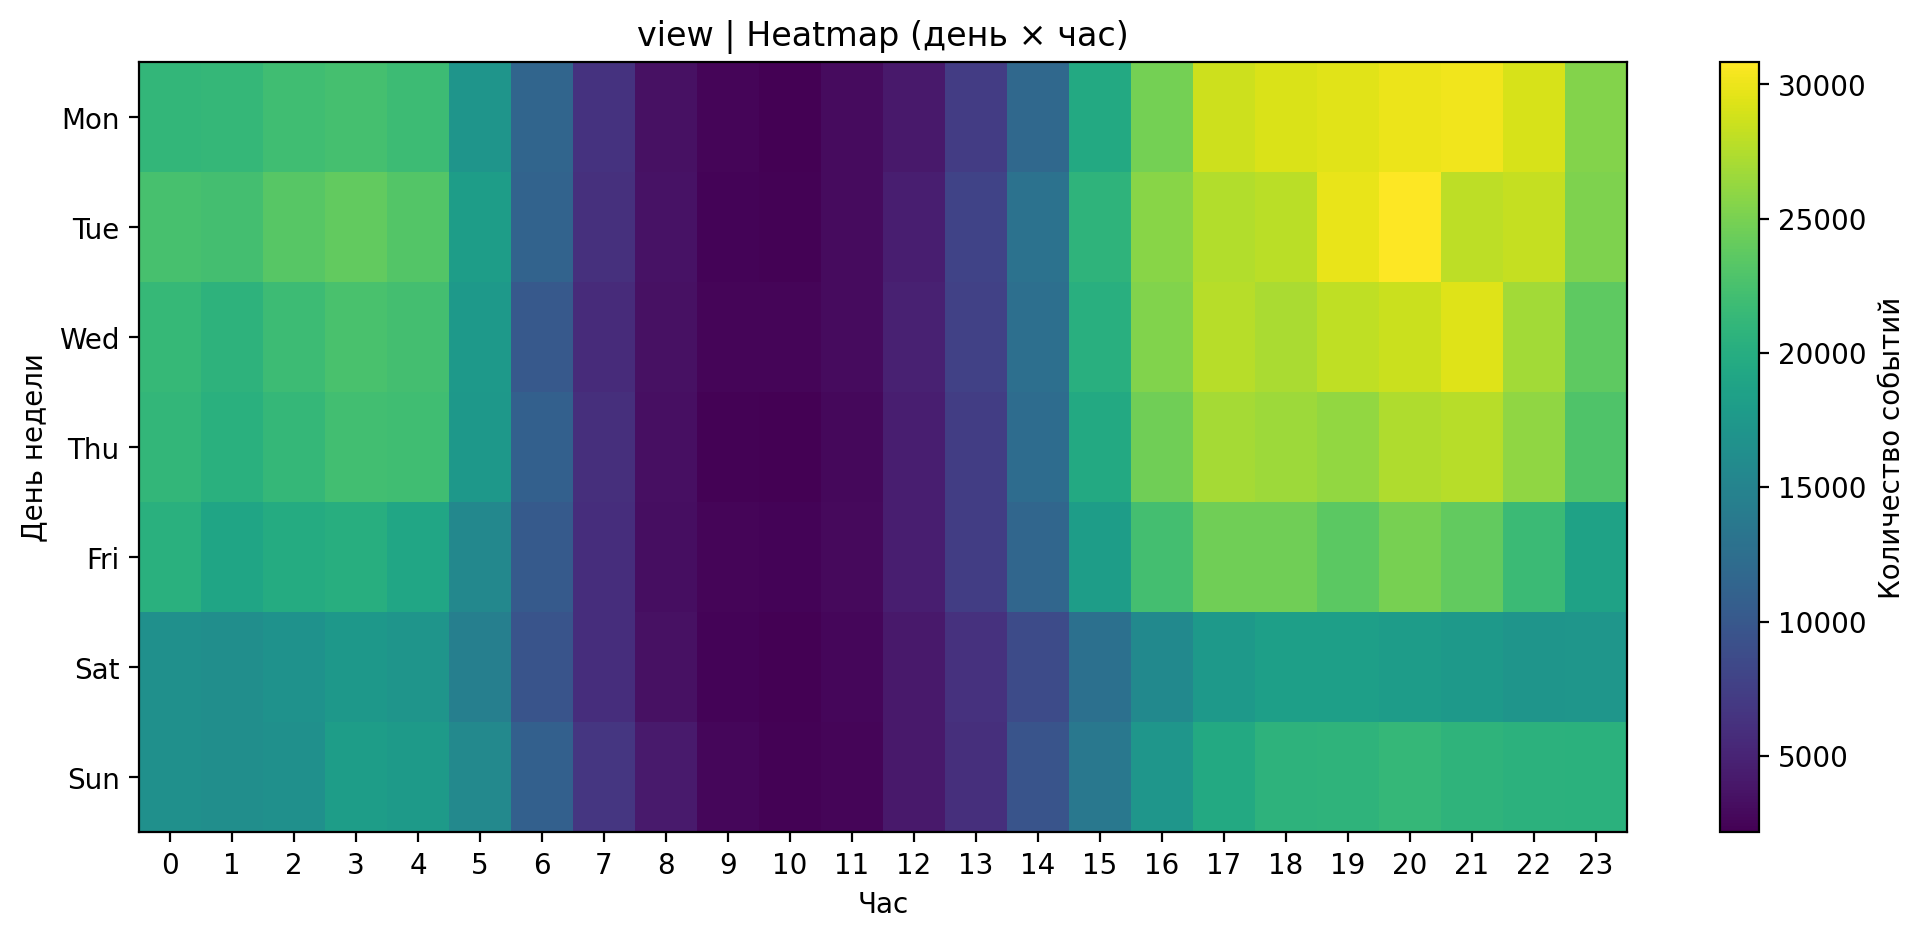

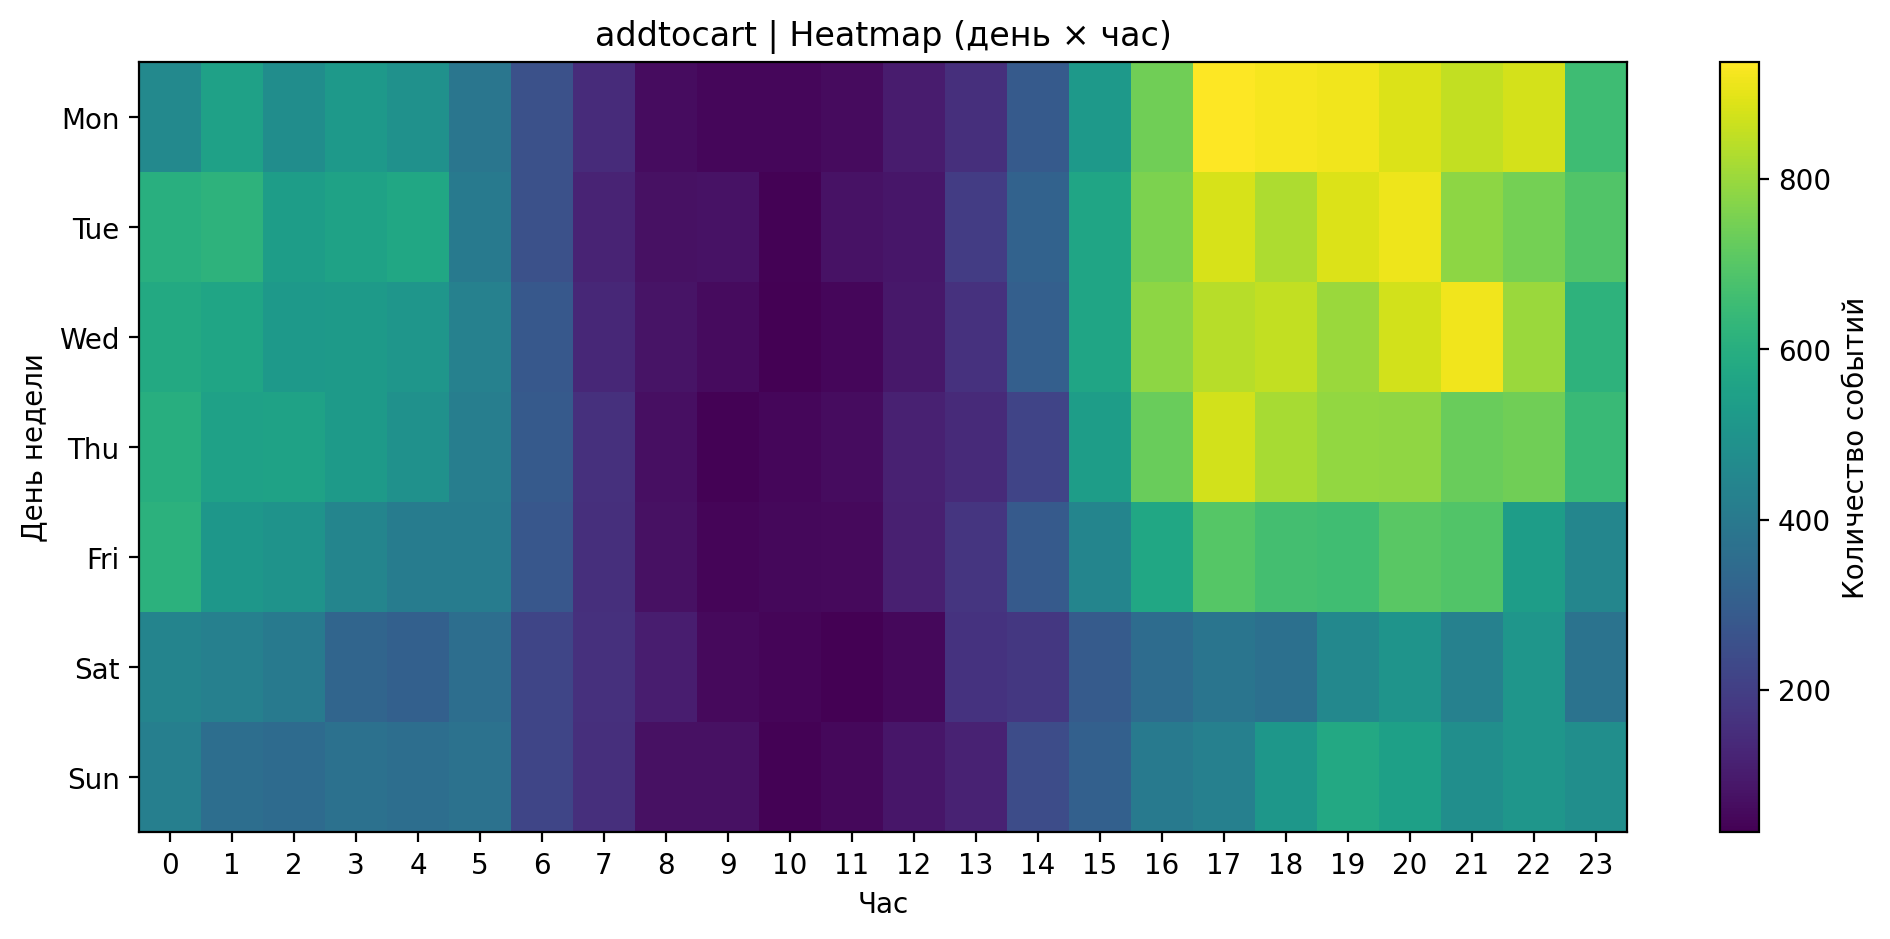

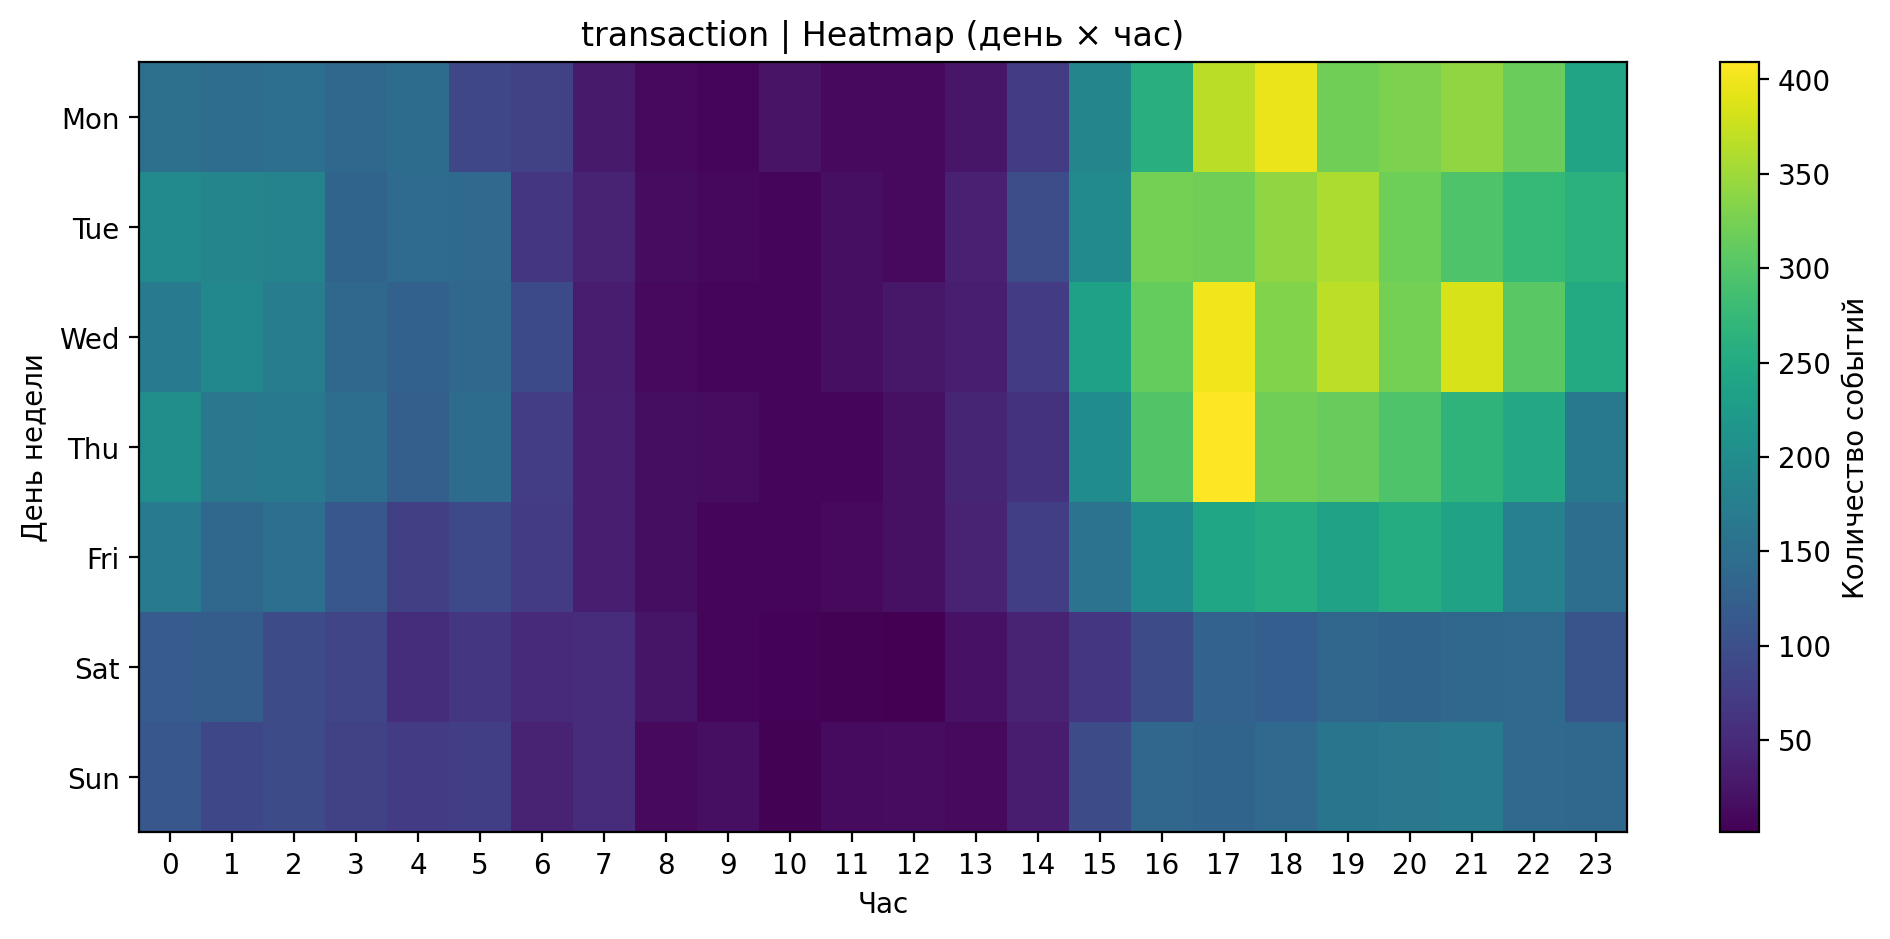

In [79]:
for event_type in events["event"].unique():
    pivot = events[events["event"] == event_type].pivot_table(
        index="weekday", columns="hour", values="itemid", aggfunc="count"
    )

    plt.figure(figsize=(12, 5))
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label="Количество событий")

    plt.title(f"{event_type} | Heatmap (день × час)")
    plt.xlabel("Час")
    plt.ylabel("День недели")

    plt.xticks(range(24))
    plt.yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

    plt.show()

### Общие выводы (час × день недели × тип события)

#### По часам

* Пик активности: **17–21**
* Минимум: **8–11 утра**
* Поведение одинаковое для всех типов событий → **единый пользовательский ритм**

---

#### По дням недели

* **Будни активнее выходных**
* Пик: **вторник–четверг**
* Спад: **суббота**

---

#### По типам событий

* `addtocart` и `transaction`:

  * повторяют форму `view`
  * но **чуть смещены к вечеру**
* вечером выше вероятность:

  * добавить в корзину
  * купить

значит:
**конверсия растёт вечером**

---

#### Heatmap инсайт

* Лучшее окно:
  **будни + вечер (17–21)**
* Худшее:
  **утро (8–11), особенно выходные**

---

### Бизнес-интерпретация

* Люди:

  * днём → смотрят
  * вечером → **принимают решения**
* Выходные:

  * больше “серфинг”, меньше покупок

---

### Что это даёт для рексистемы

Обязательно использовать как фичи:

* `hour`
* `weekday`
* `is_weekend`
* `evening_flag`

и даже лучше:

* `hour × weekday`
* `hour × event_type` (для conversion)

---

### Итог

> Поведение пользователей **сильно зависит от времени**,
> особенно **вечер = зона покупок**


### CR - conversion rate heatmap (час × день недели)

In [81]:
# 1. Подготовка данных
# агрегируем события
pivot = events.groupby(["weekday", "hour", "event"]).size().reset_index(name="count")

# разворачиваем
pivot = pivot.pivot_table(
    index=["weekday", "hour"], columns="event", values="count", fill_value=0
).reset_index()

In [82]:
# 2. Считаем конверсии
# защита от деления на 0
pivot["view"] = pivot["view"].replace(0, np.nan)

pivot["cr_view_to_cart"] = pivot["addtocart"] / pivot["view"]
pivot["cr_view_to_buy"] = pivot["transaction"] / pivot["view"]
pivot["cr_cart_to_buy"] = pivot["transaction"] / pivot["addtocart"].replace(0, np.nan)

In [83]:
# 3. Функция для heatmap
def plot_cr_heatmap(df, value_col, title):
    heatmap_data = df.pivot(index="weekday", columns="hour", values=value_col)

    plt.figure(figsize=(14, 5))
    sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar_kws={"label": value_col})

    plt.title(title)
    plt.xlabel("Час")
    plt.ylabel("День недели (0=Пн)")
    plt.show()

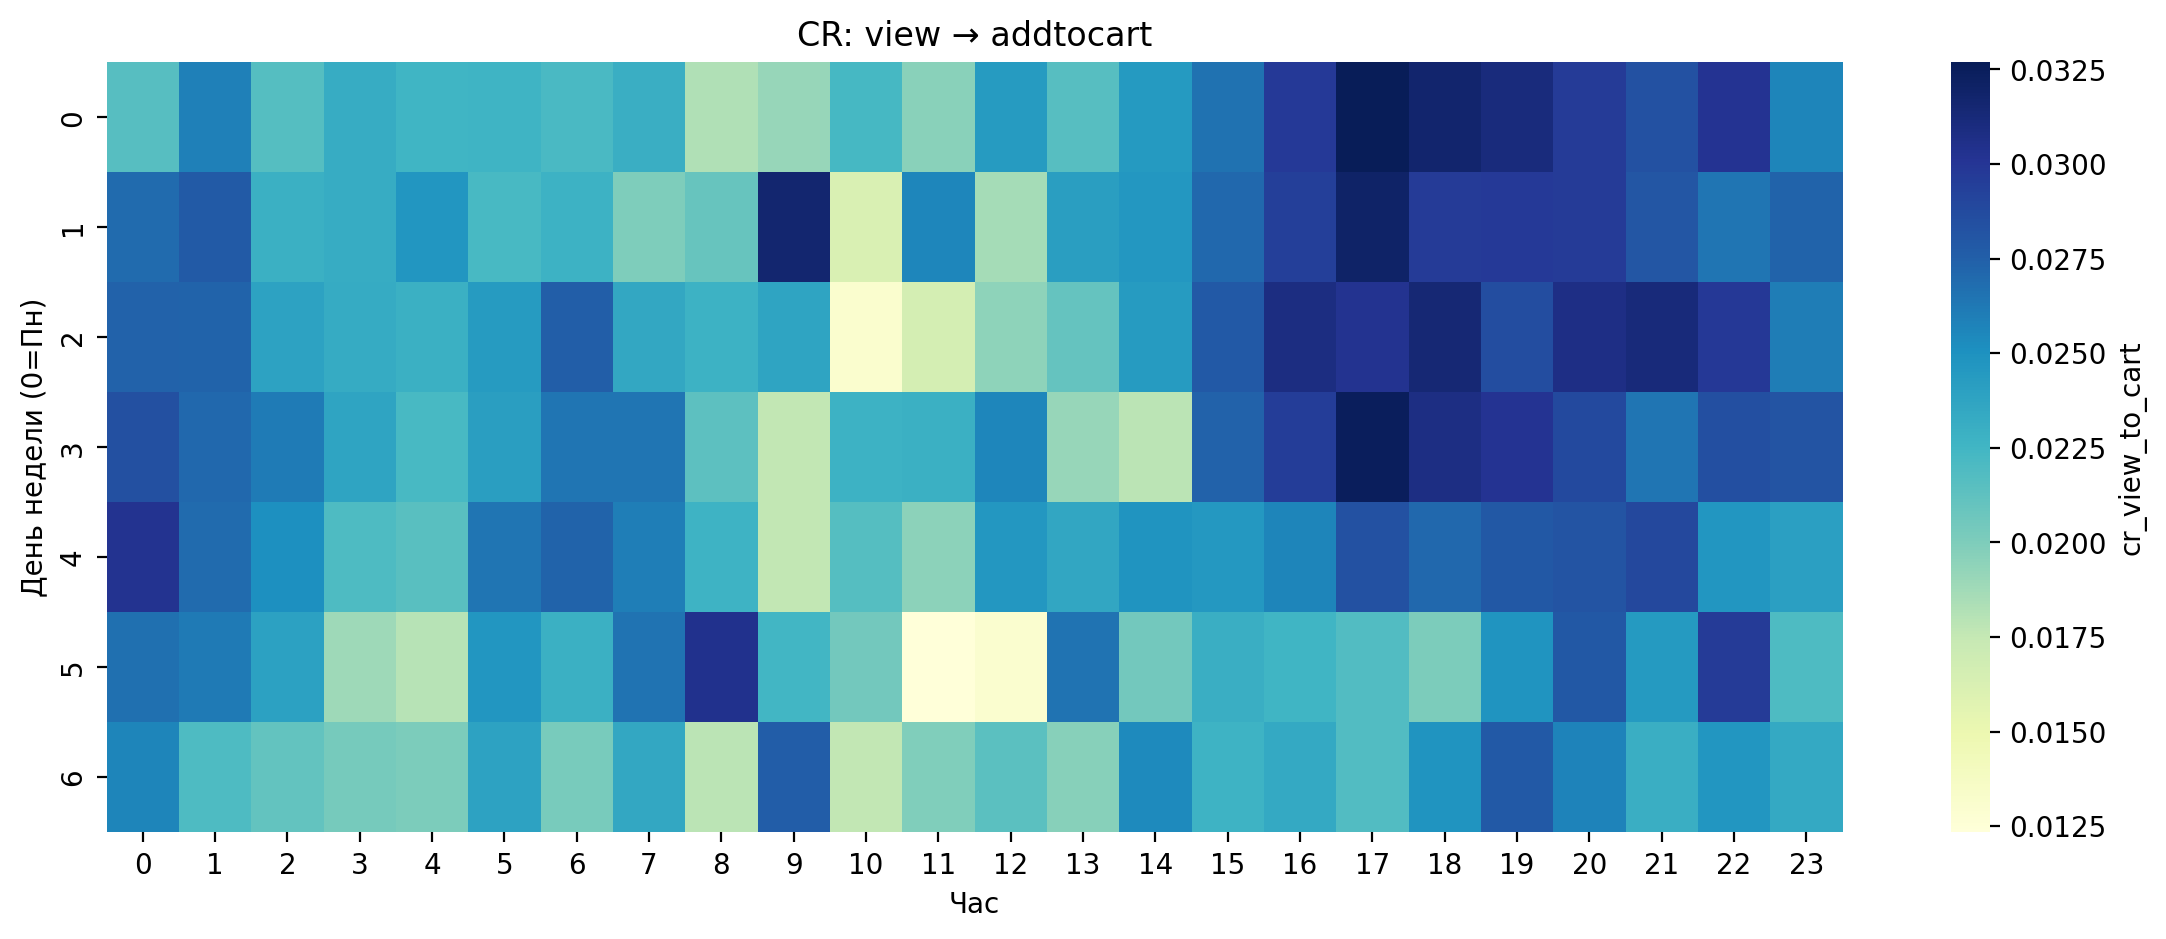

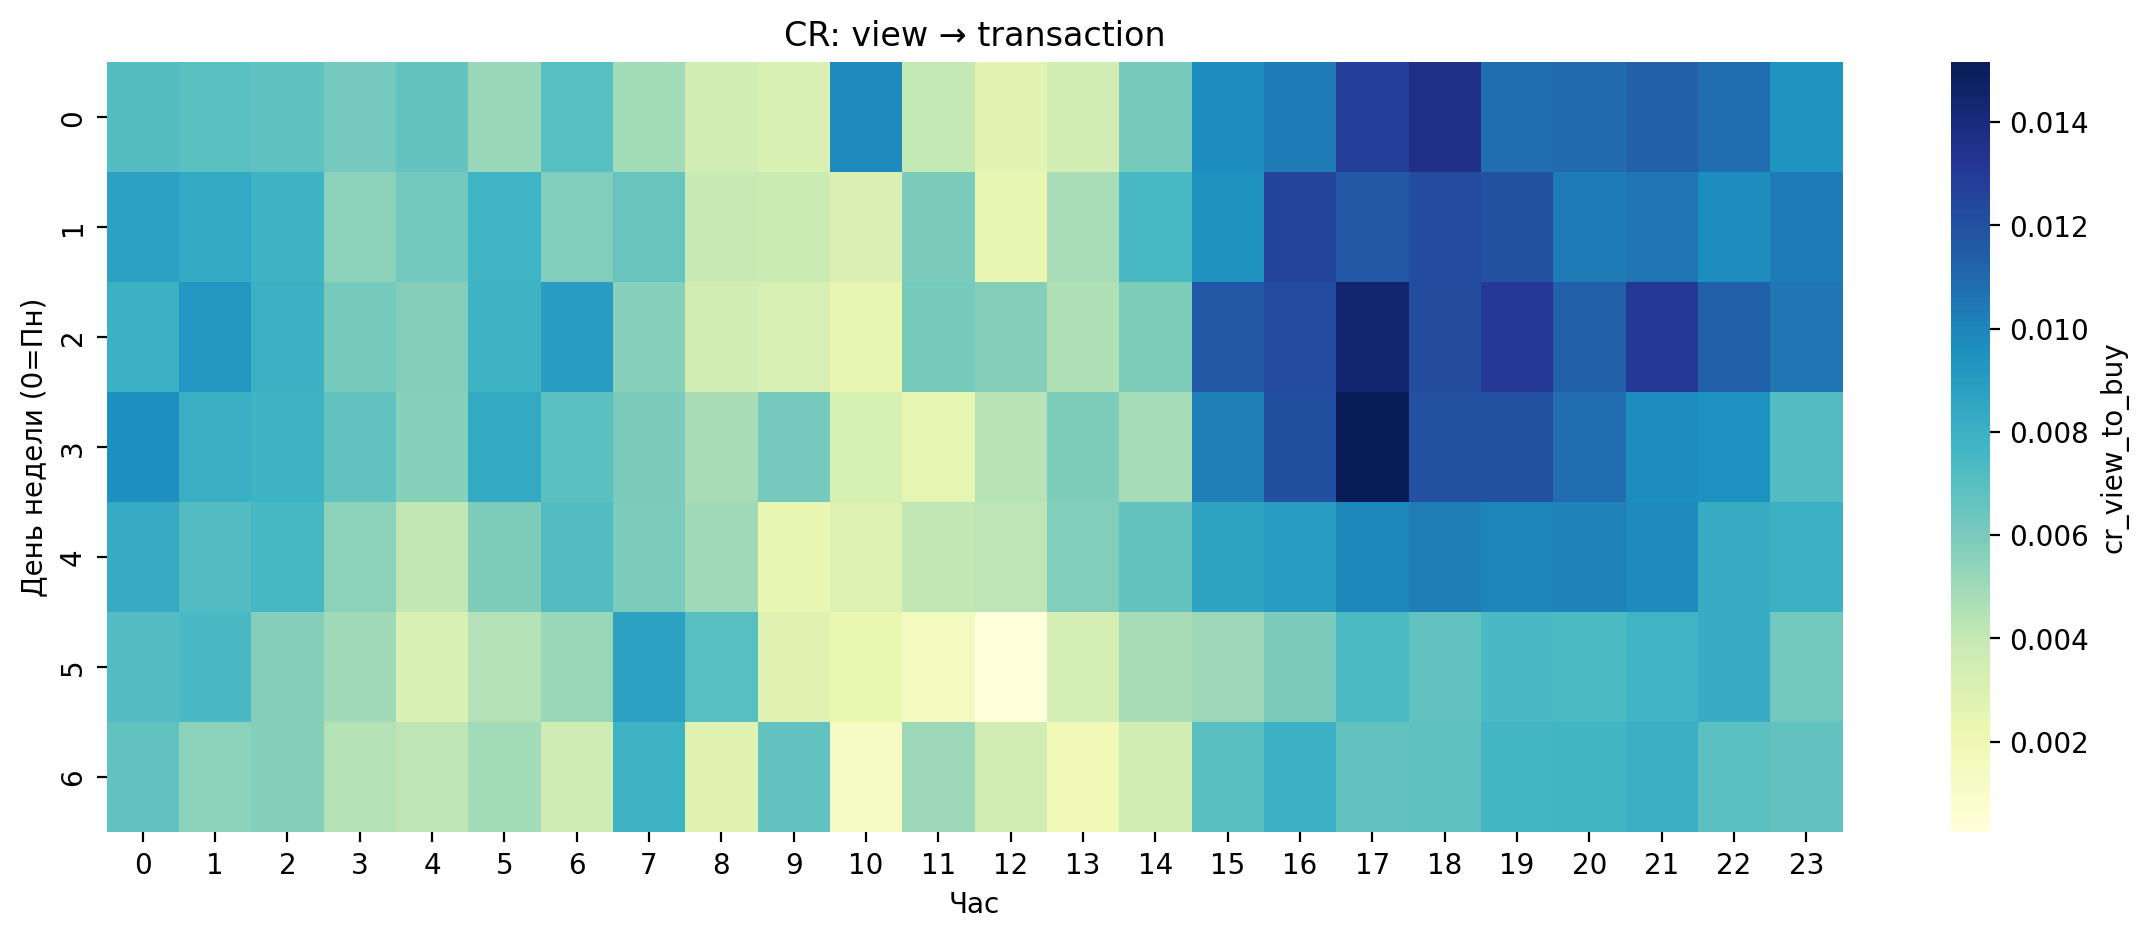

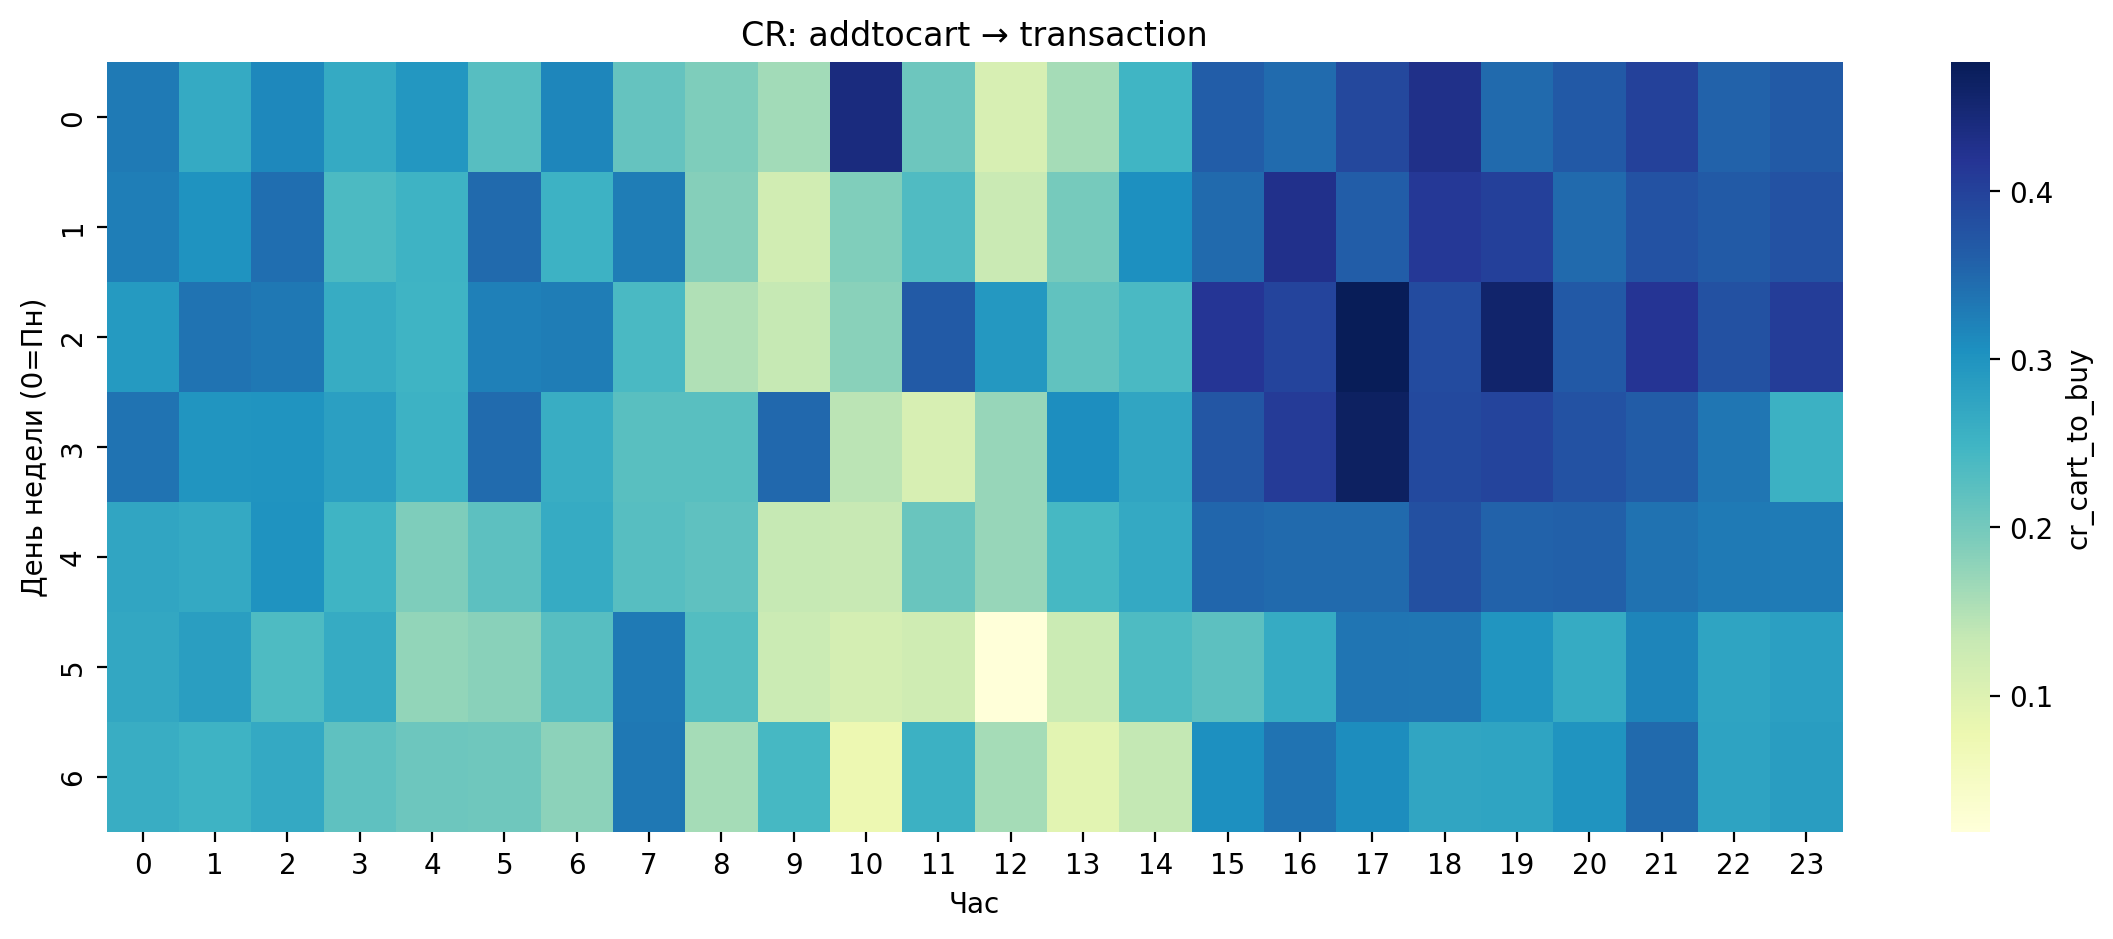

In [84]:
# 4. Строим графики
plot_cr_heatmap(pivot, "cr_view_to_cart", "CR: view → addtocart")
plot_cr_heatmap(pivot, "cr_view_to_buy", "CR: view → transaction")
plot_cr_heatmap(pivot, "cr_cart_to_buy", "CR: addtocart → transaction")

### Главные выводы по конверсиям

**1. Вечер (17–21) — пик конверсии**
Максимальные значения для всех переходов (view → cart → buy).
* Основное окно для рекомендаций и маркетинговых воздействий.

**2. Утро (8–12) — минимум конверсии**
Пользователи преимущественно просматривают, но редко совершают целевые действия.
* Подходит для сбора сигналов, а не для конверсионных сценариев.

**3. Ночь (0–5)**
Относительно высокая конверсия при низком объеме событий.
* Сегмент с высоким intent, перспективен для персонализированных рекомендаций.

**4. Выходные vs будни**
На выходных снижается конверсия при сохранении просмотров.
* Будни — основной период покупок, выходные — exploratory поведение.

**5. Сильный сигнал — addtocart**
CR addtocart → transaction достигает ~40–45%.
* Добавление в корзину — ключевой предиктор покупки (обязательный признак в модели).

---

### Поведенческий паттерн

Наблюдается четкая воронка по времени суток:

* утро — exploration
* день — consideration
* вечер — conversion

---

### Импликации для модели

* Добавление временных признаков:
  `hour`, `weekday`, `is_weekend`, `hour_bucket`
* Использование time-aware скоринга
* Учет контекста времени при ранжировании
* Feature engineering:
  `user_hour_pref`, `item_hour_cr`, `user_weekday_pref`

---

### Итог

Конверсия существенно зависит от времени → временной контекст является критически важным фактором для рекомендательной системы.


### 7.2.3 Активность пользователей

In [86]:
user_activity = events.groupby("visitorid").size().reset_index(name="n_events")

user_activity["n_events"].describe()

count   1,407,580
mean            2
std            13
min             1
25%             1
50%             1
75%             2
max         7,757
Name: n_events, dtype: float64

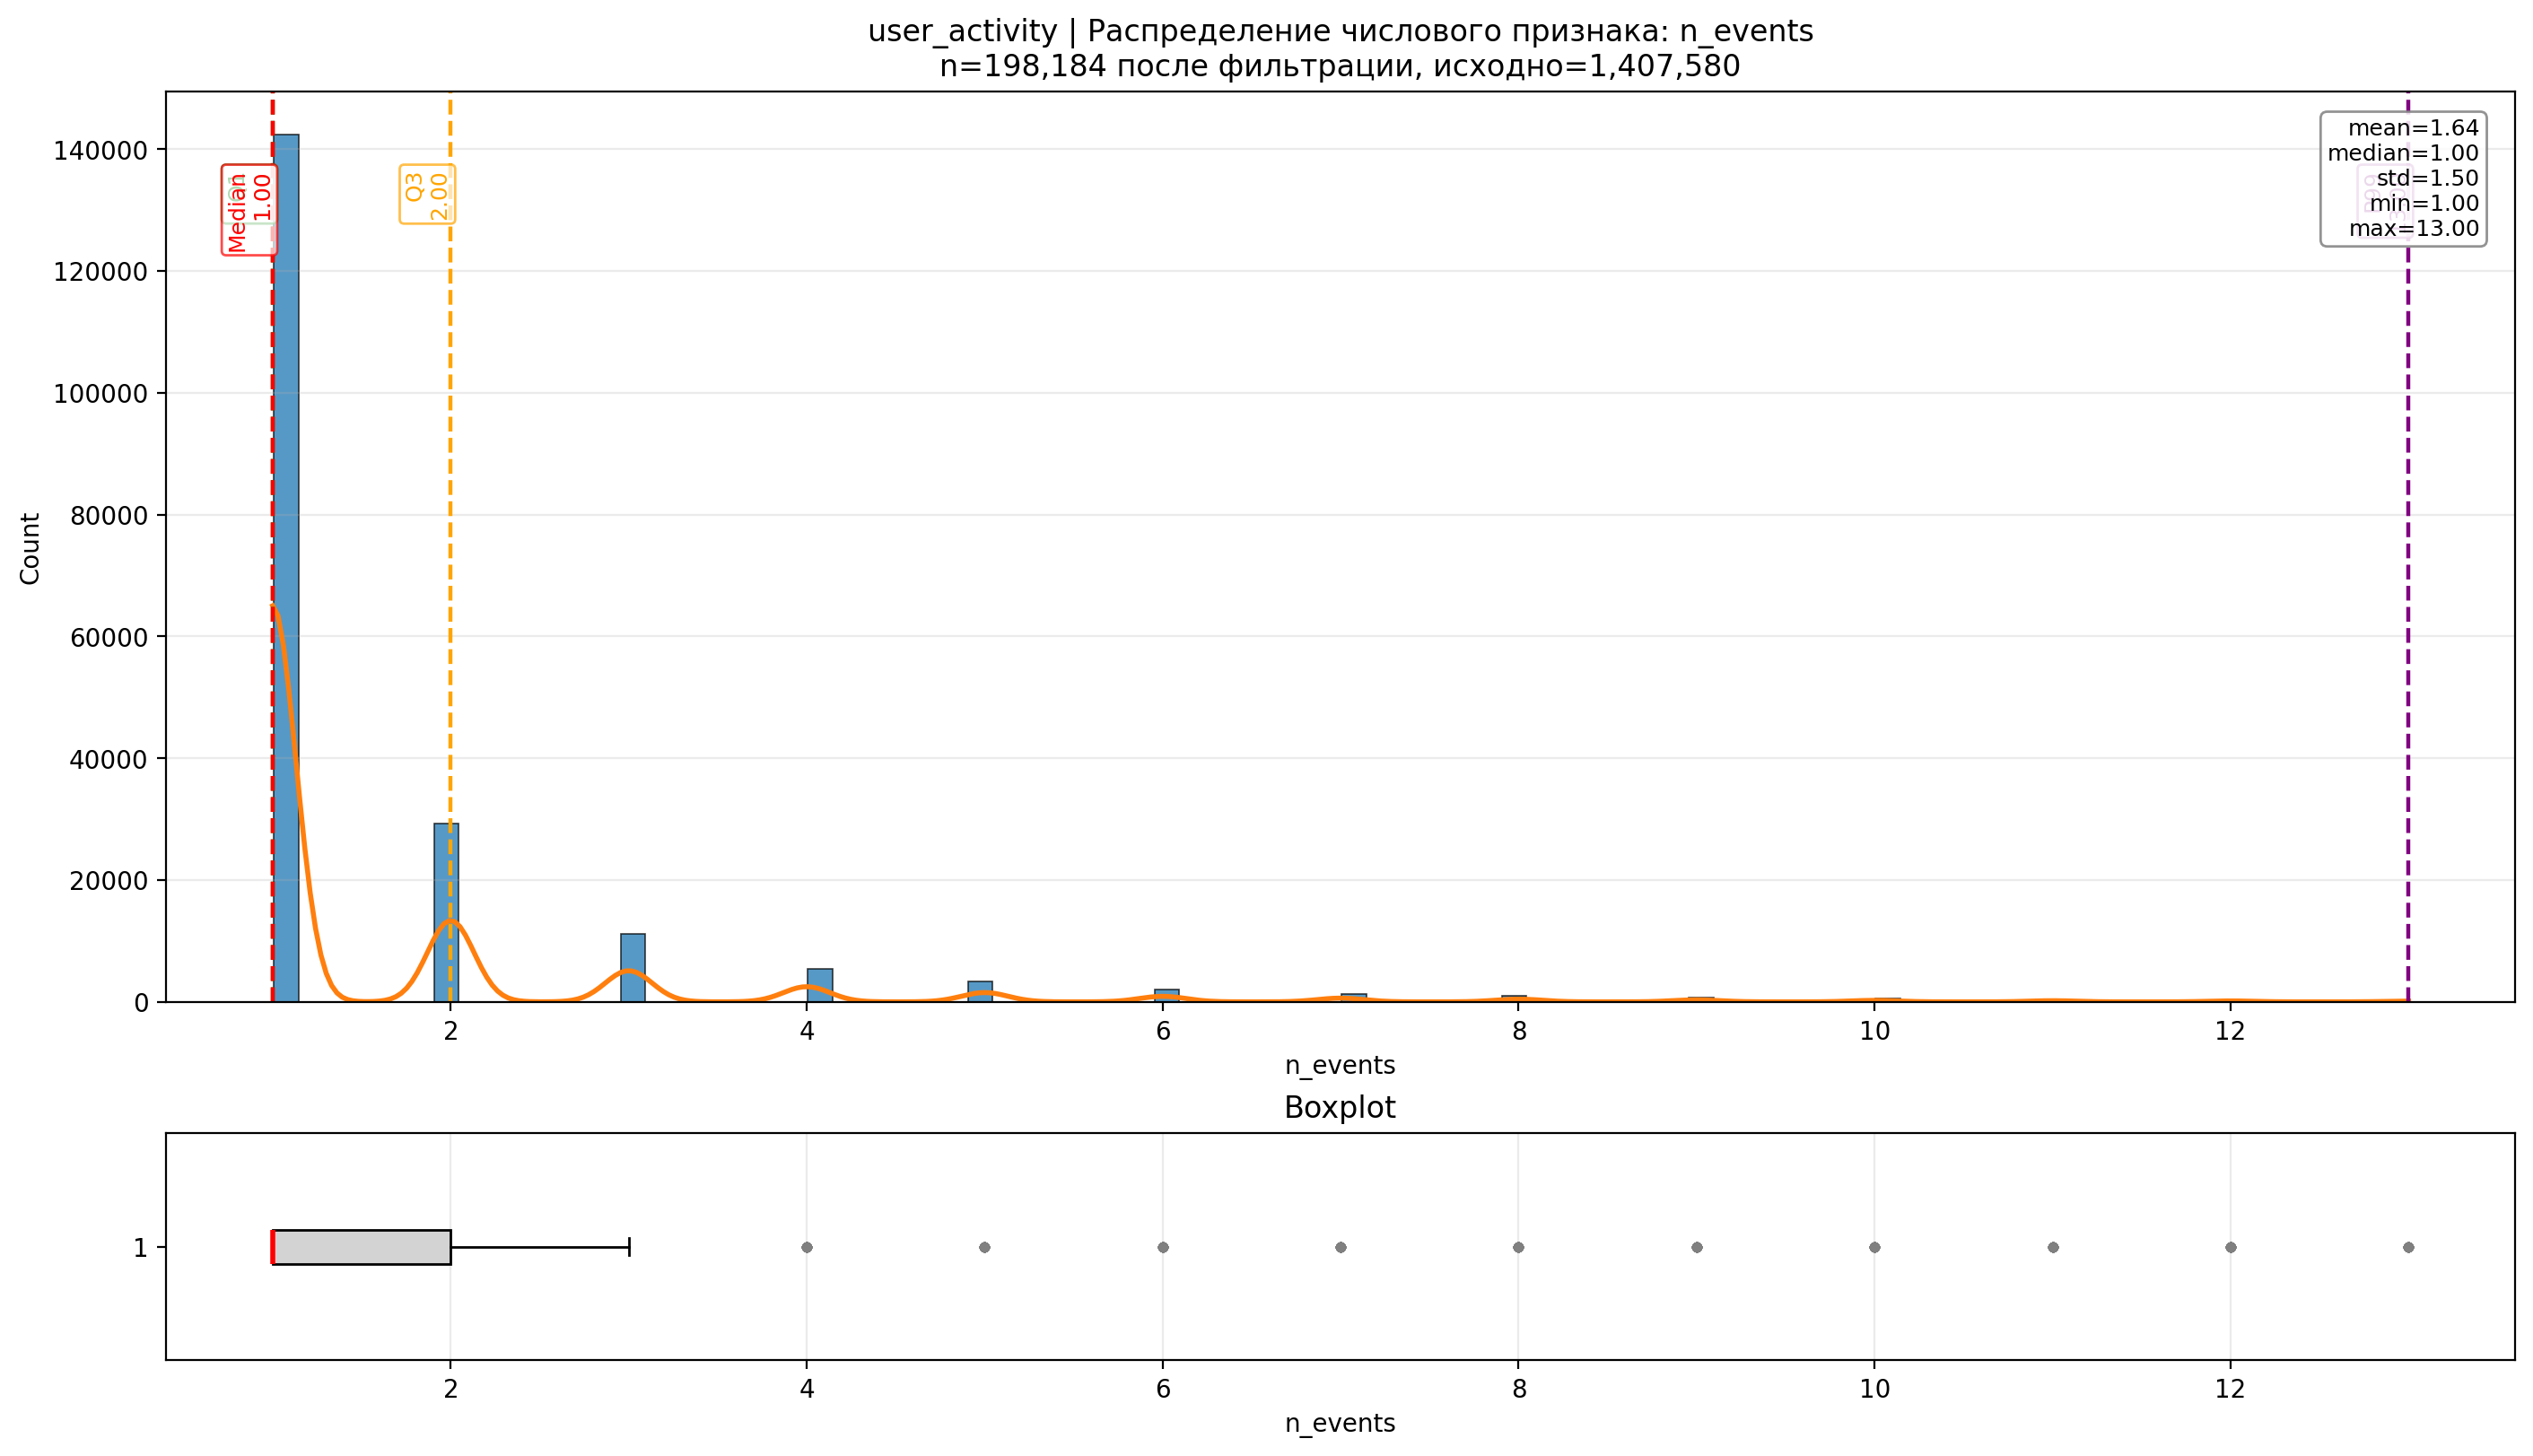

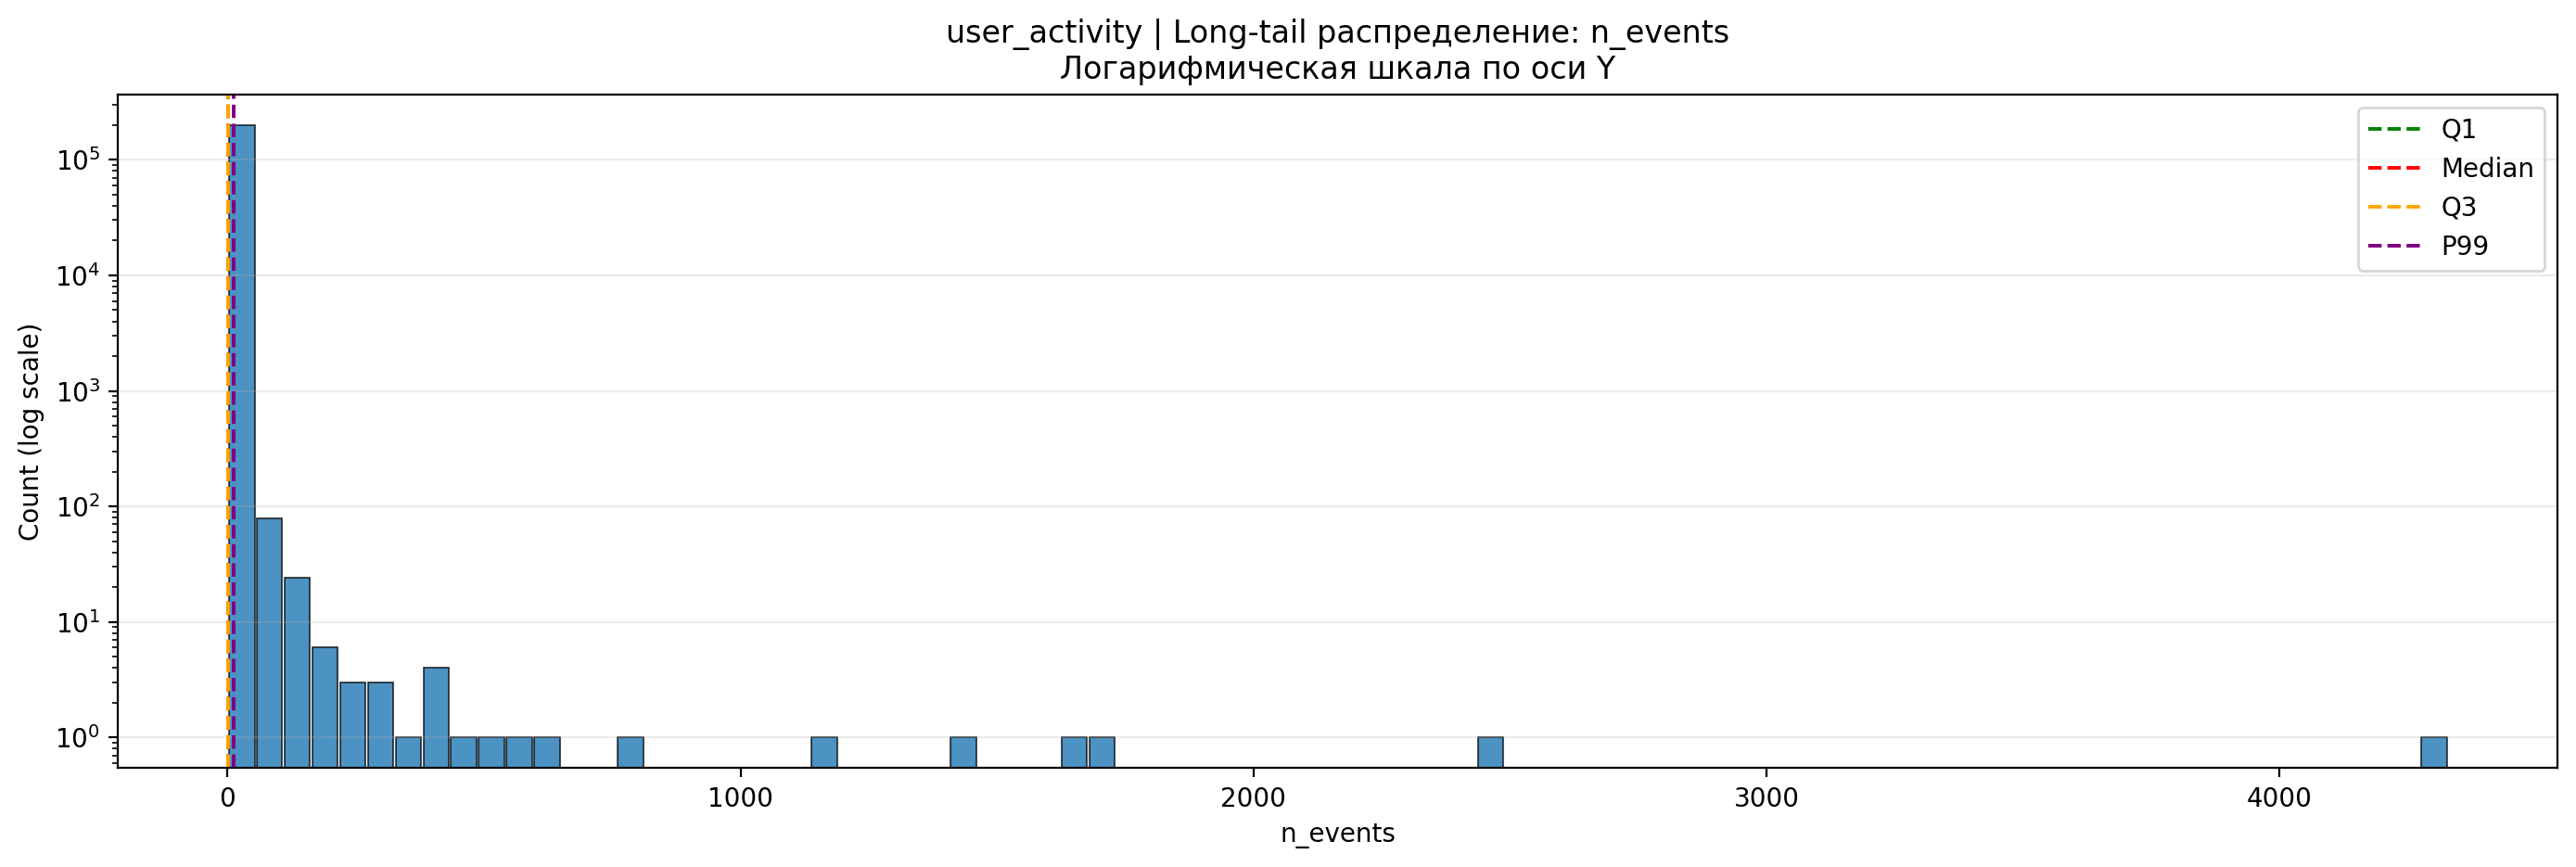

In [87]:
plot_numeric_distribution(
    user_activity,
    "n_events",
    dataset_name="user_activity",
    percentile=0.99,
    bins=80,
    show_log_hist=True,
)

### Выводы по активности пользователей:

---

### Активность пользователей

**1. Сильный long-tail**

Распределение сильно скошено:

* медиана = 1 событие
* 75% пользователей ≤ 2 событий
  * подавляющее большинство — малоактивные пользователи

---

**2. Высокая разреженность данных**

* среднее ≈ 2, при max = 7757
  * присутствует небольшой сегмент сверхактивных пользователей

---

**3. Доминирование “одноразовых” пользователей**

* ≥50% пользователей имеют всего 1 событие
  * выраженная проблема cold start

---

**4. Наличие power users**

* длинный хвост до тысяч событий
  * небольшой сегмент генерирует значительную часть взаимодействий

---

### Импликации

* необходимо учитывать cold start (popularity, content-based)
* логарифмическое или clipping-преобразование активности
* добавление признаков:

  * user_activity
  * user_segment (low / medium / high)

---

### Итог

Поведение пользователей крайне неравномерно:
основная масса — слабоактивные, при этом небольшой процент пользователей формирует основной объем событий.

### 7.2.4 Популярность товаров

In [88]:
item_popularity = events.groupby("itemid").size().reset_index(name="n_events")

item_popularity["n_events"].describe()

count   235,061
mean         12
std          37
min           1
25%           1
50%           3
75%           9
max       3,412
Name: n_events, dtype: float64

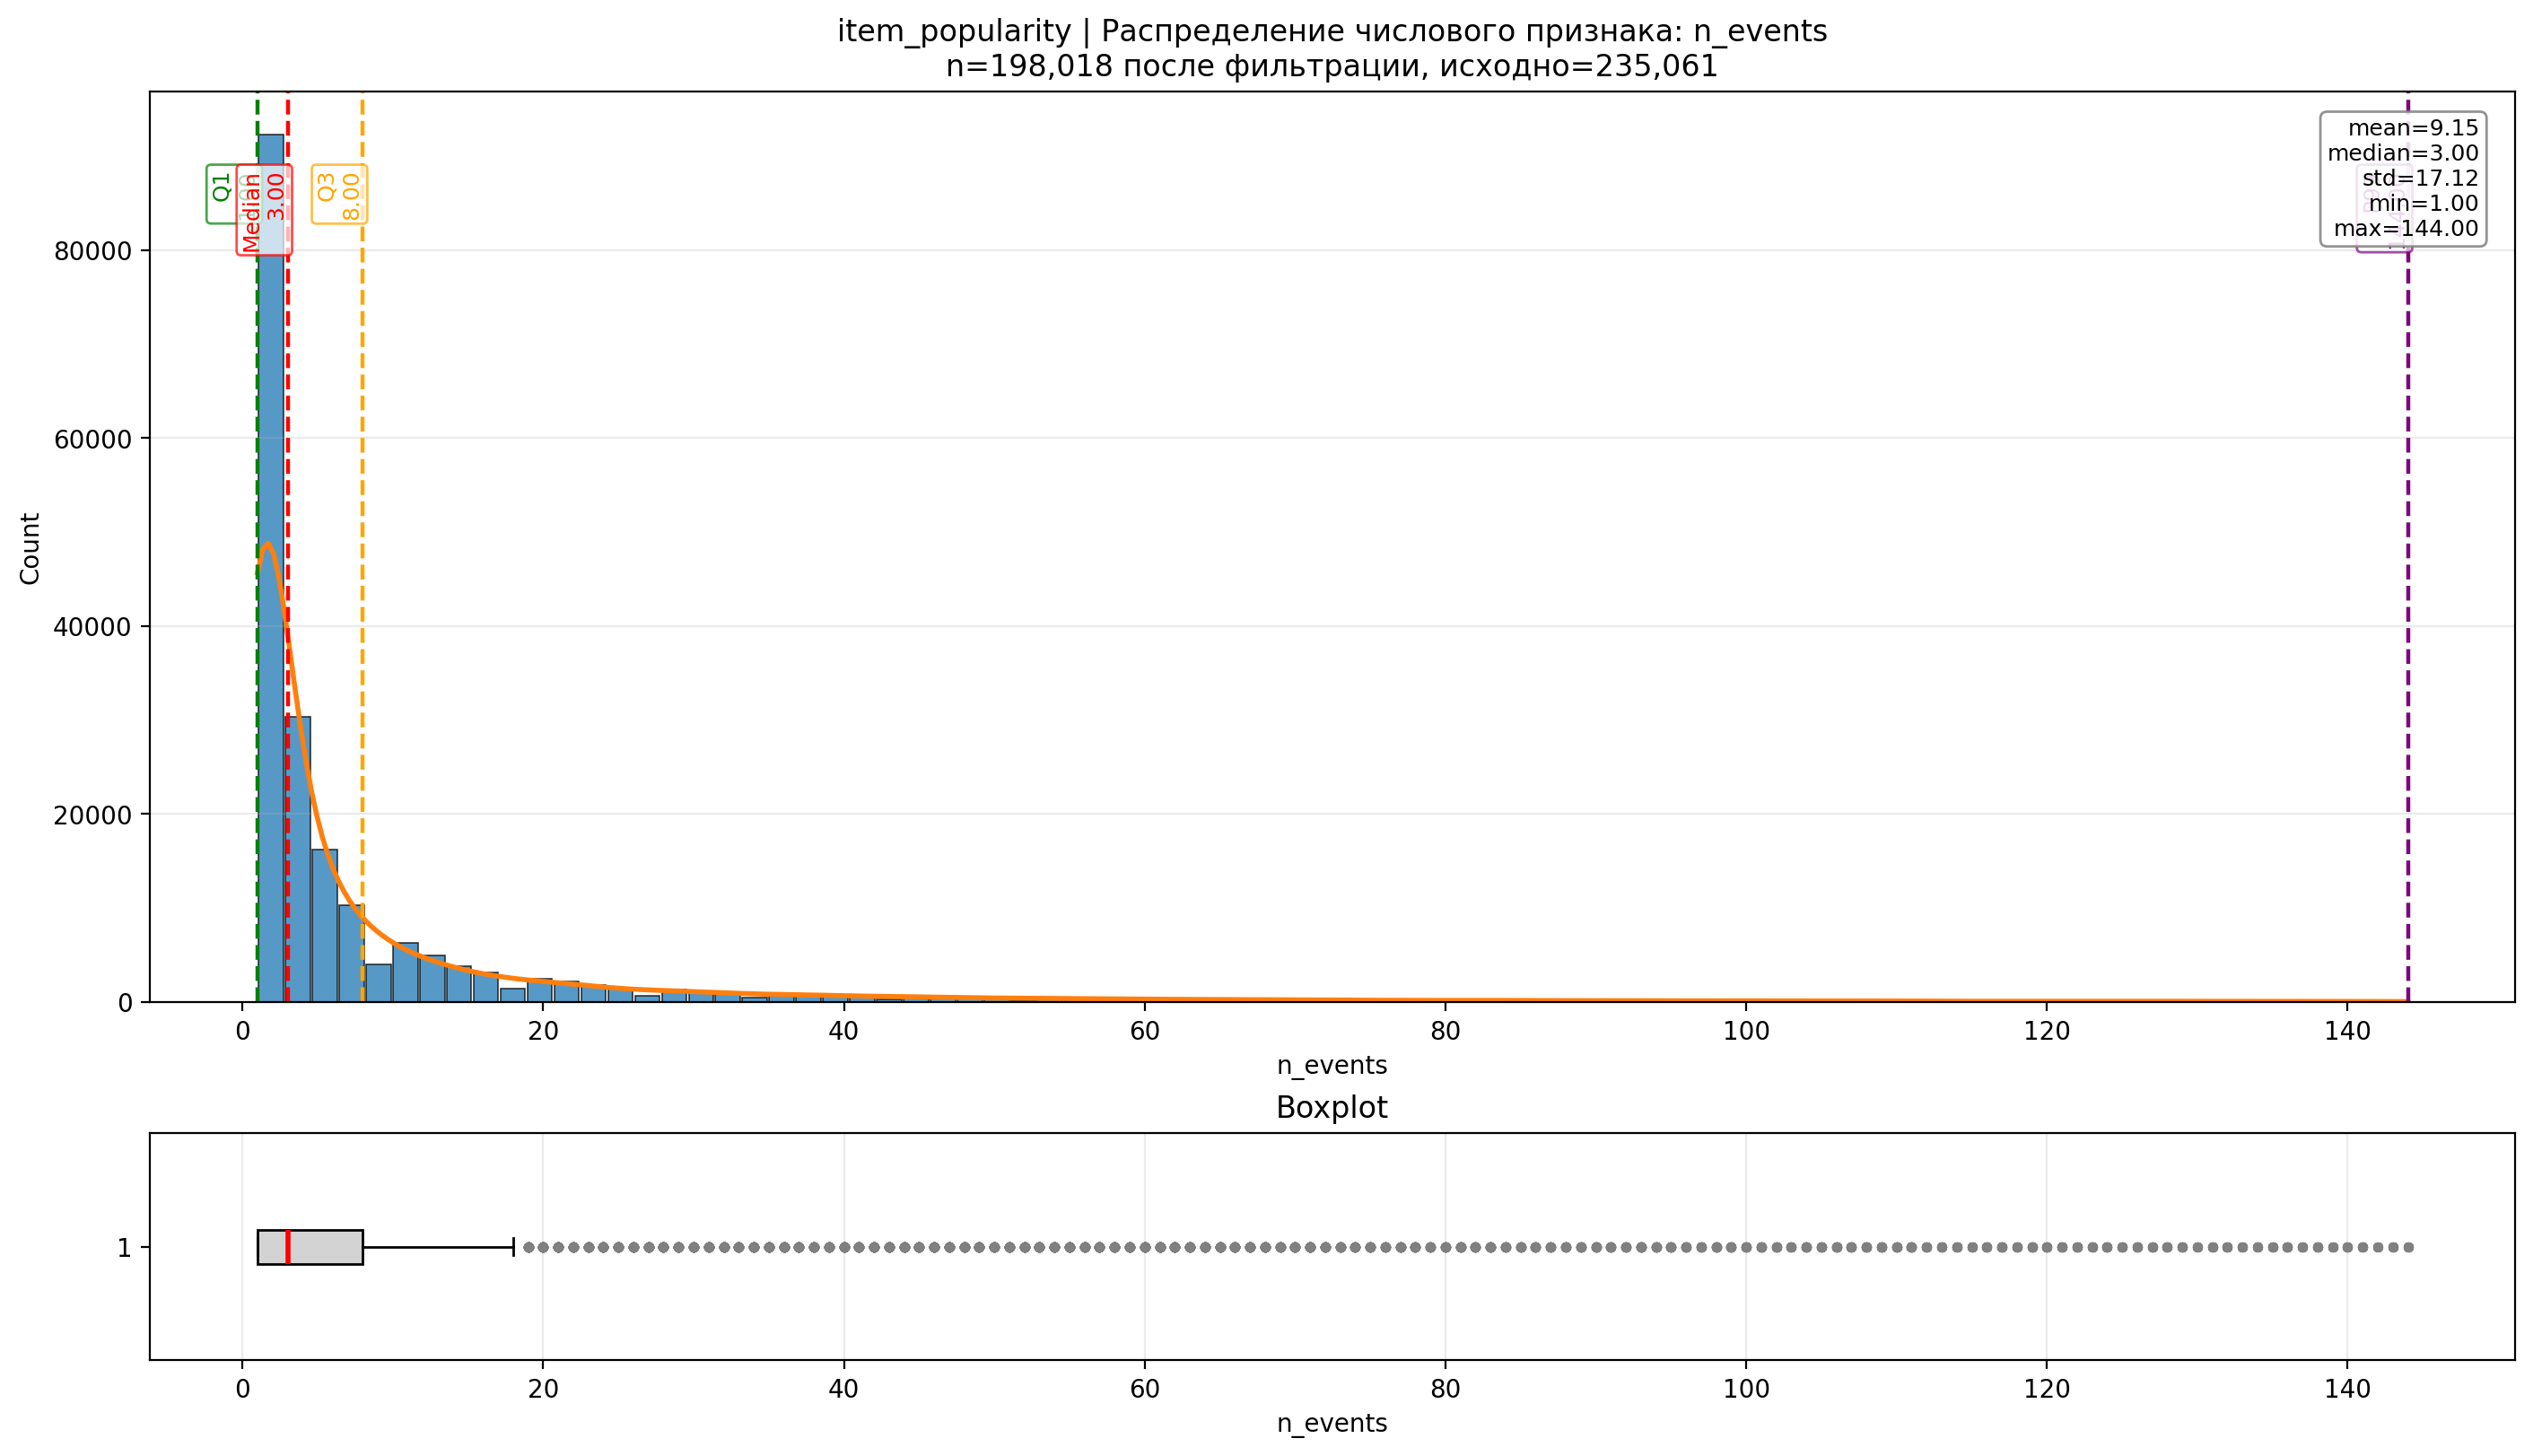

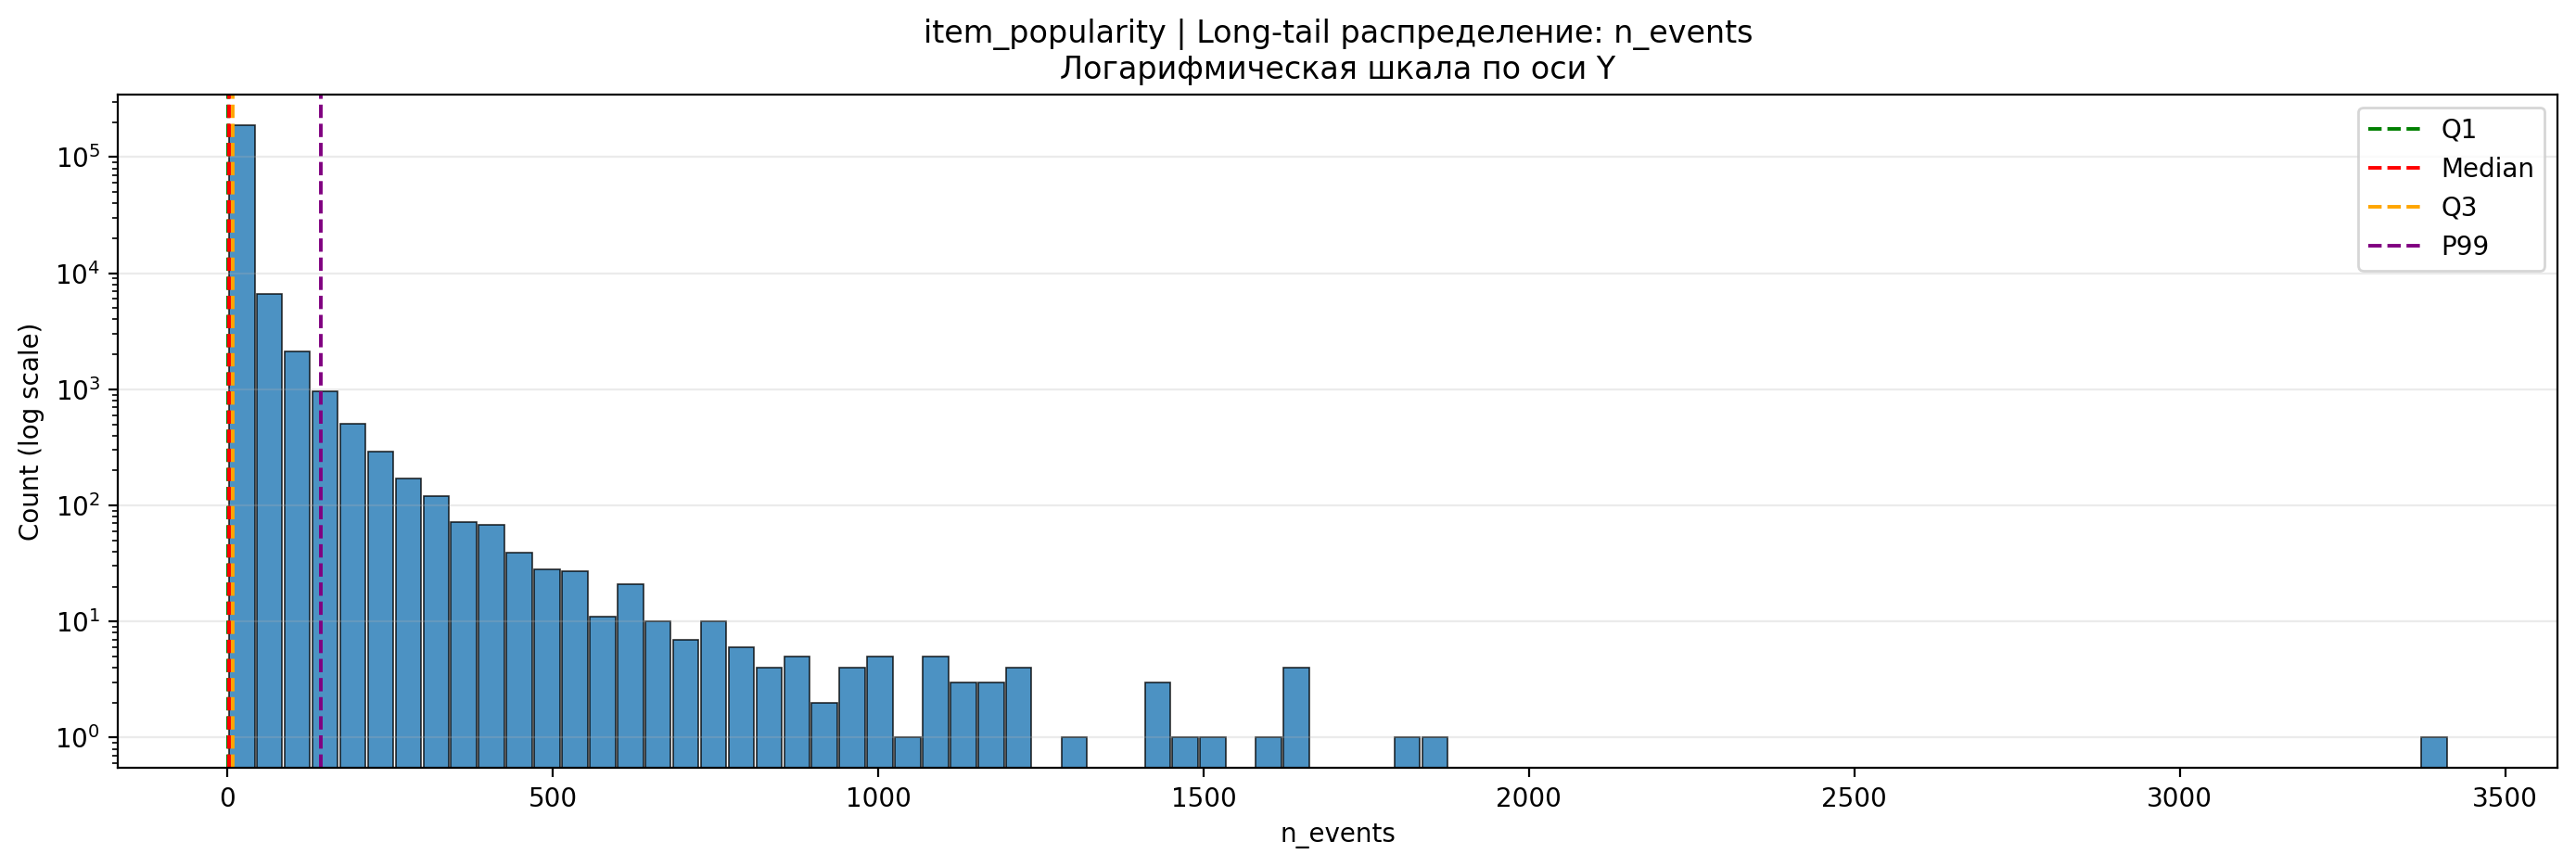

In [89]:
plot_numeric_distribution(
    item_popularity,
    "n_events",
    dataset_name="item_popularity",
    percentile=0.99,
    bins=80,
    show_log_hist=True,
)

## Выводы Популярность товаров

**1. Сильный long-tail распределения**

* медиана = 3 события
* 75% товаров ≤ 9 событий
  * большинство товаров имеют низкую популярность

---

**2. Высокая дисперсия**

* среднее ≈ 11.7 при max = 3412
  * небольшой набор товаров значительно популярнее остальных

---

**3. Доминирование “редких” товаров**

* значительная доля товаров встречается 1–3 раза
  * выраженная разреженность item-пространства

---

**4. Наличие “хитов”**

* длинный хвост до тысяч событий
  * популярные товары формируют существенную часть взаимодействий

---

### Импликации

* необходимо учитывать popularity bias
* использовать:

  * popular baseline (Top-N)
  * нормализацию/логарифмирование популярности
* добавить признаки:

  * item_popularity
  * item_rank / percentile

---

### Итог

Распределение популярности товаров крайне неравномерное:
большинство товаров — низкопопулярные, при этом небольшой пул “хитов” концентрирует основную активность.


### 7.2.5 Funnel по событиям

In [90]:
event_counts = events["event"].value_counts()
event_share = events["event"].value_counts(normalize=True) * 100

display(pd.DataFrame({"count": event_counts, "share_percent": event_share.round(2)}))

,count,share_percent
event,,
view,2664312,97
addtocart,69332,3
transaction,22457,1


### Выводы Funnel по событиям

**1. Сильный перекос в сторону просмотров**

* view: ~96.7%
* addtocart: ~2.5%
* transaction: ~0.8%
  * основная масса взаимодействий — просмотры

---

**2. Низкая конверсия на верхнем уровне воронки**

* view → addtocart ≈ 2.6%
  * слабый переход к целевому действию

---

**3. Относительно высокая конверсия нижнего уровня**

* addtocart → transaction ≈ 32%
  * добавление в корзину — сильный сигнал покупки

---

### Интерпретация

* воронка “широкая сверху, узкая снизу”
* ключевой bottleneck — переход **view → addtocart**

---

### Импликации

* основной фокус оптимизации:

  * улучшение рекомендаций на этапе просмотра
* использование addtocart как:

  * таргета
  * сильного фиче-признака

---

### Итог

Конверсия ограничена на этапе просмотра:
при этом пользователи, добавившие товар в корзину, с высокой вероятностью совершают покупку.


### 7.2.6 Разреженность user-item матрицы (sparsity)

In [94]:
n_users = events["visitorid"].nunique()
n_items = events["itemid"].nunique()
n_interactions = len(events)

density = n_interactions / (n_users * n_items)

print("Users:", n_users)
print("Items:", n_items)
print("Interactions:", n_interactions)
print("Matrix density:", density)

Users: 1407580
Items: 235061
Interactions: 2756101
Matrix density: 8.32993210983756e-06


### Выводы Разреженность user-item матрицы

**1. Крайне высокая разреженность**

* density ≈ 0.0000083 (≈ 0.00083%)
  * подавляющее большинство user-item пар отсутствует

---

**2. Типичный сценарий для рекомендательных систем**

* ~1.4 млн пользователей
* ~235 тыс товаров
  * огромная матрица взаимодействий с очень малым числом наблюдений

---

**3. Низкое покрытие взаимодействий**
* большинство пользователей взаимодействуют с очень малым числом товаров
* большинство товаров имеют ограниченное число взаимодействий

---

### Импликации

* необходимость использования:

  * коллаборативной фильтрации (ALS, implicit)
  * факторизационных моделей
* важность:

  * negative sampling
  * implicit feedback подхода
* добавление:

  * popularity-based фичей
  * user/item embeddings

---

### Итог

Данные сильно разрежены, что исключает простые методы и требует использования специализированных алгоритмов рекомендательных систем с учетом implicit feedback.


### 7.2.7 Cold-start анализ

### Пользователи

In [95]:
user_counts = events["visitorid"].value_counts()

print("Users with 1 event:", (user_counts == 1).sum())
print("Share of users with 1 event:", round((user_counts == 1).mean(), 4))

Users with 1 event: 1001560
Share of users with 1 event: 0.7115


### Товары

In [96]:
item_counts = events["itemid"].value_counts()

print("Items with 1 event:", (item_counts == 1).sum())
print("Share of items with 1 event:", round((item_counts == 1).mean(), 4))

Items with 1 event: 73609
Share of items with 1 event: 0.3131


### Выводы Cold-start анализ

#### Пользователи

* **~71% пользователей имеют только 1 событие**
  * подавляющее большинство — cold users

**Вывод:**
модель почти не имеет истории для персонализации → высокий риск деградации рекомендаций

---

#### Товары

* **~31% товаров имеют только 1 взаимодействие**
  * значительная доля cold items

**Вывод:**
сложно оценить качество и релевантность товаров → проблема покрытия

---

### Общий вывод

* выраженный **cold-start с обеих сторон (user + item)**
* данные:

  * сильно разрежены
  * слабо наблюдаемы

---

### Импликации для системы

* необходимо использовать:

  * popularity-based рекомендации (baseline)
  * content / мета-фичи (если доступны)
* важно:

  * быстрое обновление профиля пользователя (online learning)
  * fallback-стратегии для новых пользователей/товаров

---

### Итог

Cold-start — одна из ключевых проблем в данных, требующая явной обработки в архитектуре рекомендательной системы.


## 7.3 EDA по category_tree

### Корневые категории

In [98]:
root_categories = category_tree["parentid"].isna().sum()

print("Root categories:", root_categories)
print("Share of root categories:", round(root_categories / len(category_tree), 4))

Root categories: 25
Share of root categories: 0.015


### Распределение идентификаторов

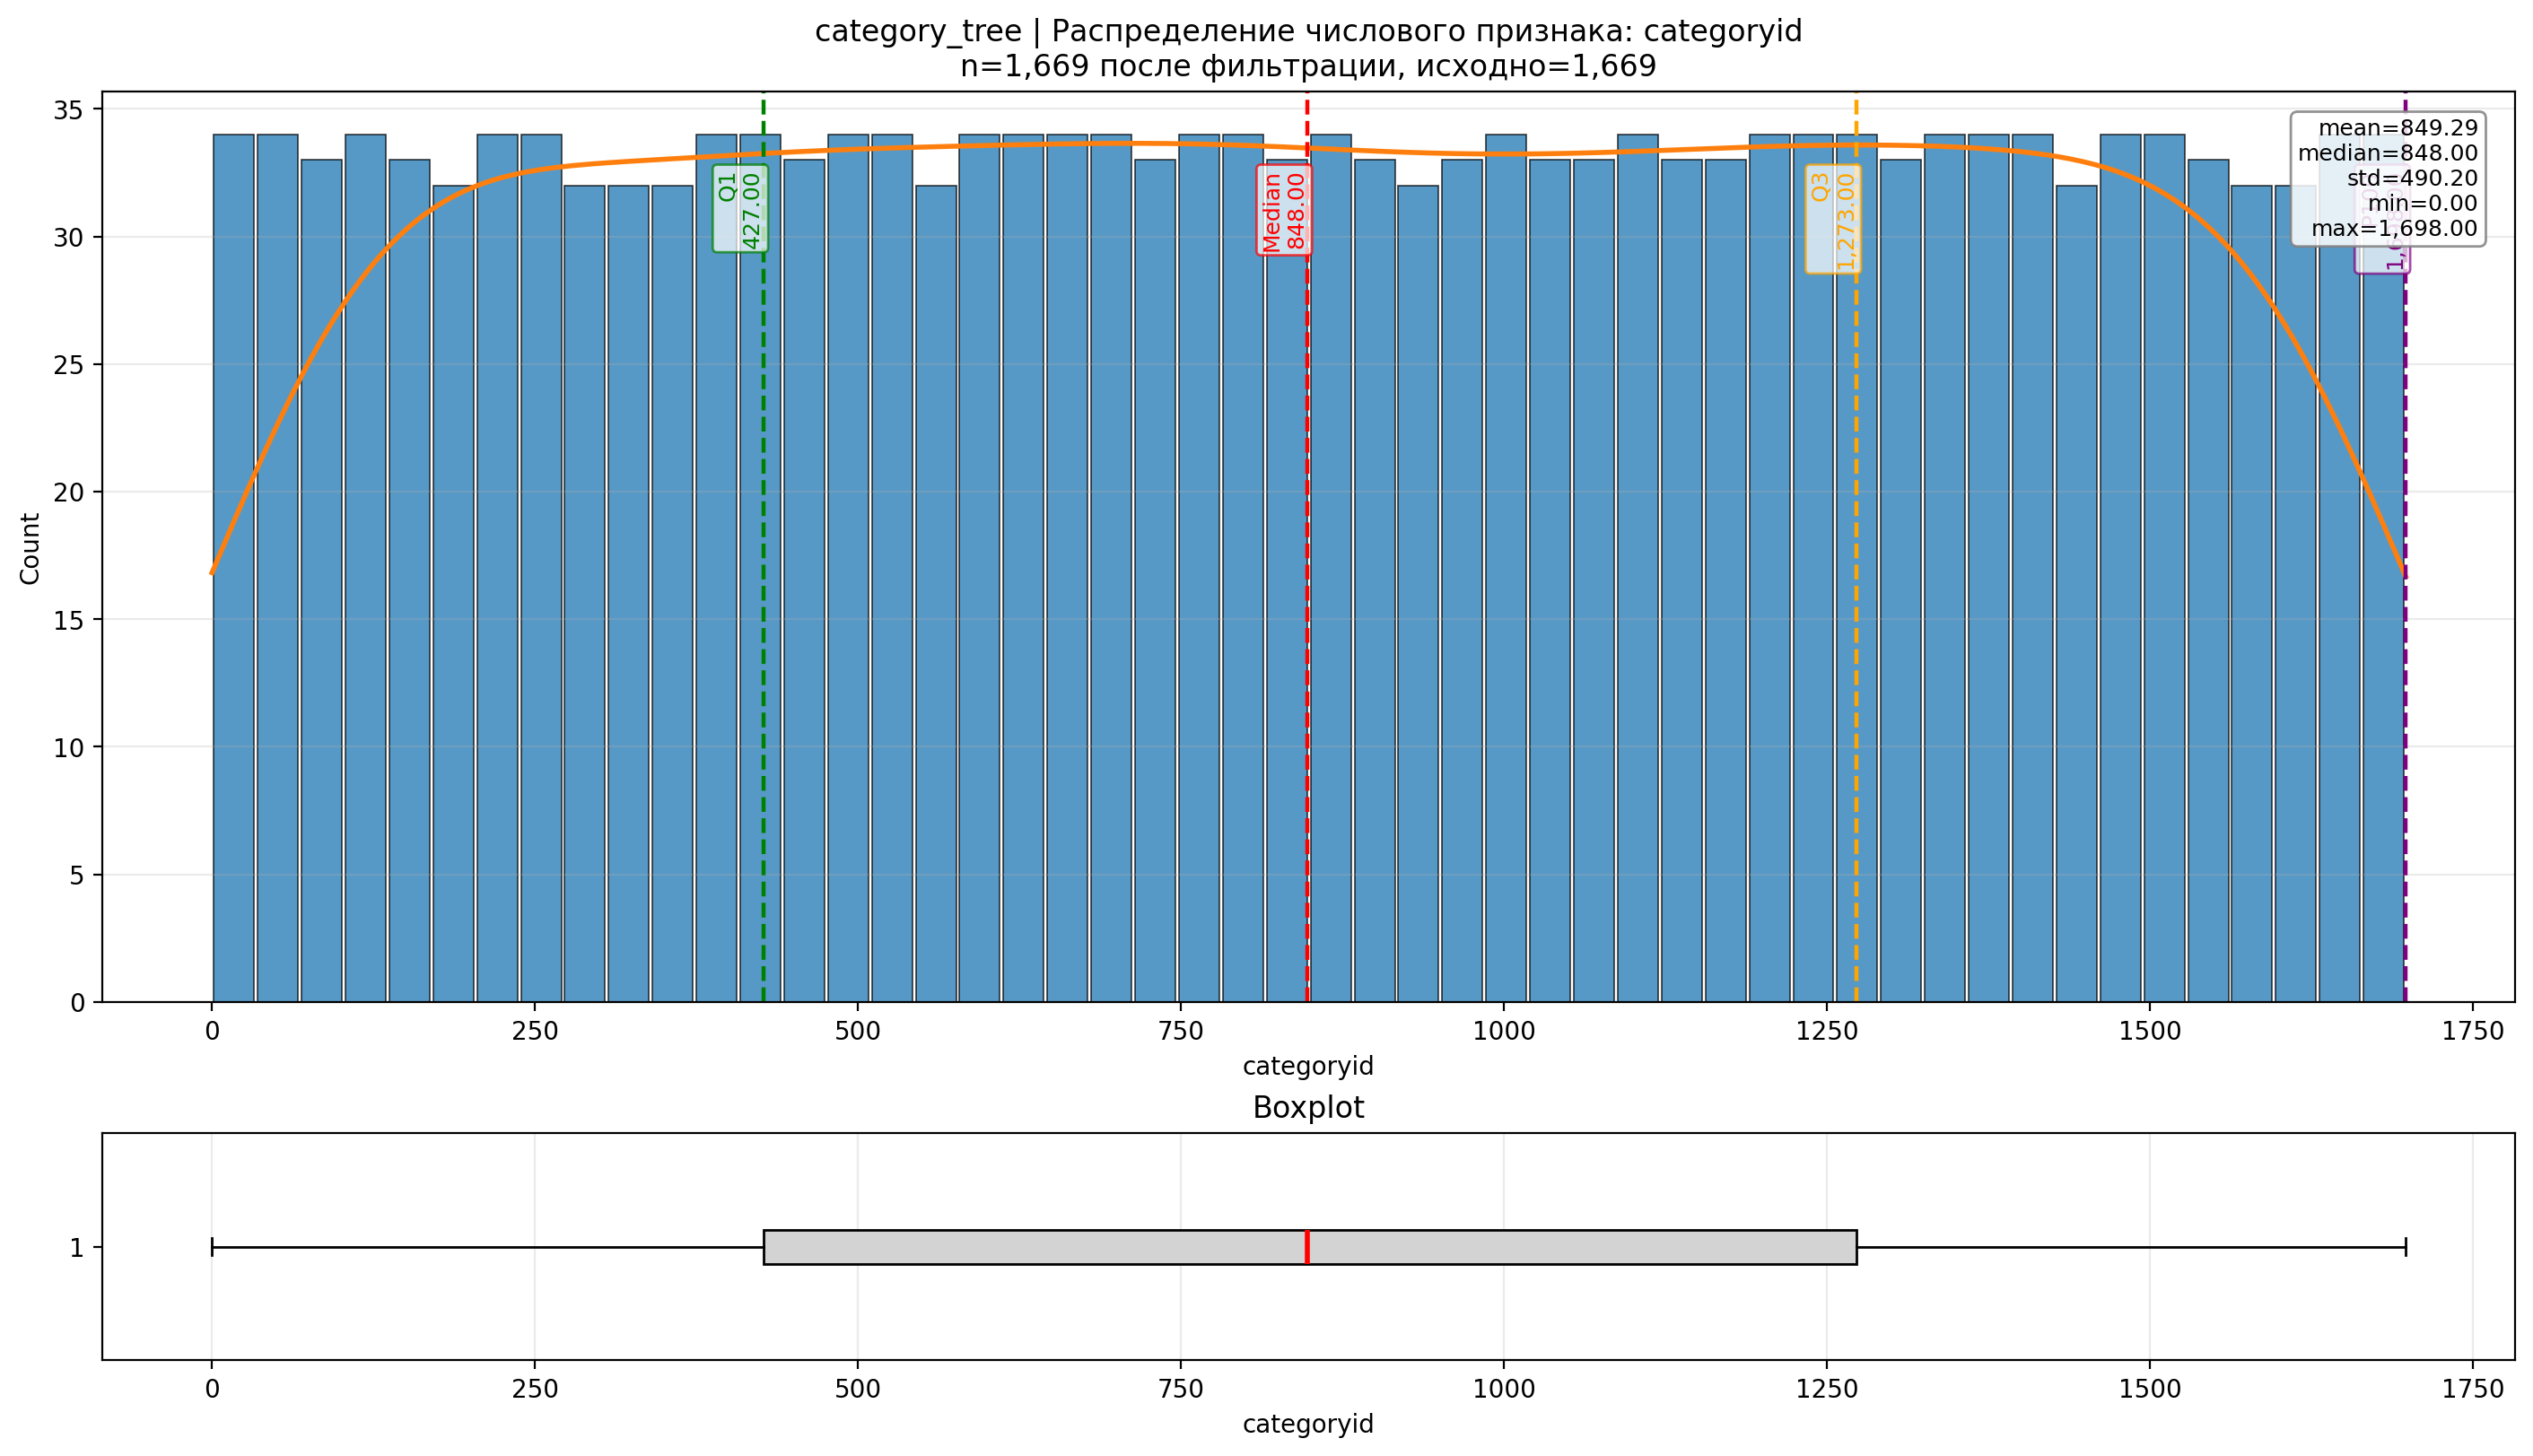

In [99]:
plot_numeric_distribution(
    category_tree,
    "categoryid",
    dataset_name="category_tree",
    percentile=1.0,
    bins=50,
    show_log_hist=False,
)

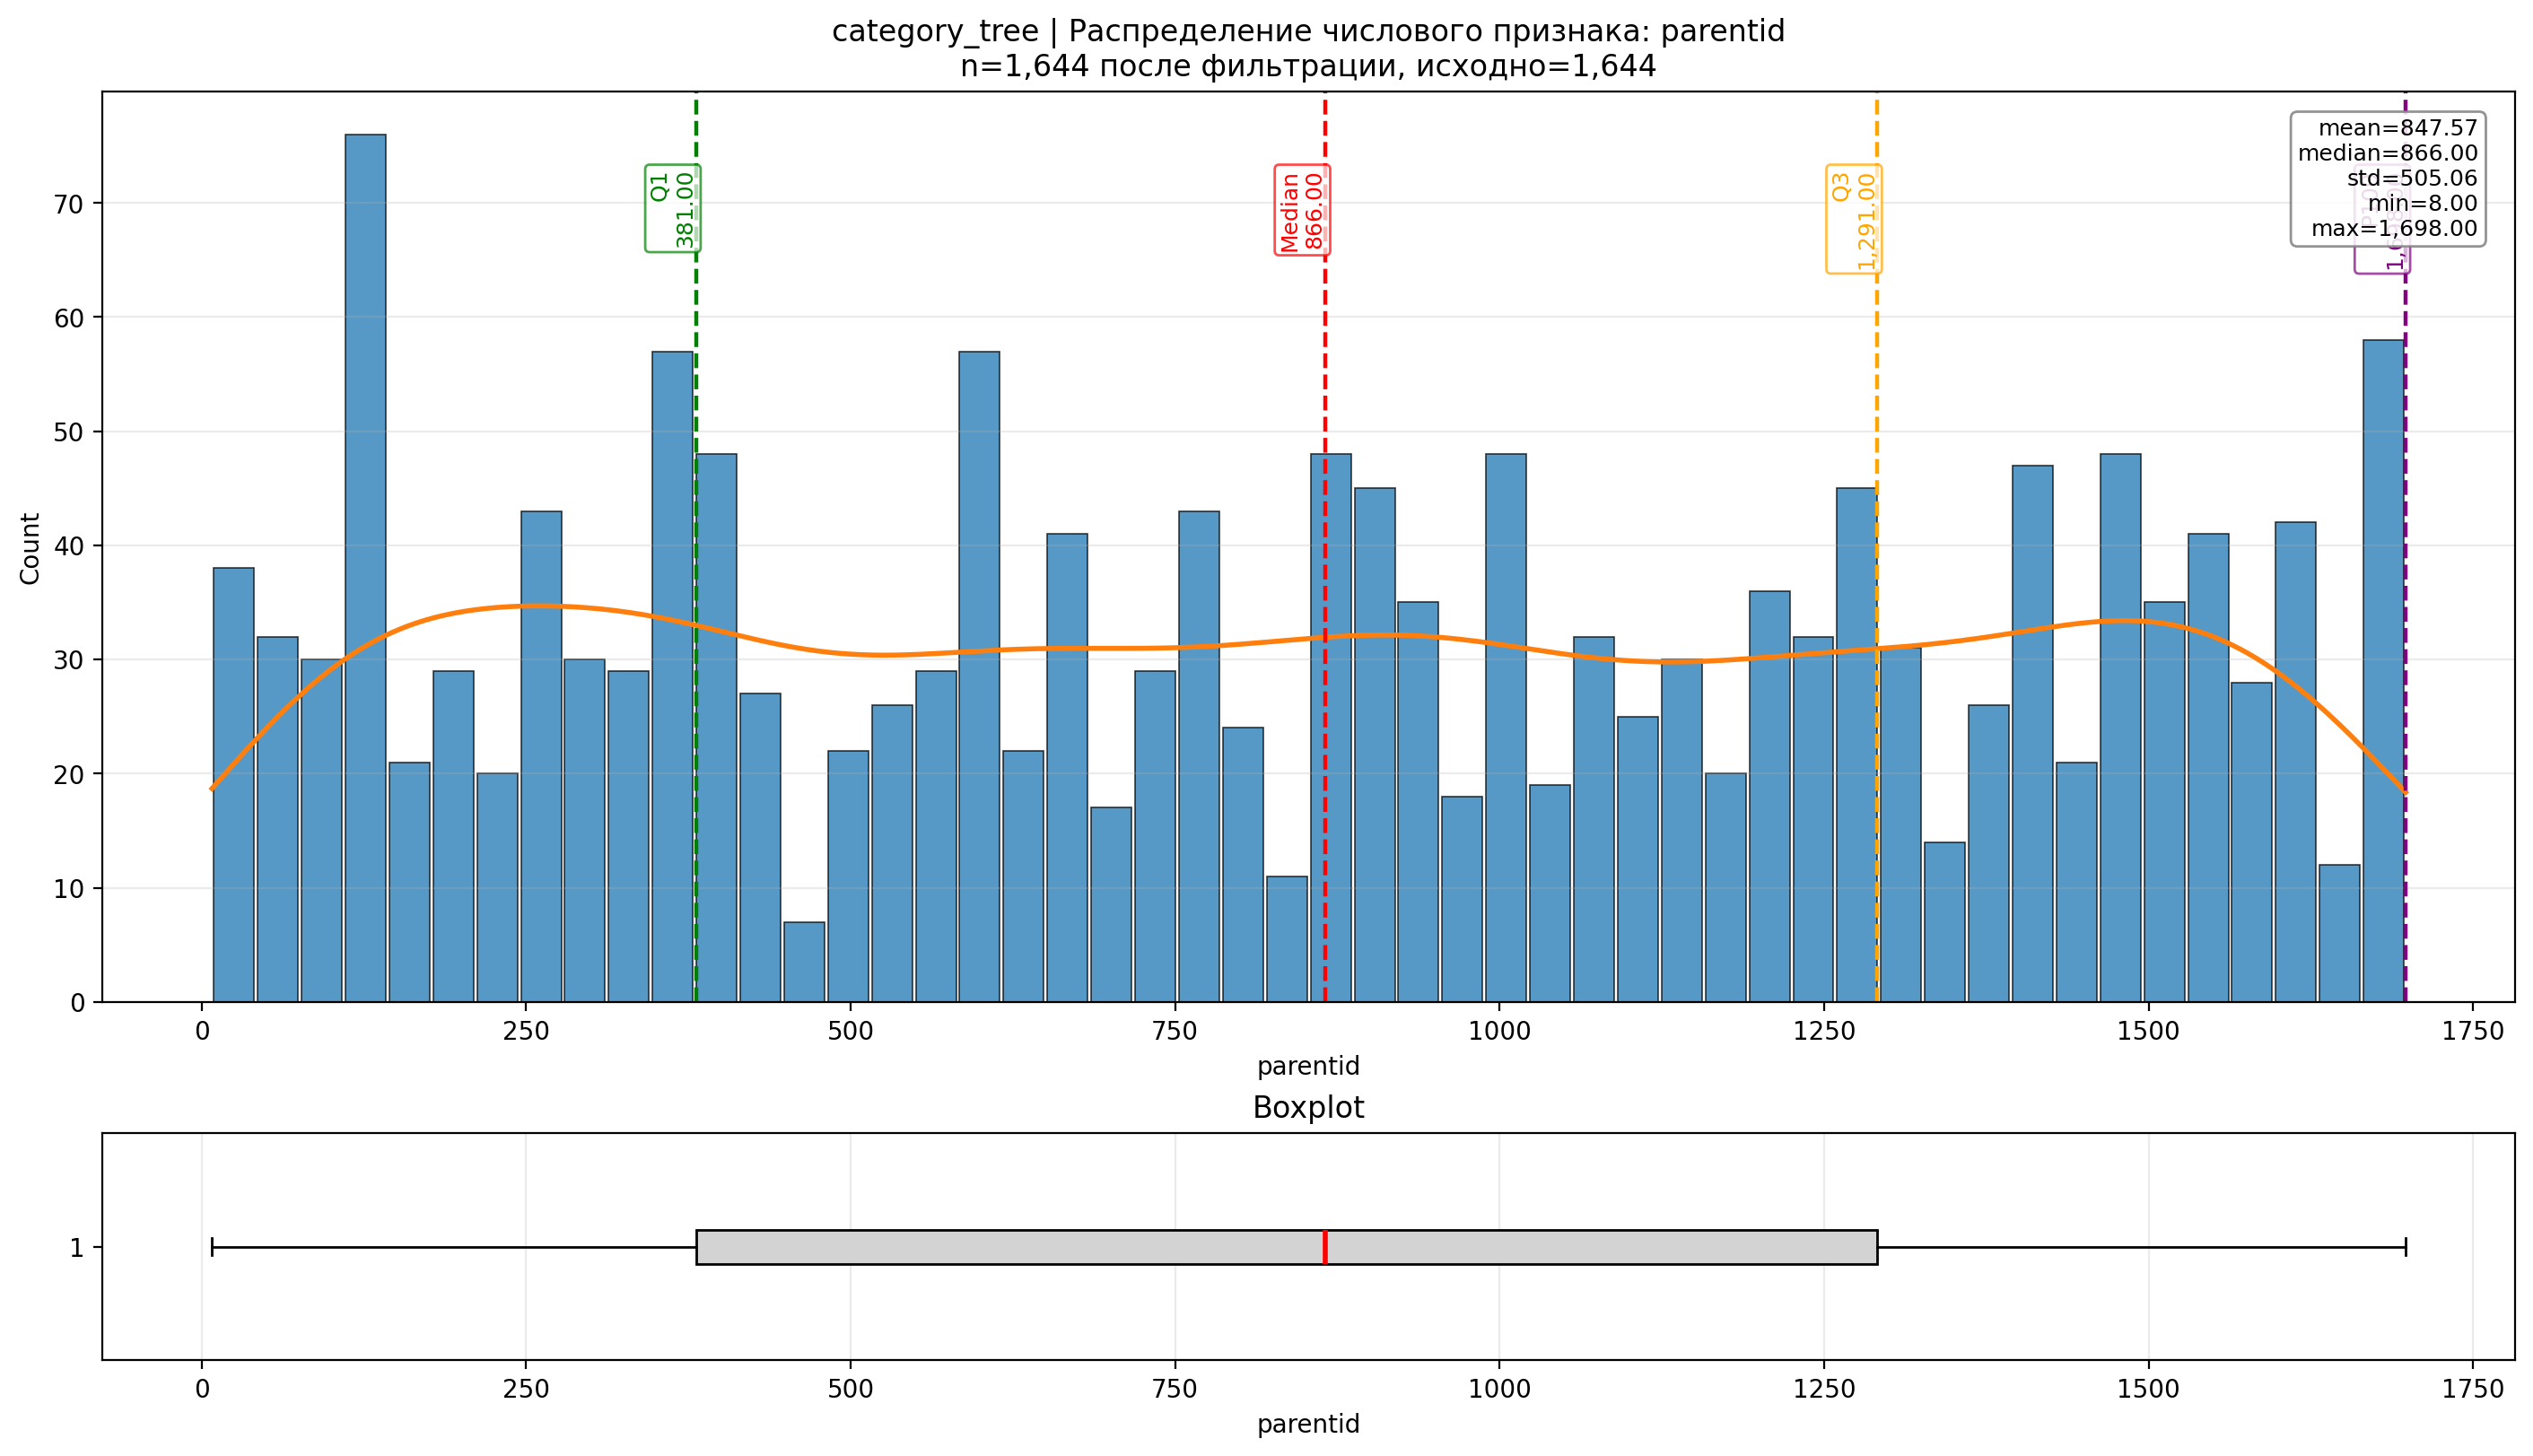

In [100]:
plot_numeric_distribution(
    category_tree.dropna(subset=["parentid"]),
    "parentid",
    dataset_name="category_tree",
    percentile=1.0,
    bins=50,
    show_log_hist=False,
)

### Выводы: Категорийная структура

* **25 корневых категорий** при общем числе **1669 категорий**
  * глубокая иерархия (много уровней)

* **Доля корневых категорий ~1.5%**
  * большинство категорий — вложенные (leaf / mid-level)

---

### Ключевые выводы

* каталог:

  * **сильно иерархический**
  * с высокой детализацией товаров

* категории:

  * хорошо подходят для **агрегации и обобщения**
  * могут компенсировать sparsity на уровне item

---

### Импликации для рексистемы

* использовать:

  * **category-level фичи** (parent / root категории)
  * **иерархические признаки** (level, глубина)

* для cold-start:

  * рекомендовать через **похожие категории**
  * использовать **популярность внутри категории**

---

### Итог

* Категорийное дерево — сильный источник сигналов,
особенно критичный при разреженности и cold-start.


## 7.4 EDA по item_props: свойства товаров

### Самые частые свойства

In [102]:
item_props["property"].value_counts().head(20)

property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
839            417239
917            417227
112            417053
764            417053
159            417053
227            347492
698            289849
451            264416
663            240813
962            239372
Name: count, dtype: int64

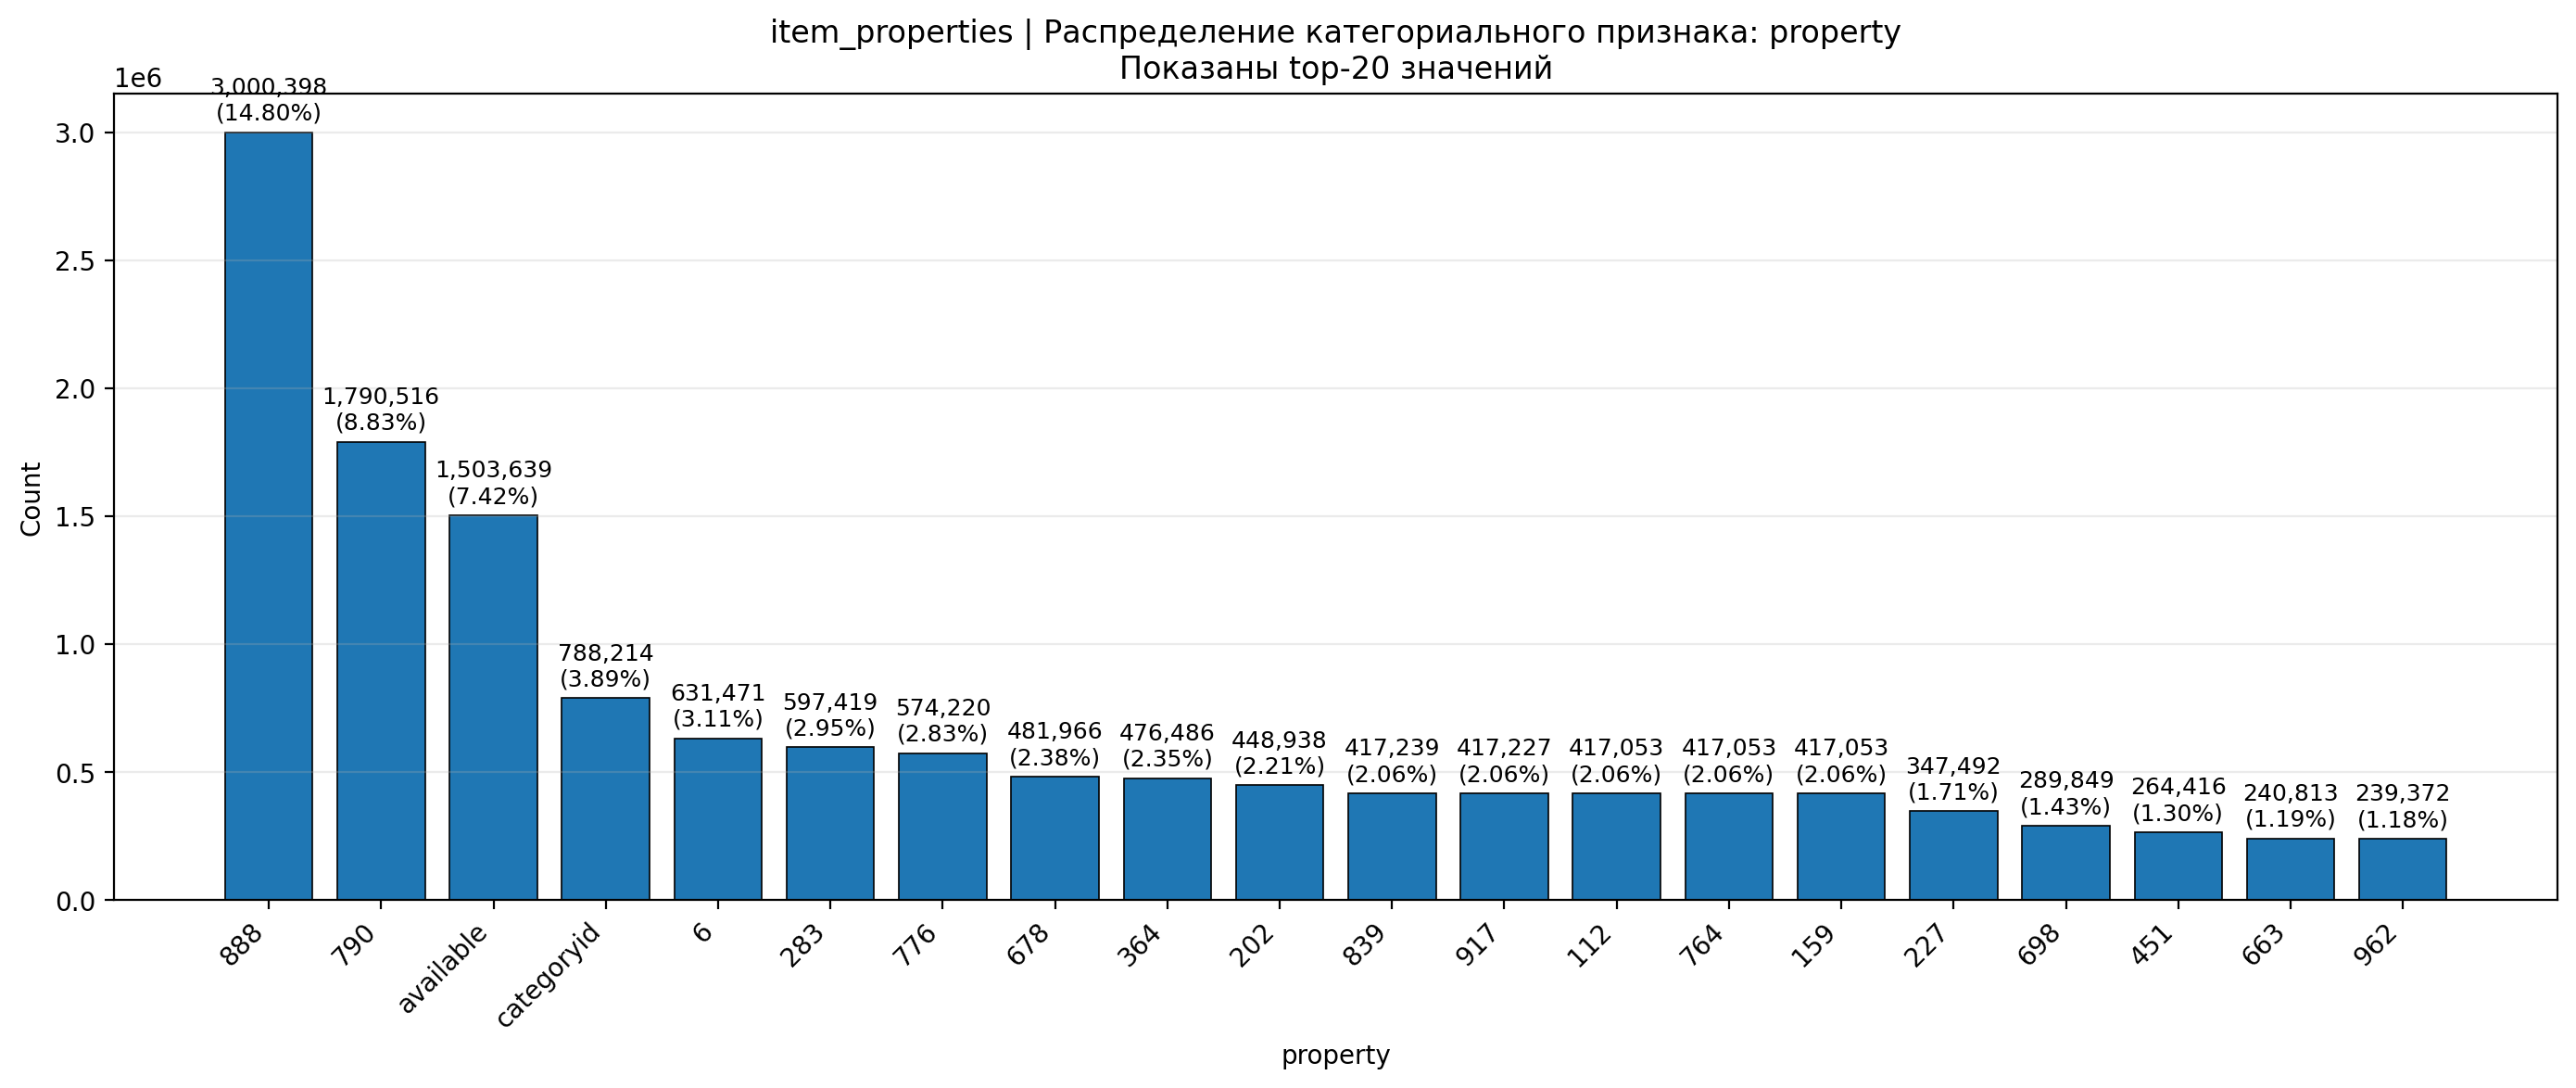

In [103]:
plot_categorical_distribution(
    item_props, "property", dataset_name="item_properties", top_n=20
)

### Выводы Свойства товаров (item_props)

#### Распределение признаков

* наблюдается **сильный перекос по популярности свойств**
* несколько top-признаков (например, `available`, `categoryid`, id-шные признаки) покрывают значительную долю данных
  * long-tail по свойствам

---

### Ключевые выводы

* признаки:

  * **неравномерно распределены**
  * есть “частые” и “редкие” свойства

* часть свойств:

  * семантически понятные (`available`, `categoryid`)
  * часть — **закодированные id (888, 790, …)**
    * требуют расшифровки / интерпретации

---

### Импликации для модели

* важно:

  * отделять **информативные признаки** от шумовых
  * агрегировать редкие свойства

* возможные подходы:

  * top-N properties как фичи
  * frequency encoding / target encoding
  * embedding для свойств

---

### Риски

* high-cardinality признаков → переобучение
* шум от редко встречающихся свойств

---

### Итог

* item_props — мощный источник контентных фичей,
но требует аккуратной обработки (отбор, кодирование, агрегация) для эффективного использования в модели.


### Временная динамика item_props

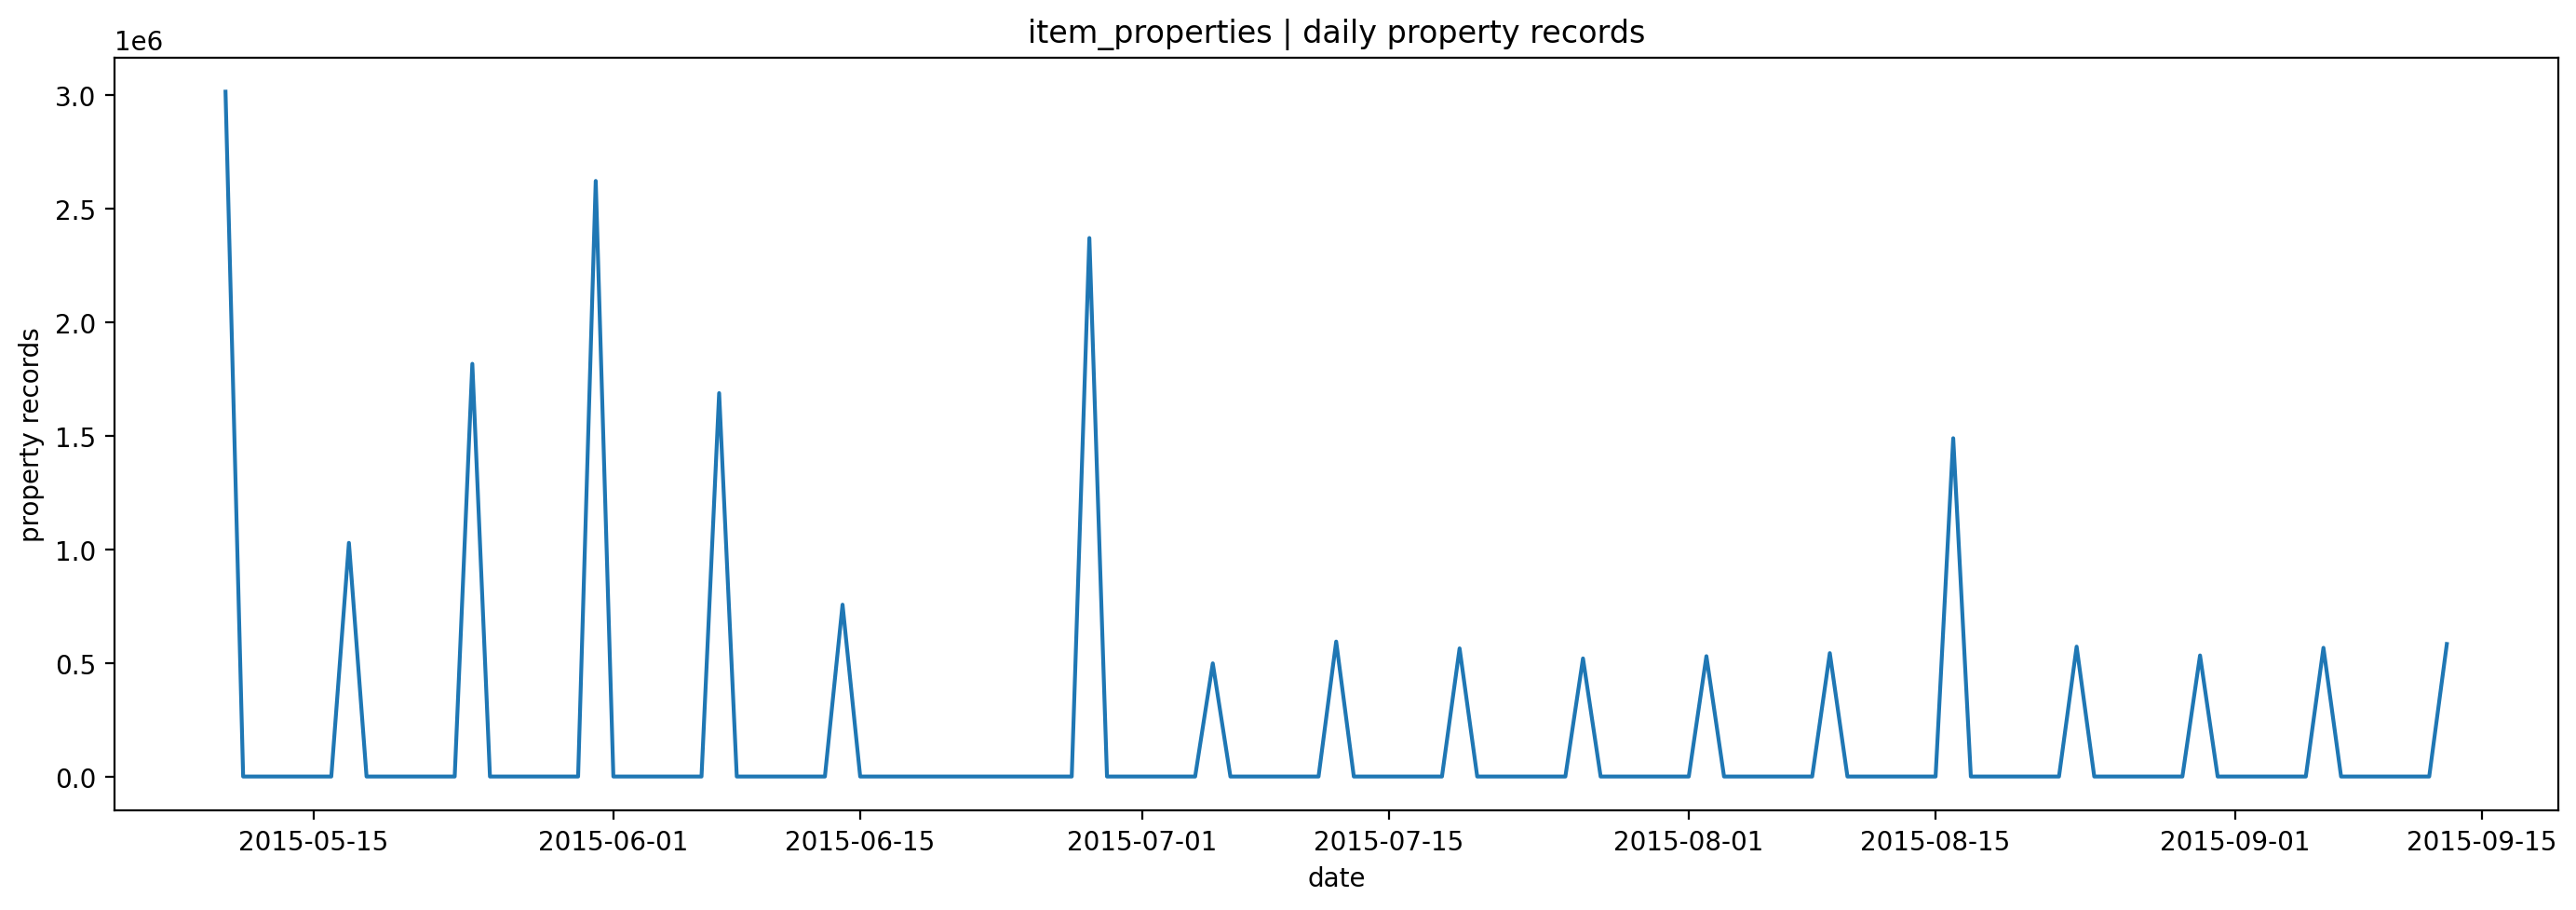

In [105]:
props_by_day = (
    item_props.set_index("timestamp_dt")
    .resample("D")
    .size()
    .reset_index(name="prop_count")
)

plt.figure(figsize=(14, 5))
plt.plot(props_by_day["timestamp_dt"], props_by_day["prop_count"])
plt.title("item_properties | daily property records")
plt.xlabel("date")
plt.ylabel("property records")
plt.tight_layout()
plt.show()

### Временная динамика item_props

* данные обновляются **неравномерно (батчами)**
  * видны резкие пики вместо равномерного потока

* между пиками:

  * периоды с **нулевой или почти нулевой активностью**

---

### Ключевые выводы

* item_props:

  * это не поток событий, а **лог обновлений / снапшотов**
  * вероятно, загружаются **пакетами (ETL / выгрузки)**

---

### Импликации

* нельзя:

  * напрямую использовать timestamp как поведенческий сигнал

* важно:

  * аккуратно делать temporal join с events
  * учитывать, что свойства:

    * могут быть **устаревшими**
    * обновляются дискретно

---

### Риски

* leakage:

  * если использовать будущие значения свойств
* несинхронность:

  * event и item_props могут не совпадать по времени

---

### Итог

* item_props — это **медленно меняющиеся признаки**,
которые нужно использовать как snapshot-фичи с учетом времени, а не как event-level сигнал.


### Сколько свойств приходится на товар

In [106]:
props_per_item = item_props.groupby("itemid").size().reset_index(name="n_properties")

props_per_item["n_properties"].describe()

count   417,053
mean         49
std          27
min          12
25%          28
50%          42
75%          60
max         468
Name: n_properties, dtype: float64

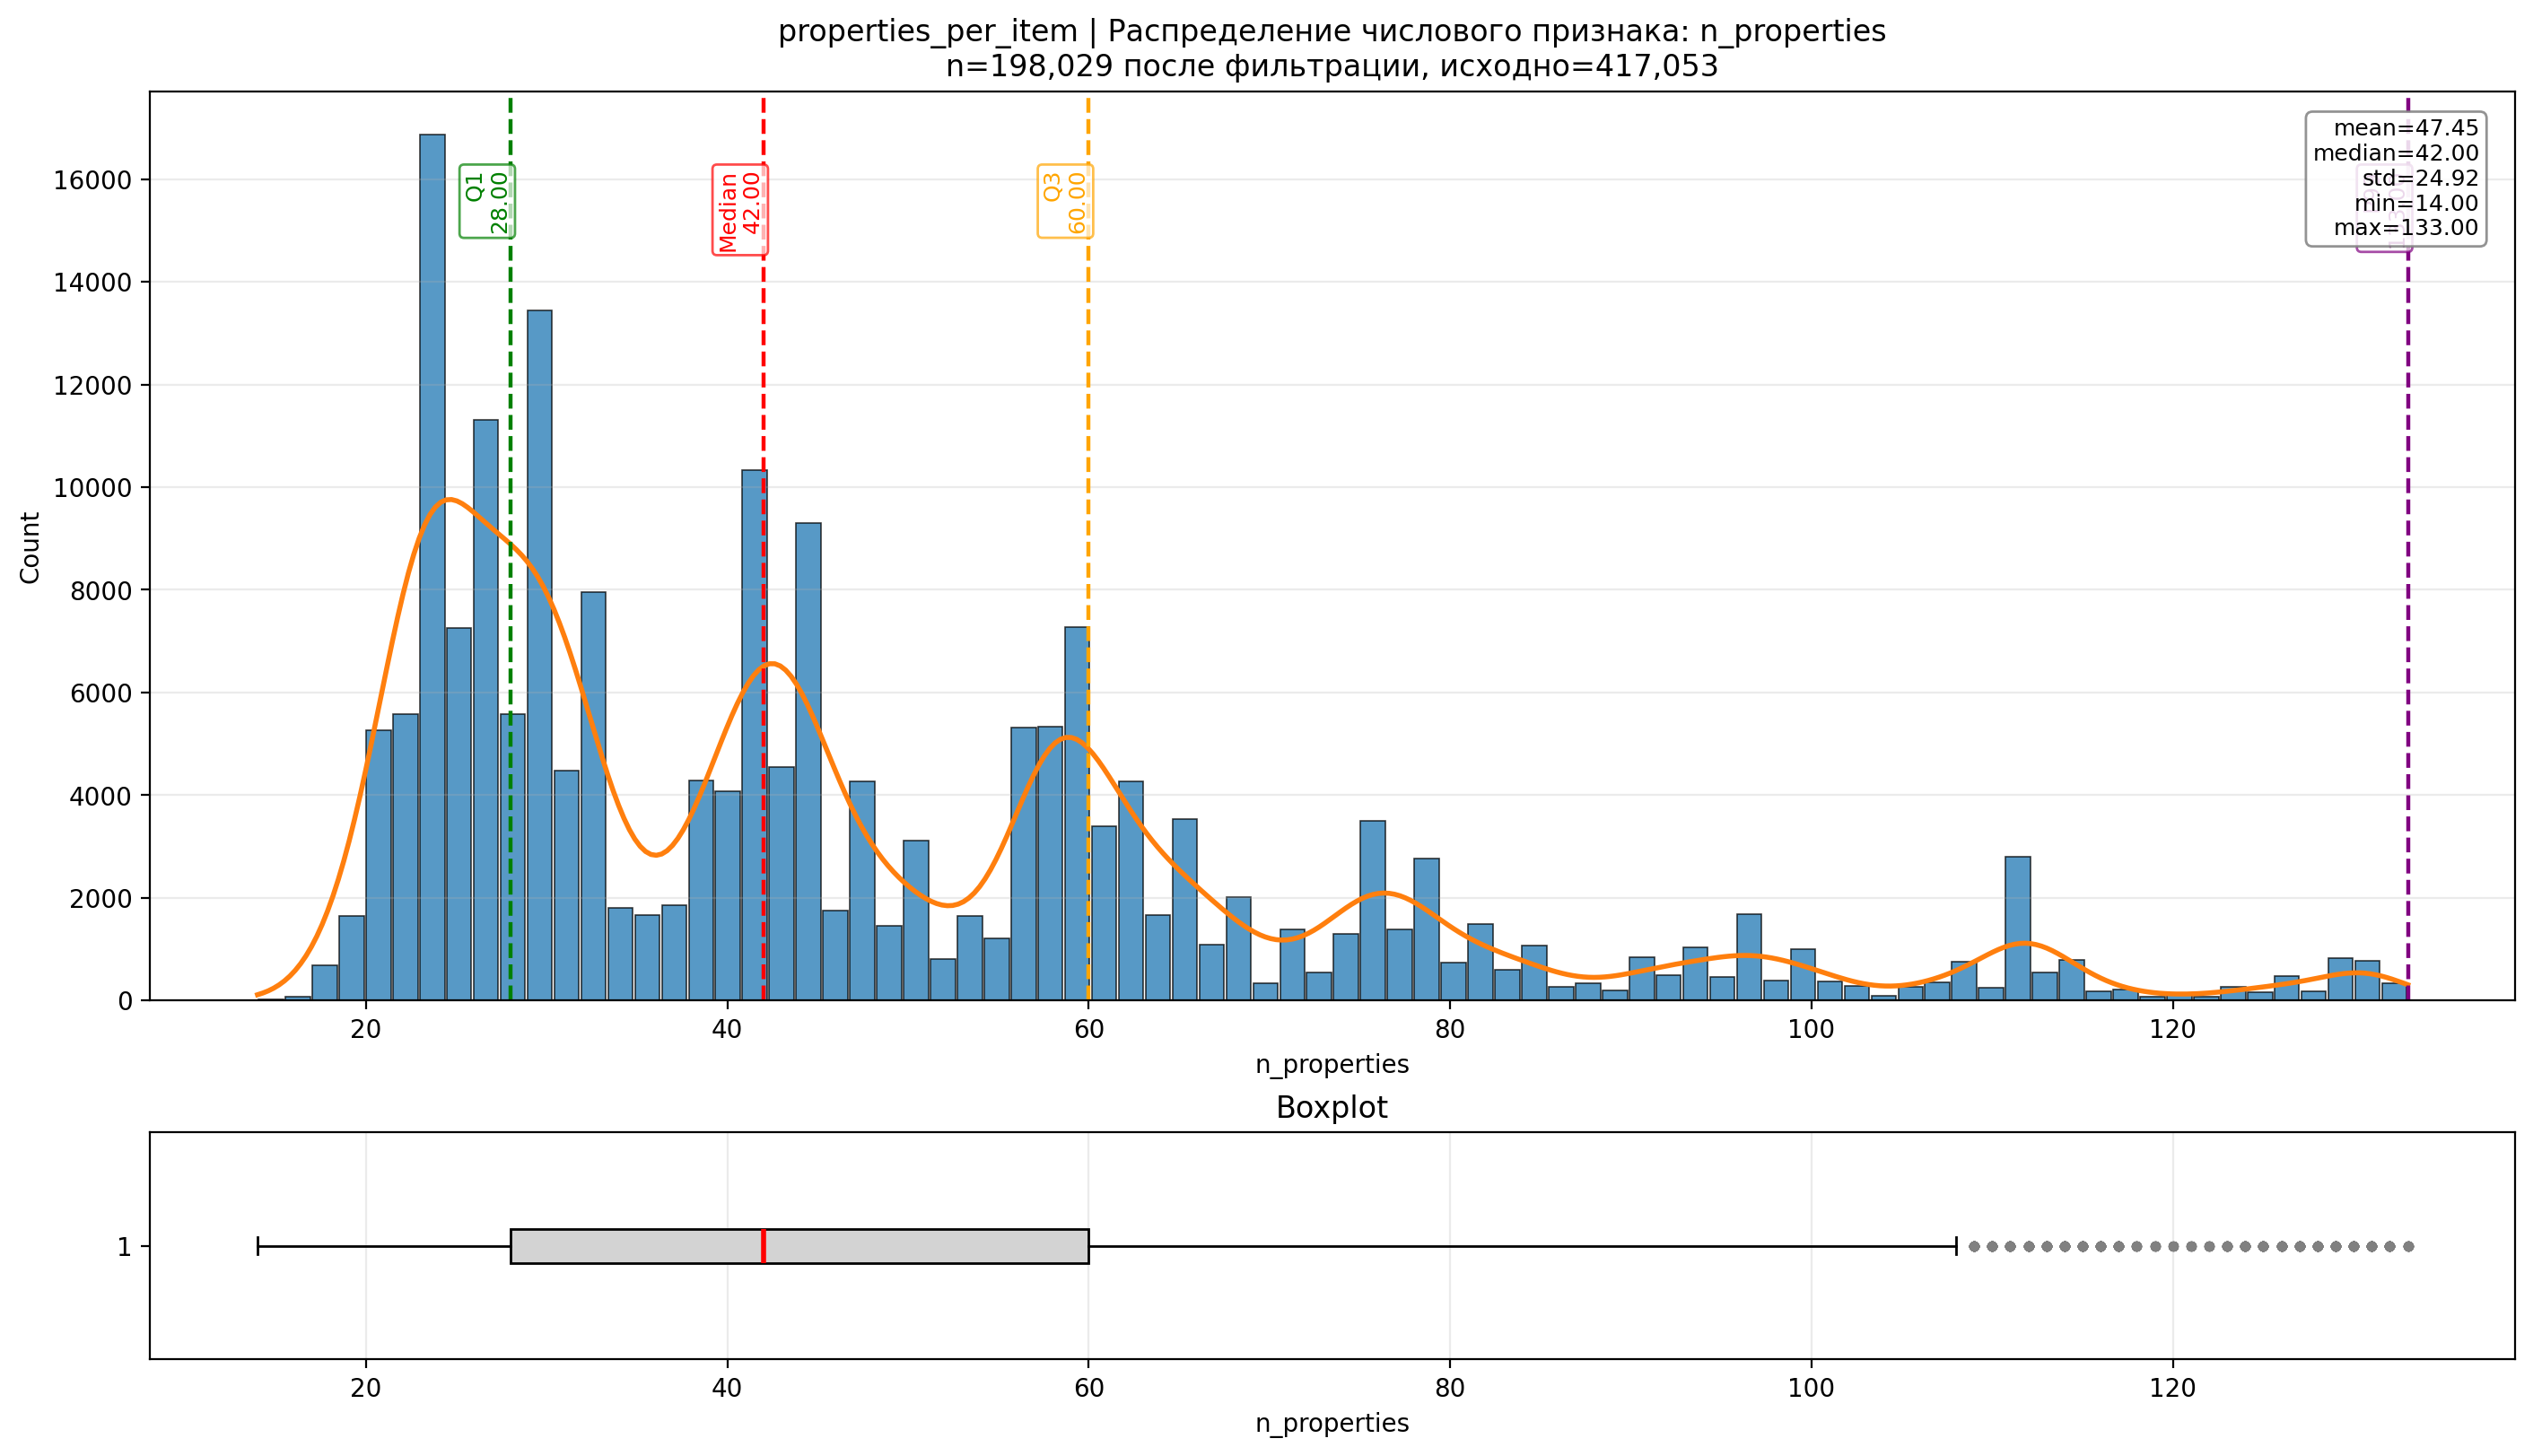

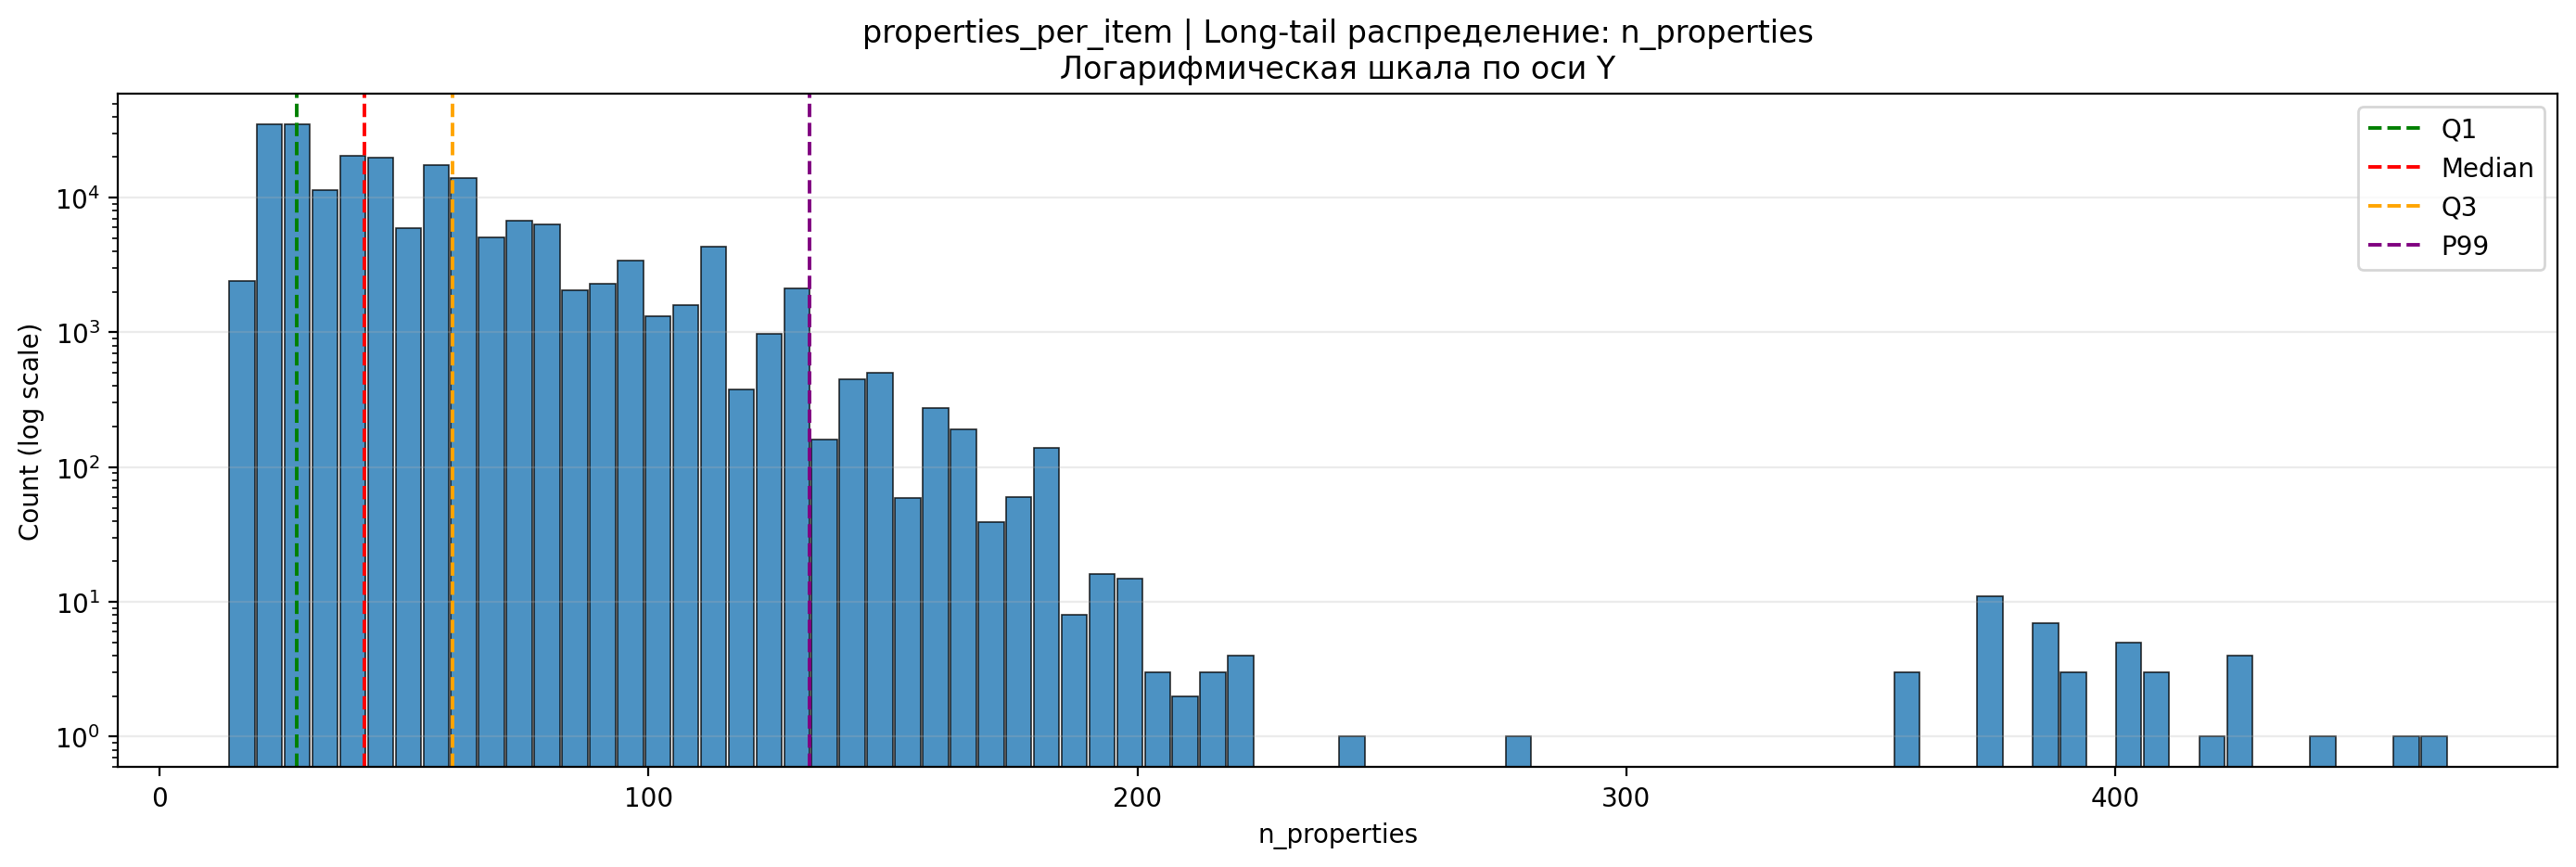

In [107]:
plot_numeric_distribution(
    props_per_item,
    "n_properties",
    dataset_name="properties_per_item",
    percentile=0.99,
    bins=80,
    show_log_hist=True,
)

### Выводы: Распределение свойств на товар

* медиана: **~42 свойства на товар**
* среднее: **~48** → есть правый хвост
* основной диапазон: **28–60 свойств (IQR)**
* минимум: ~12 → почти нет “пустых” товаров

---

### Ключевые наблюдения

* распределение:

  * **мультимодальное** → есть разные типы товаров (категории с разной детализацией)
* длинный хвост:

  * есть товары с **100+ и до ~400+ свойств**
  * но таких мало

---

### Интерпретация

* данные **богаты признаками**
* товары хорошо описаны → сильный потенциал для content-based моделей

---

### Импликации для модели

* можно строить:

  * content-based рекомендации
  * гибрид (ALS + фичи)

* важно:

  * делать **feature selection / encoding**
  * учитывать:

    * разные типы свойств (категория, бинарные, числовые)

---

### Риски

* высокая размерность:

  * 1000+ свойств → разреженность в фичах

* переобучение:

  * из-за большого числа слабых признаков

---

### Итог

* товары имеют **достаточно плотное и информативное описание**,
что делает item-based и hybrid подходы особенно перспективными.


### Анализ available

In [108]:
available_props = item_props[item_props["property"] == "available"].copy()
available_props["value"].value_counts(dropna=False).head(10)

value
0    863086
1    640553
Name: count, dtype: Int64

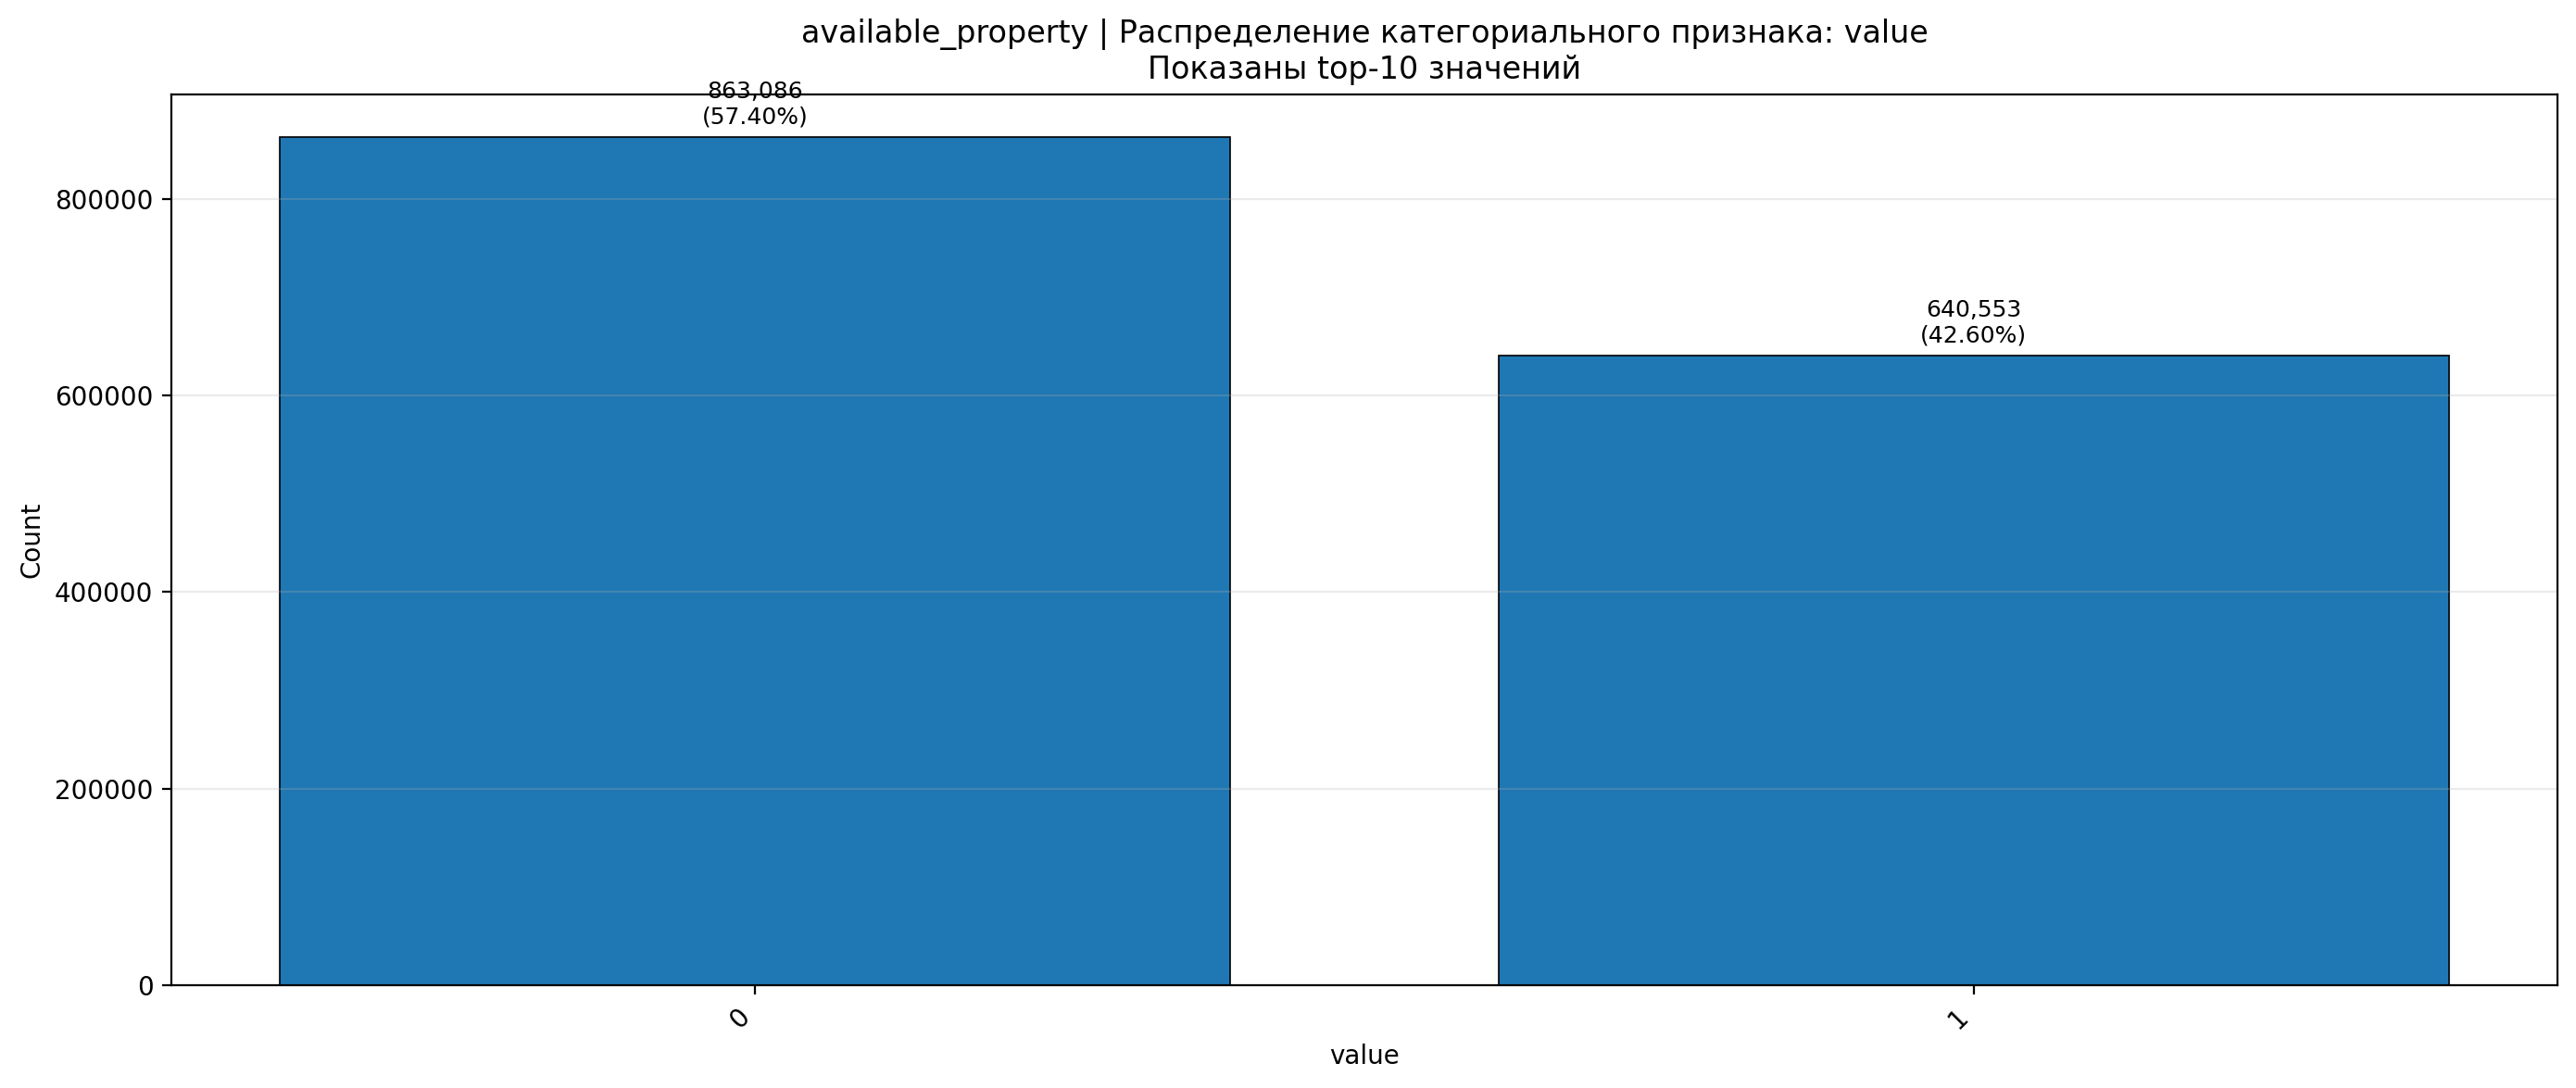

In [109]:
if not available_props.empty:
    plot_categorical_distribution(
        available_props, "value", dataset_name="available_property", top_n=10
    )

### Выводы по признаку `available`

* распределение:

  * **0 (недоступен)** — ~57%
  * **1 (доступен)** — ~43%

---

### Ключевые наблюдения

* доли сопоставимы → признак **сбалансированный**
* значительная часть товаров **недоступна** → шум в рекомендациях
* `available` — **бинарный и интерпретируемый сигнал**

---

### Импликации для модели

* **must-have фильтр:**

  ```python
  if available == 0:
      exclude from candidates
  ```

* как feature:

  * сильный фактор для ранжирования
  * напрямую влияет на конверсию

---

### Риски

* если не фильтровать:

  * рекомендации будут включать недоступные товары
  * ухудшение UX и метрик

---

### Итог

* `available` — **критически важный признак**,
который должен использоваться **и как фильтр, и как feature** в модели.


### Анализ categoryid в item_props

In [110]:
item_categories = item_props[item_props["property"] == "categoryid"].copy()
item_categories["value"] = pd.to_numeric(item_categories["value"], errors="coerce")
item_categories = item_categories.dropna(subset=["value"])
item_categories["value"] = item_categories["value"].astype(int)

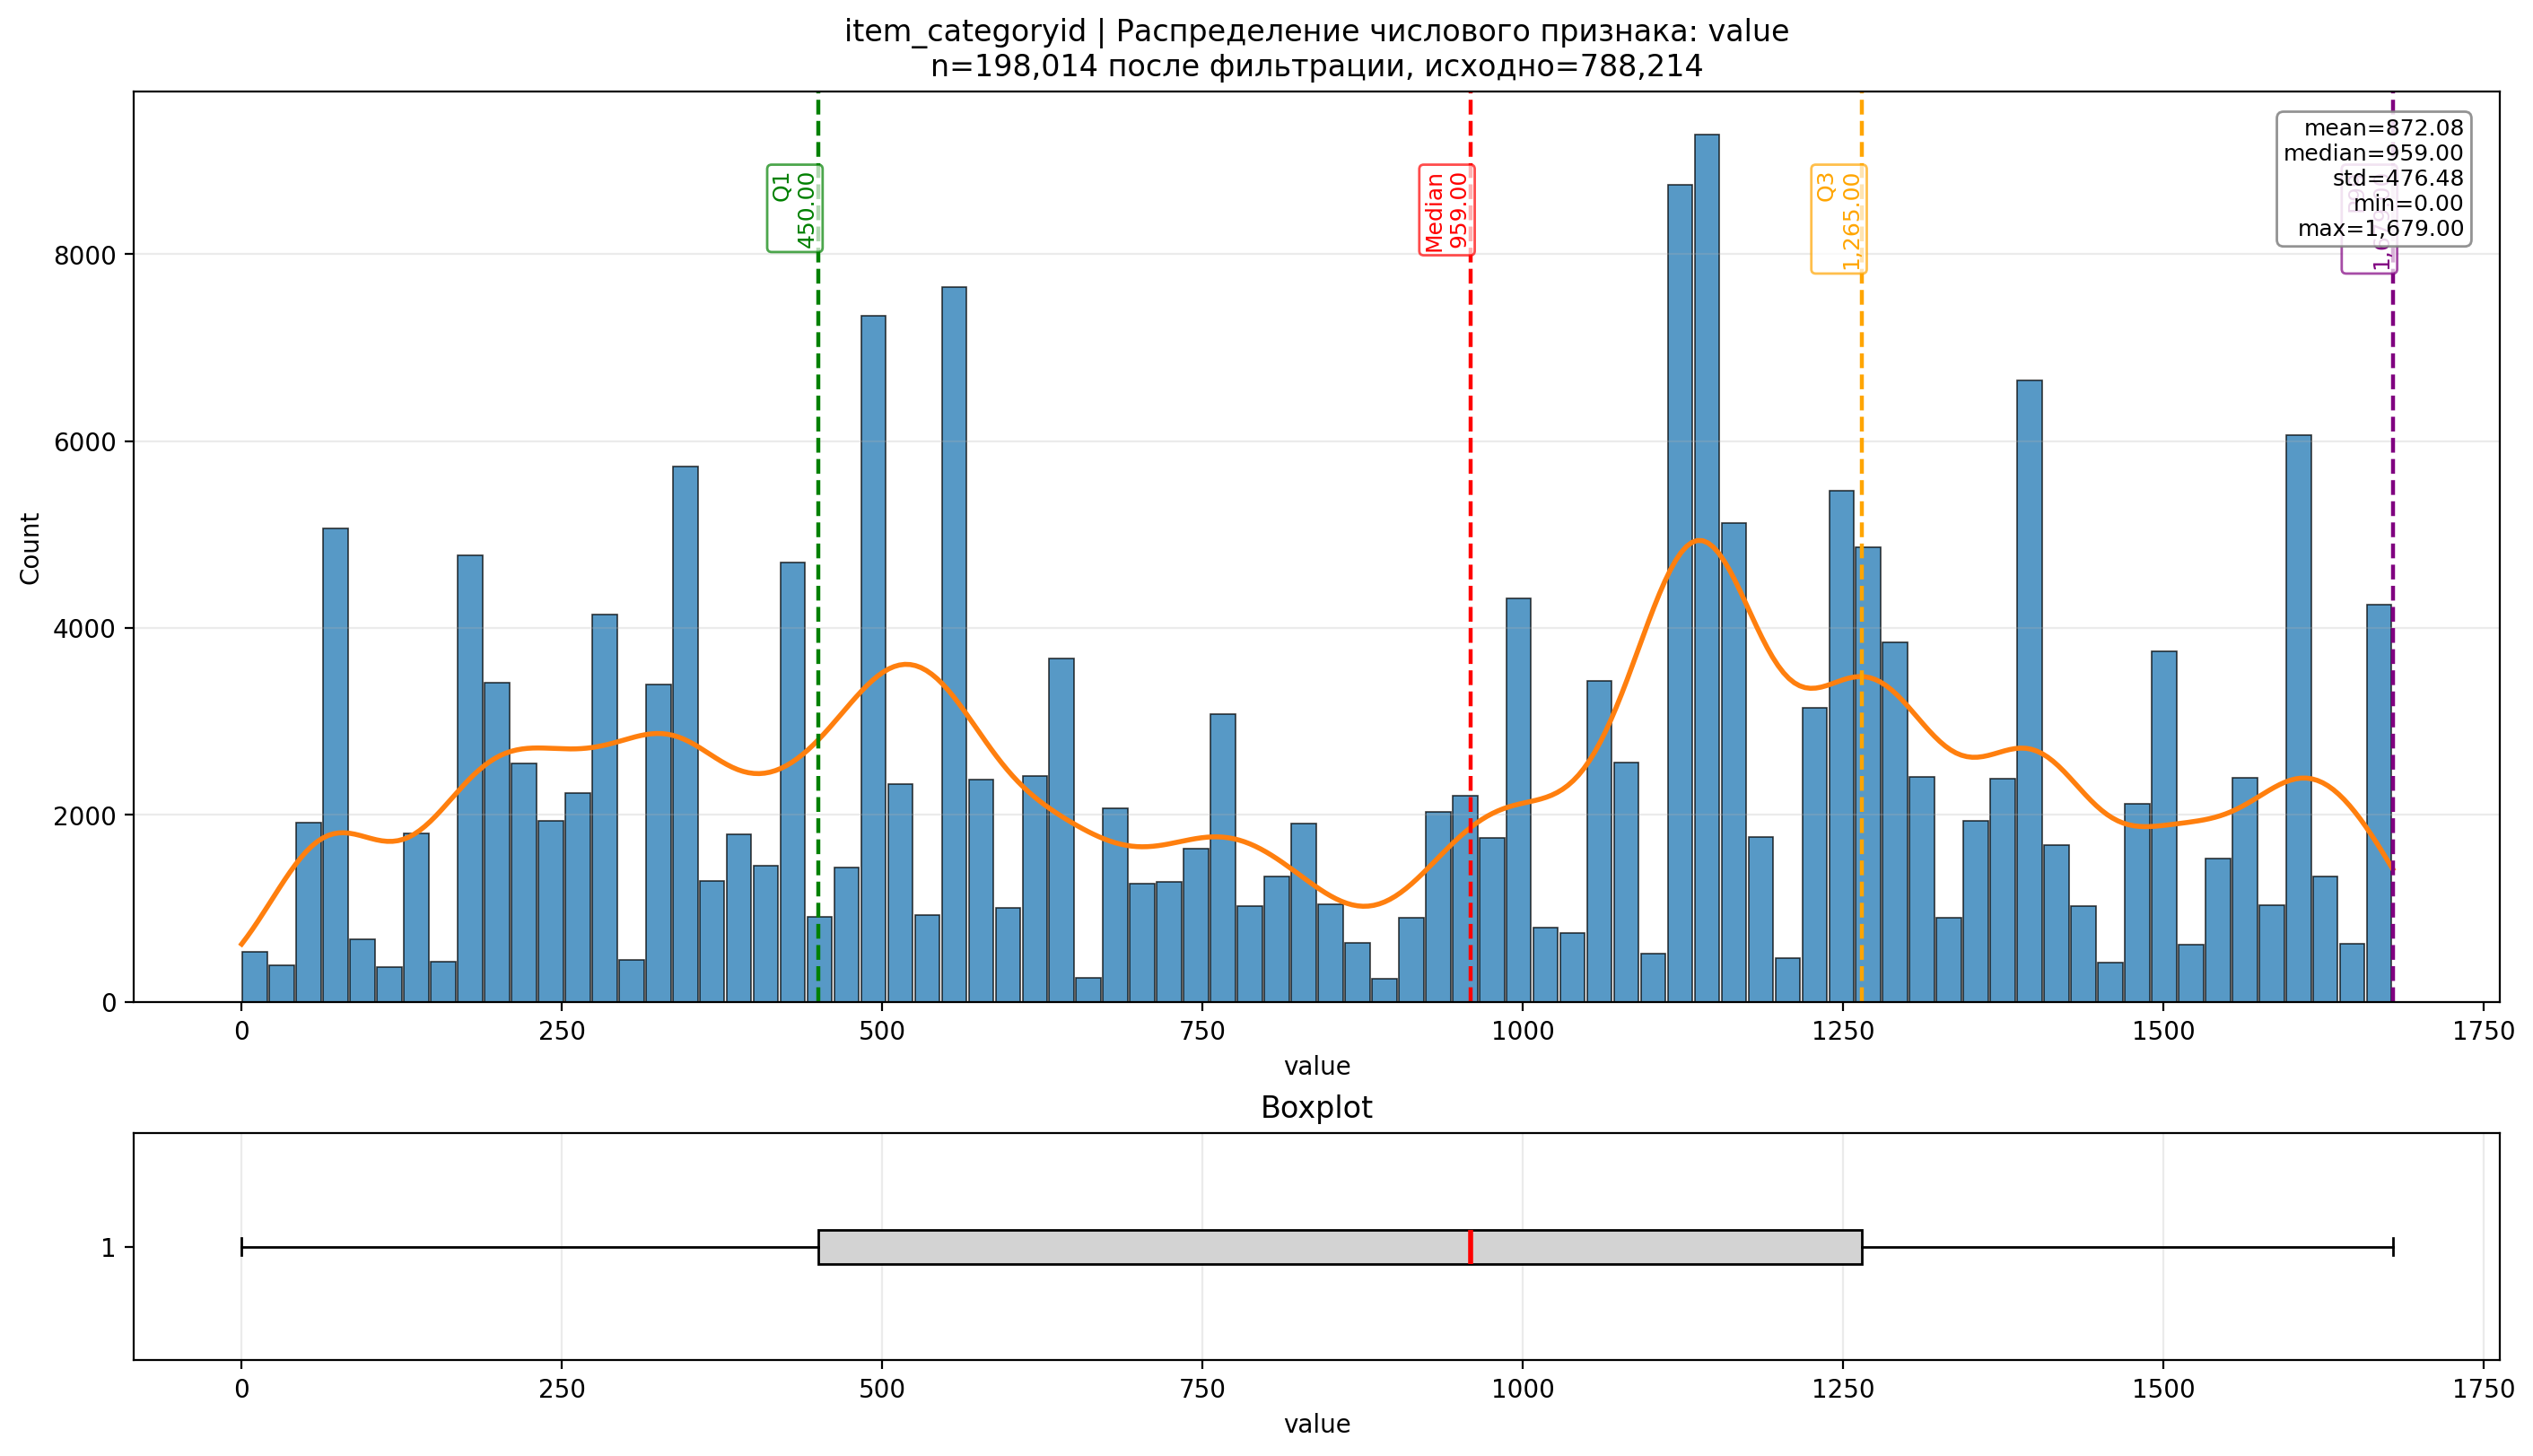

In [111]:
plot_numeric_distribution(
    item_categories,
    "value",
    dataset_name="item_categoryid",
    percentile=0.99,
    bins=80,
    show_log_hist=False,
)

### Выводы по `item_categoryid` (value)

* диапазон значений: **0 – ~1700**
* медиана: **~959**
* IQR: **~450 – 1265** → широкий разброс
* распределение:

  * **мультимодальное**
  * без сильного перекоса в одну категорию

---

### Ключевые наблюдения

* категории распределены **достаточно равномерно**
* нет явного доминирования одной категории
* присутствуют **кластеры категорий** (пики на KDE)

---

### Интерпретация

* категориальная структура:

  * **разнообразная и сбалансированная**
  * нет сильного bias в сторону отдельных категорий

---

### Импликации для модели

* `categoryid`:

  * важный **контекстный признак**
  * полезен для:

    * candidate generation (item-based)
    * feature в ранжировании

* можно использовать:

  ```python
  user_category_pref
  item_category_popularity
  category_conversion_rate
  ```

---

### Риски

* числовой ID:

  * нельзя использовать как ordinal
  * нужен:

    * one-hot / target encoding / embeddings

---

### Итог

* категории покрывают пространство **равномерно и полно**,
что делает их сильным сигналом для персонализации и сегментации.


# 8. Общие выводы по EDA

## 8.1. Данные и масштаб

* **1.4M пользователей**, **235K товаров**, **2.7M событий**
* высокая разреженность:
    * density ≈ **8e-06**

* мало взаимодействий на пользователя:
    * медиана = **1 событие**

* вывод:
  * данные типичны для рекомендательных систем — **sparse + implicit feedback**

---

## 8.2. Поведение пользователей

* **71% пользователей** имеют только 1 событие
* сильный long-tail:

  * few power users
  * большинство — cold users

* вывод - нужны:
  * popularity
  * content-based
  * гибридные модели

---

## 8.3. Популярность товаров

* распределение:

  * long-tail
  * few популярных товаров
  * много редких

* вывод:
    * popularity bias присутствует

* важно:
  * учитывать long-tail
  * не переобучаться на топ-товары

---

## 8.4. Funnel

* view: **96.7%**
* addtocart: **2.5%**
* transaction: **0.8%**

* вывод:
    * сильная потеря на этапе:
        * view → cart
    * addtocart — **ключевой сигнал покупки**

---

## 8.5. Временные паттерны

* вечер (17–21) → максимум конверсий
* утро → минимум
* выходные → ниже конверсия

* вывод:
  * поведение зависит от времени
  * нужны **time-aware фичи**

---

## 8.6. Конверсии

* cart → buy до **~40–45%**
* view → buy сильно ниже

* вывод:
  * addtocart = **самый сильный предиктор покупки**

---

## 8.7. User-Item матрица

* экстремально разреженная
* большинство user-item пар отсутствует

* вывод - нужны:
  * negative sampling
  * implicit модели (ALS / LGBM)

---

## 8.8. Cold-start

* users:
  * 71% с 1 событием
* items:
  * ~31% с 1 событием

* вывод:
  * cold-start — **критическая проблема**
  * нужны:
    * item features
    * popularity fallback

---

## 8.9. Category tree

* 1669 категорий
* 25 корневых (~1.5%)

* вывод:

  * нормальная иерархия
  * категории — важный сигнал

---

## 8.10. Item properties

* ~48 свойств на товар (медиана ~42)
* много признаков → высокая информативность

* вывод - сильный потенциал для:
    * content-based
    * hybrid моделей

---

## 8.11. Available

* 57% товаров недоступны

* вывод:

  * обязательный фильтр в рекомендациях

---

## 8.12. Итоговая картина

* sparse данные
* сильный long-tail
* мощные item features
* явные поведенческие паттерны

---

# 8.13. Главный итог

* оптимальный подход:

```text
Hybrid recommender:
ALS / retrieval + LightGBM ranking
```

с фичами:

  * user behavior
  * item popularity
  * time
  * addtocart signal
  * item properties


# 9. Выбор Метрик

Задача формулируется как **ранжирование товаров** с целью максимизации вероятности покупки, поэтому стандартные классификационные метрики (accuracy, F1-score) не подходят, так как не учитывают порядок рекомендаций.

С учётом свойств данных, выявленных на этапе EDA:

* высокая разреженность
* сильный дисбаланс классов
* implicit feedback

в качестве offline-метрик выбраны:

---

## Основные метрики

### NDCG@K (основная)

* учитывает **позицию релевантных объектов**
* более высокий вес у топа выдачи
  * наиболее близка к реальному UX

---

###  MAP@K

* учитывает **все релевантные объекты**
* оценивает **качество ранжирования на всём списке**
  * более строгая метрика, чем HitRate

---

###  Recall@K

* показывает, сколько релевантных товаров попало в рекомендации
  * важна для покрытия

---

## Дополнительная метрика

### HitRate@K

* показывает наличие хотя бы одного релевантного объекта
  * используется как sanity check

---

##  Бизнес-метрики

Финальная цель оптимизации:

* **Conversion Rate**
* **Revenue**
* **CTR**